In [411]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                              recall_score, f1_score, classification_report,
                              ConfusionMatrixDisplay)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/competitions/edu-guard-ai-smart-city-ai-challenge-2026/sample_submission.csv
/kaggle/input/competitions/edu-guard-ai-smart-city-ai-challenge-2026/train.csv
/kaggle/input/competitions/edu-guard-ai-smart-city-ai-challenge-2026/test.csv


# **Data Preprocessing**

In [412]:
df=pd.read_csv("/kaggle/input/competitions/edu-guard-ai-smart-city-ai-challenge-2026/train.csv")
df.head()

,Student_ID,Application_ID,Registration_Code,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,ST202603036,APP1000803,REG-ABSM2,Single,Change of course,1,Social Service,Daytime,Technological specialization course,120.0,...,6,10,13,10,11.800000,0,13.9,-0.3,0.79,Graduate
1,ST202602902,APP1002222,REG-ZEDE1,Single,Over 23 years old,1,Equinculture,Daytime,NaN,133.1,...,0,5,5,0,0.000000,5,12.7,3.7,-1.70,Dropout
2,ST202602203,APP1000088,REG-GN22Y,Single,Technological specialization diploma holders,1,Agronomy,Daytime,Technological specialization course,140.0,...,0,6,15,4,10.500000,0,15.5,2.8,-4.06,Enrolled
3,ST202604064,APP1001900,REG-R3Z1D,Single,1st phase - special contingent (Madeira Island),1,Communication Design,Daytime,Secondary education,125.0,...,0,6,6,6,12.833333,0,12.4,0.5,1.79,Graduate
4,ST202602100,APP1000866,REG-WEY9J,Single,2nd phase - general contingent,1,Nursing,Daytime,Secondary education,142.0,...,0,8,8,7,14.731429,0,10.8,1.4,1.74,Graduate


In [413]:
df2=pd.read_csv("/kaggle/input/competitions/edu-guard-ai-smart-city-ai-challenge-2026/test.csv")
df2.head()

,Student_ID,Application_ID,Registration_Code,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,ST202603891,APP1002314,REG-IPA5C,Single,Technological specialization diploma holders,1,Agronomy,Daytime,Technological specialization course,160.0,...,0,0,6,7,6,14.666667,0,12.4,0.5,1.79
1,ST202602193,APP1000248,REG-Q80NK,Single,2nd phase - general contingent,1,Nursing,Daytime,NaN,131.0,...,0,0,8,10,8,11.712500,0,16.2,0.3,-0.92
2,ST202602924,APP1001607,REG-GBTRV,Single,1st phase - general contingent,2,Communication Design,Daytime,Secondary education,121.0,...,0,0,6,9,0,0.000000,0,9.4,-0.8,-3.12
3,ST202603363,APP1000269,REG-U7V7J,Single,1st phase - general contingent,2,Management,Daytime,Secondary education,118.0,...,0,0,5,5,5,13.600000,0,12.4,0.5,1.79
4,ST202601887,APP1003391,REG-WEWFW,Single,1st phase - general contingent,1,Communication Design,Daytime,Secondary education,133.1,...,0,0,6,6,6,12.666667,0,16.2,0.3,-0.92


In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3690 entries, 0 to 3689
Data columns (total 40 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      3690 non-null   object 
 1   Application_ID                                  3690 non-null   object 
 2   Registration_Code                               3690 non-null   object 
 3   Marital status                                  3690 non-null   object 
 4   Application mode                                3690 non-null   object 
 5   Application order                               3690 non-null   int64  
 6   Course                                          3690 non-null   object 
 7   Daytime/evening attendance                      3690 non-null   object 
 8   Previous qualification                          3607 non-null   object 
 9   Previous qualification (grade)           

In [415]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      885 non-null    object 
 1   Application_ID                                  885 non-null    object 
 2   Registration_Code                               885 non-null    object 
 3   Marital status                                  885 non-null    object 
 4   Application mode                                885 non-null    object 
 5   Application order                               885 non-null    int64  
 6   Course                                          885 non-null    object 
 7   Daytime/evening attendance                      885 non-null    object 
 8   Previous qualification                          871 non-null    object 
 9   Previous qualification (grade)             

In [416]:
df.describe()

,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3690.000000,3690.000000,3650.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000,3690.000000
mean,1.724661,135.844743,130.159014,23.567209,0.737669,6.288618,8.323848,4.723577,10.650297,0.137940,0.564228,6.249322,8.072087,4.455556,10.241998,0.135230,11.583577,1.214255,0.018103
std,1.304148,55.617082,55.289055,8.646672,2.430719,2.517148,4.185260,3.105974,4.843423,0.653366,1.978283,2.235439,3.982301,3.038169,5.204467,0.699208,2.662404,1.378013,2.279729
min,0.000000,-10.000000,-15.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,124.000000,117.700000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.800000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,125.850000,20.000000,0.000000,6.000000,8.000000,5.000000,12.310000,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,135.000000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,9.000000,999.000000,999.000000,90.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [417]:
df2.describe()

,Application order,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,885.000000,885.000000,877.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000,885.000000
mean,1.731073,133.987571,130.466021,23.569492,0.681356,6.291525,8.329944,4.726554,10.712165,0.128814,0.527684,6.253107,8.164972,4.444068,10.332942,0.194350,11.510169,1.250847,-0.064667
std,1.340289,44.607059,55.276569,8.340259,2.283658,2.423673,4.147132,3.090971,4.733893,0.792581,1.899206,2.099694,3.866540,2.962526,5.112063,0.899077,2.678583,1.394962,2.262703
min,1.000000,-10.000000,-15.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,124.000000,118.200000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.900000,20.000000,0.000000,6.000000,8.000000,5.000000,12.250000,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,134.600000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.375000,0.000000,13.900000,2.600000,1.790000
max,6.000000,999.000000,999.000000,90.000000,17.000000,19.000000,45.000000,19.000000,18.000000,12.000000,15.000000,17.000000,26.000000,17.000000,17.714286,8.000000,16.200000,3.700000,3.510000


In [418]:
df.duplicated().sum()

np.int64(118)

In [419]:
df.drop_duplicates(inplace = True)

In [420]:
df2.duplicated().sum()

np.int64(0)

In [421]:
df.isnull().sum()

Student_ID                                          0
Application_ID                                      0
Registration_Code                                   0
Marital status                                      0
Application mode                                    0
Application order                                   0
Course                                              0
Daytime/evening attendance                          0
Previous qualification                             79
Previous qualification (grade)                      0
Nacionality                                         0
Mother's qualification                             44
Father's qualification                             83
Mother's occupation                                78
Father's occupation                               113
Admission grade                                    40
Displaced                                           0
Educational special needs                           0
Debtor                      

In [422]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

Student_ID                                        0
Application_ID                                    0
Registration_Code                                 0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees

In [423]:
df2.isnull().sum()

Student_ID                                         0
Application_ID                                     0
Registration_Code                                  0
Marital status                                     0
Application mode                                   0
Application order                                  0
Course                                             0
Daytime/evening attendance                         0
Previous qualification                            14
Previous qualification (grade)                     0
Nacionality                                        0
Mother's qualification                            13
Father's qualification                            25
Mother's occupation                               15
Father's occupation                               26
Admission grade                                    8
Displaced                                          0
Educational special needs                          0
Debtor                                        

In [424]:
num_cols = df2.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df2[col] = df2[col].fillna(df2[col].mean())

cat_cols = df2.select_dtypes(include='object').columns
for col in cat_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

df2.isnull().sum()

Student_ID                                        0
Application_ID                                    0
Registration_Code                                 0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees

In [425]:
df.shape

(3572, 40)

In [426]:
df2.shape

(885, 39)

In [427]:
df.columns

Index(['Student_ID', 'Application_ID', 'Registration_Code', 'Marital status',
       'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricul

In [428]:
df2.columns

Index(['Student_ID', 'Application_ID', 'Registration_Code', 'Marital status',
       'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricul

In [429]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("NUMERICAL COLUMNS:")
for col in num_cols:
    print(col)

cat_cols = df.select_dtypes(include=['object']).columns
print("CATEGORICAL COLUMNS:")
for col in cat_cols:
    print(col)

NUMERICAL COLUMNS:
Application order
Previous qualification (grade)
Admission grade
Age at enrollment
Curricular units 1st sem (credited)
Curricular units 1st sem (enrolled)
Curricular units 1st sem (evaluations)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (credited)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (evaluations)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP
CATEGORICAL COLUMNS:
Student_ID
Application_ID
Registration_Code
Marital status
Application mode
Course
Daytime/evening attendance
Previous qualification
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
International
Target


In [430]:
df['Course'].value_counts()

Course
Nursing                                 612
Management                              303
Social Service                          294
Veterinary Nursing                      278
Journalism and Communication            270
Advertising and Marketing Management    219
Management (evening attendance)         218
Tourism                                 199
Animation and Multimedia Design         178
Communication Design                    177
Agronomy                                172
Social Service (evening attendance)     168
Basic Education                         158
Informatics Engineering                 133
Equinculture                            115
Oral Hygiene                             68
Biofuel Production Technologies          10
Name: count, dtype: int64

# *EDA*

In [431]:
inc_cols=['Gender', 'International', 'Scholarship holder', 'Educational special needs']
for column in inc_cols:
    df[column] = df[column].str.strip() 
    df[column] = df[column].str.lower()
    print(df[column].value_counts())

Gender
female    2236
male      1200
f           84
m           52
Name: count, dtype: int64
International
no     3341
n       145
yes      83
y         3
Name: count, dtype: int64
Scholarship holder
no       2551
yes       842
false      67
n          64
y          25
true       23
Name: count, dtype: int64
Educational special needs
no     3368
n       163
yes      39
y         2
Name: count, dtype: int64


In [432]:
for column in inc_cols:
    df[column] = df[column].replace({"y": "yes"})
    df[column] = df[column].replace({"n": "no"})
    df[column] = df[column].replace({"true": "yes"})
    df[column] = df[column].replace({"false": "no"})
    df[column] = df[column].replace({"f": "female"})
    df[column] = df[column].replace({"m": "male"})
    print(df[column].value_counts())



Gender
female    2320
male      1252
Name: count, dtype: int64
International
no     3486
yes      86
Name: count, dtype: int64
Scholarship holder
no     2682
yes     890
Name: count, dtype: int64
Educational special needs
no     3531
yes      41
Name: count, dtype: int64


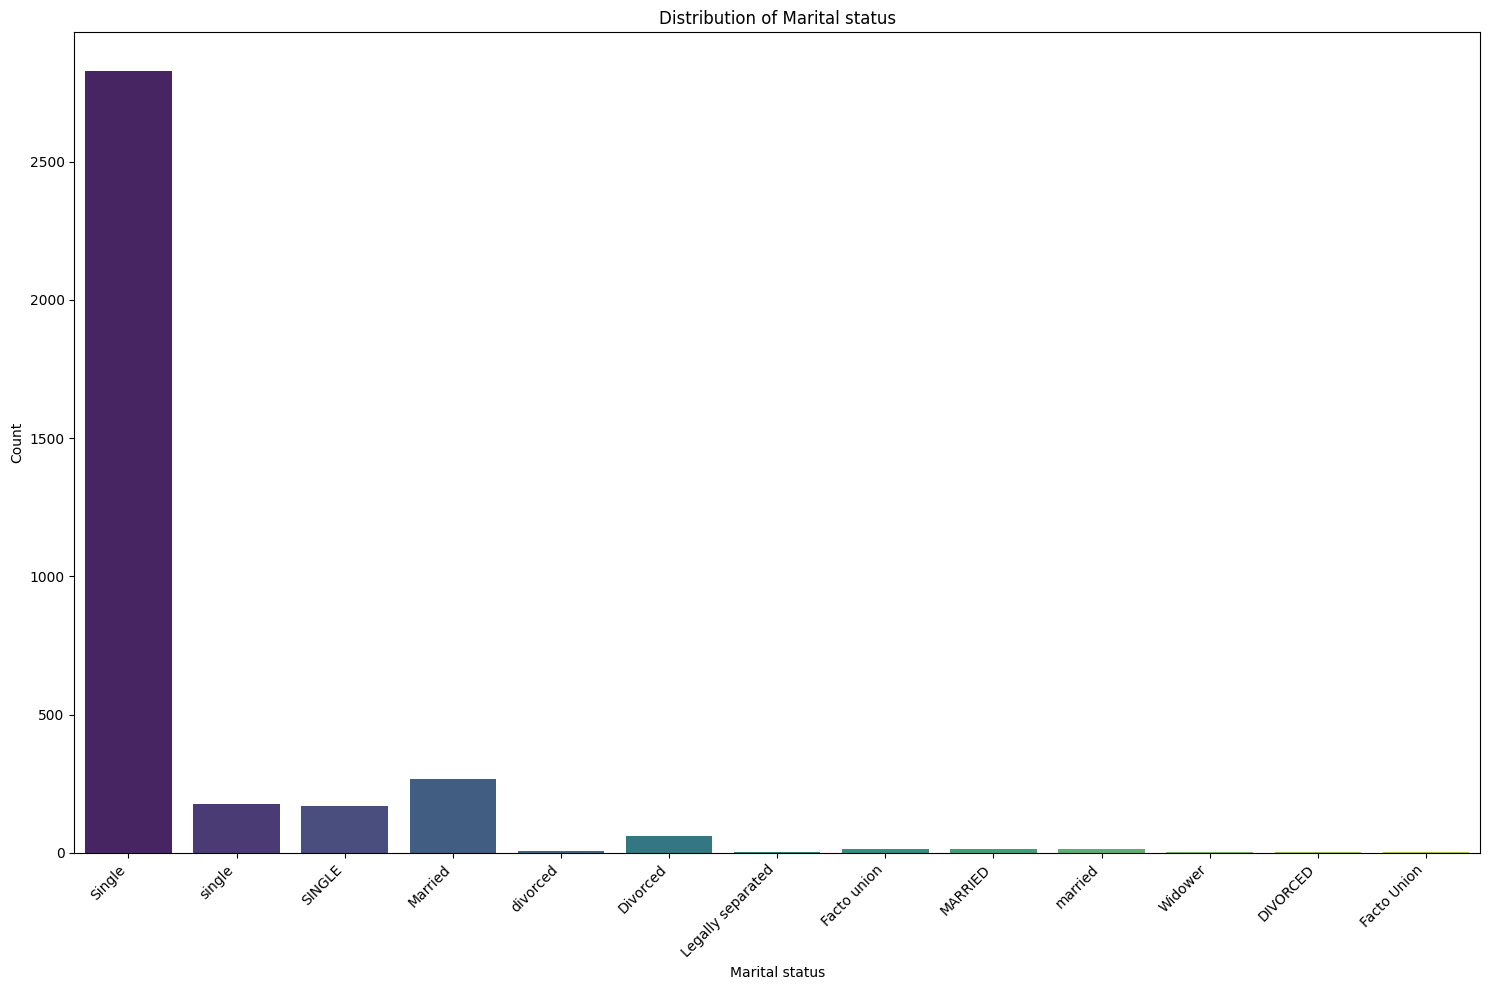

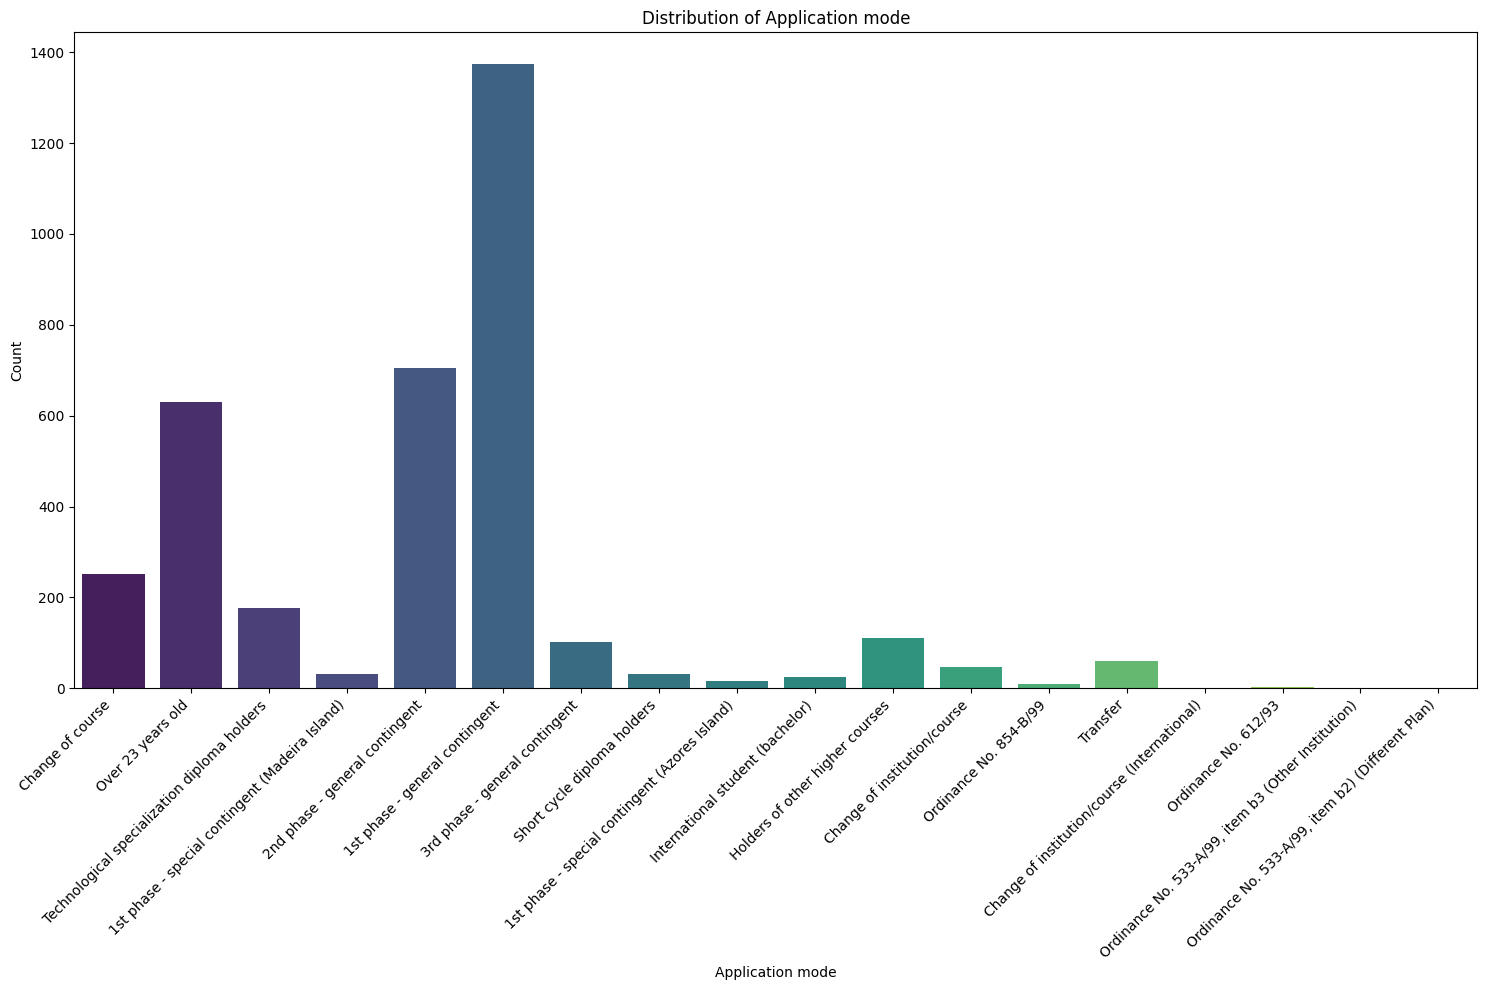

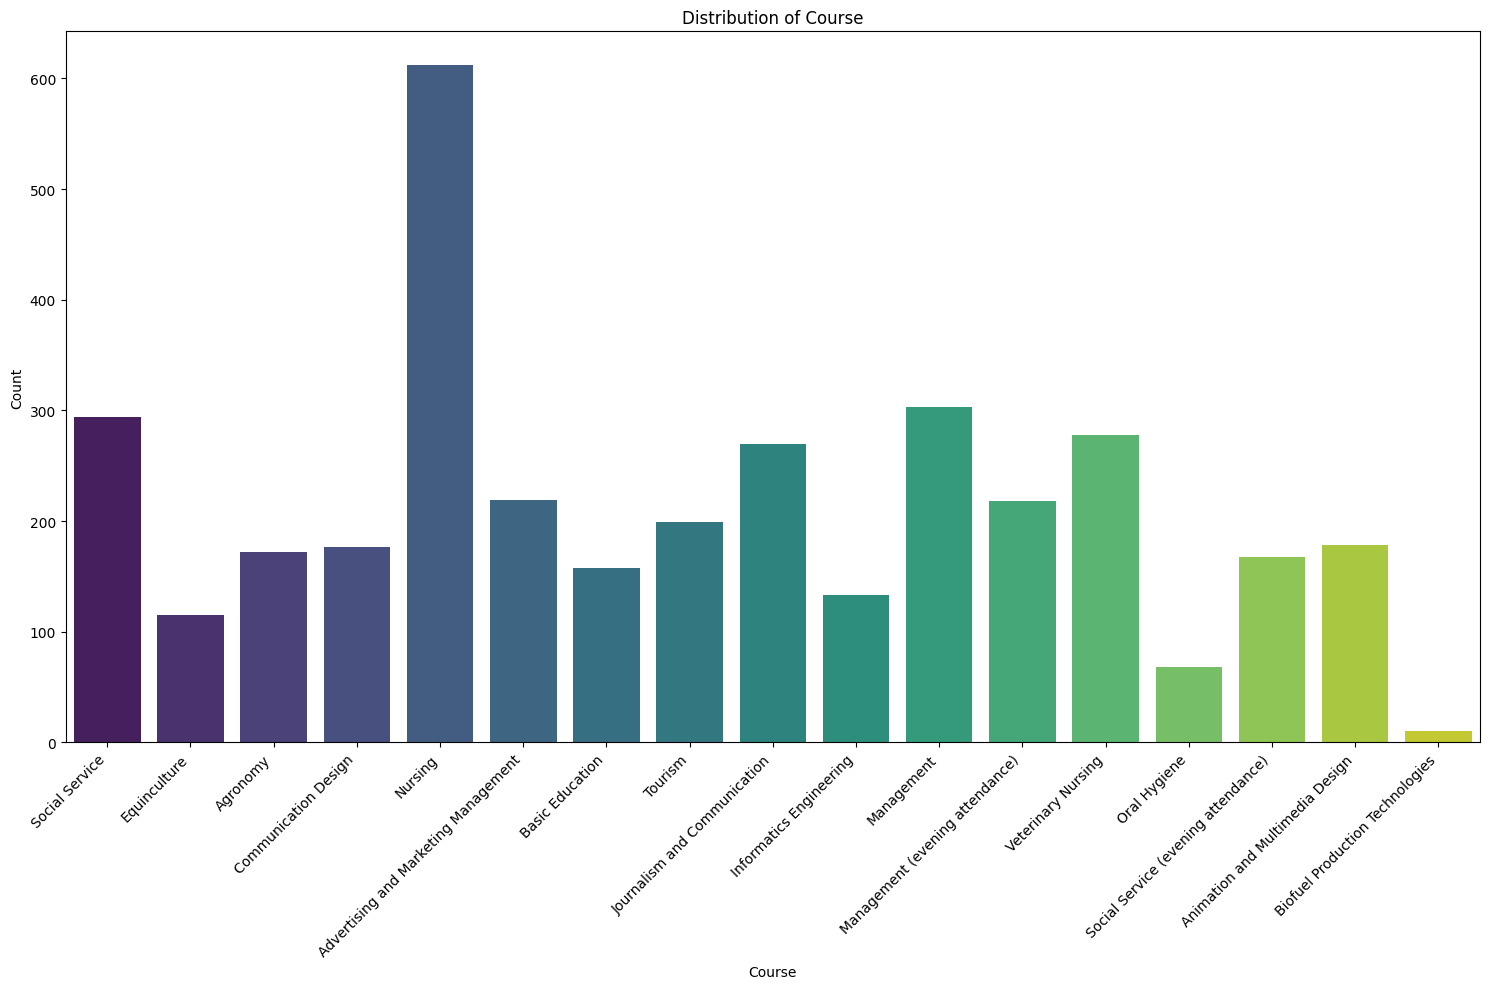

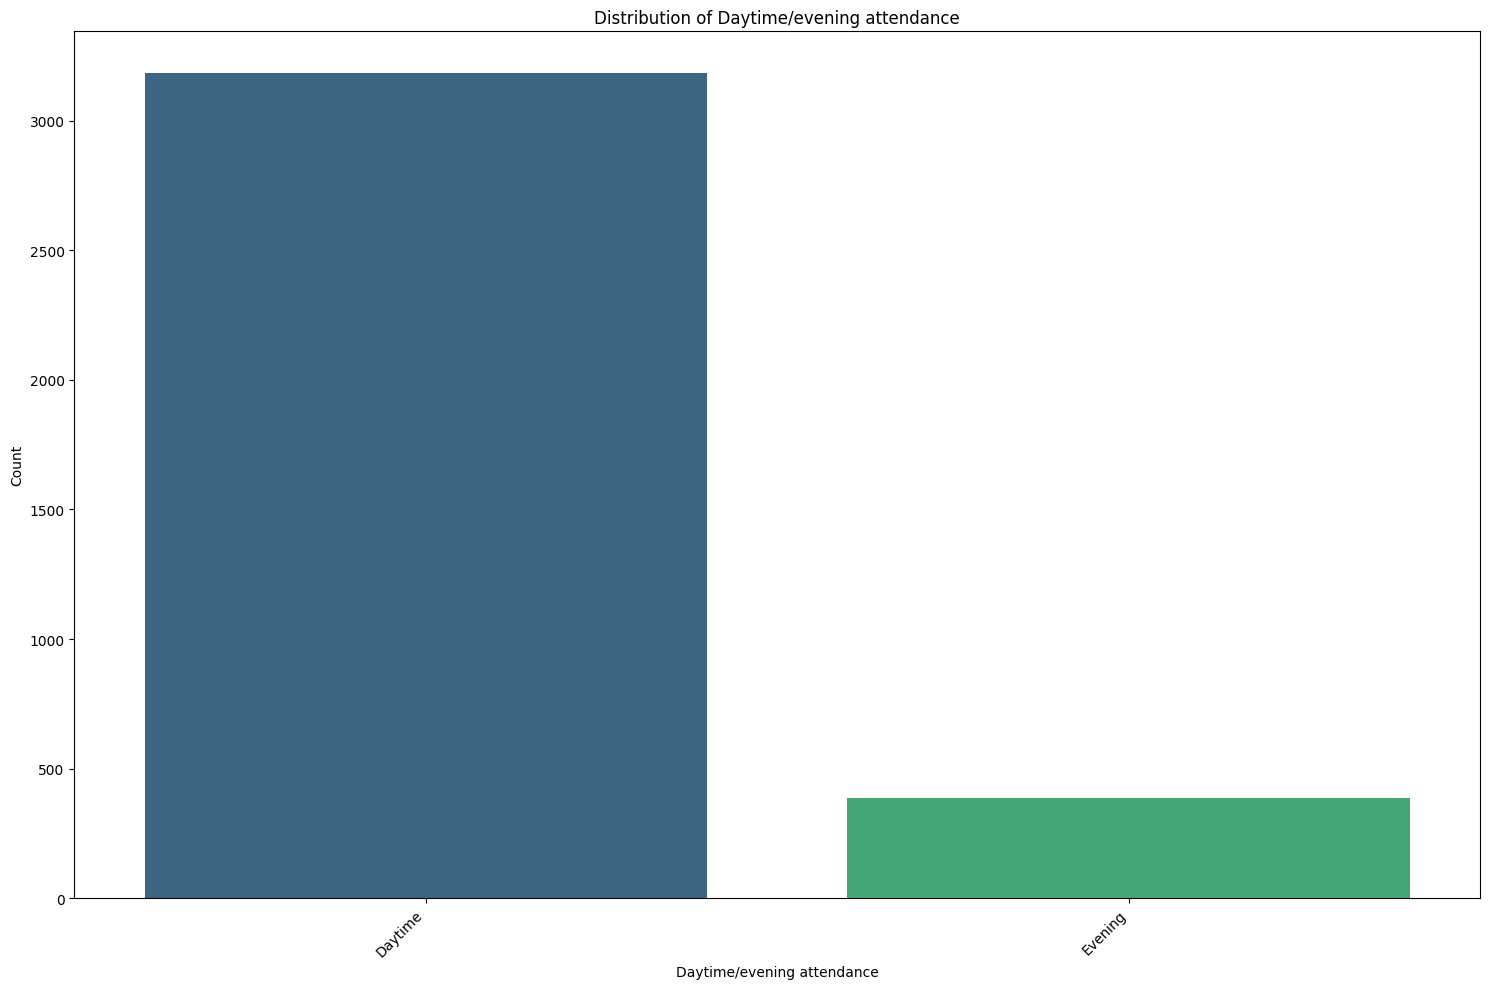

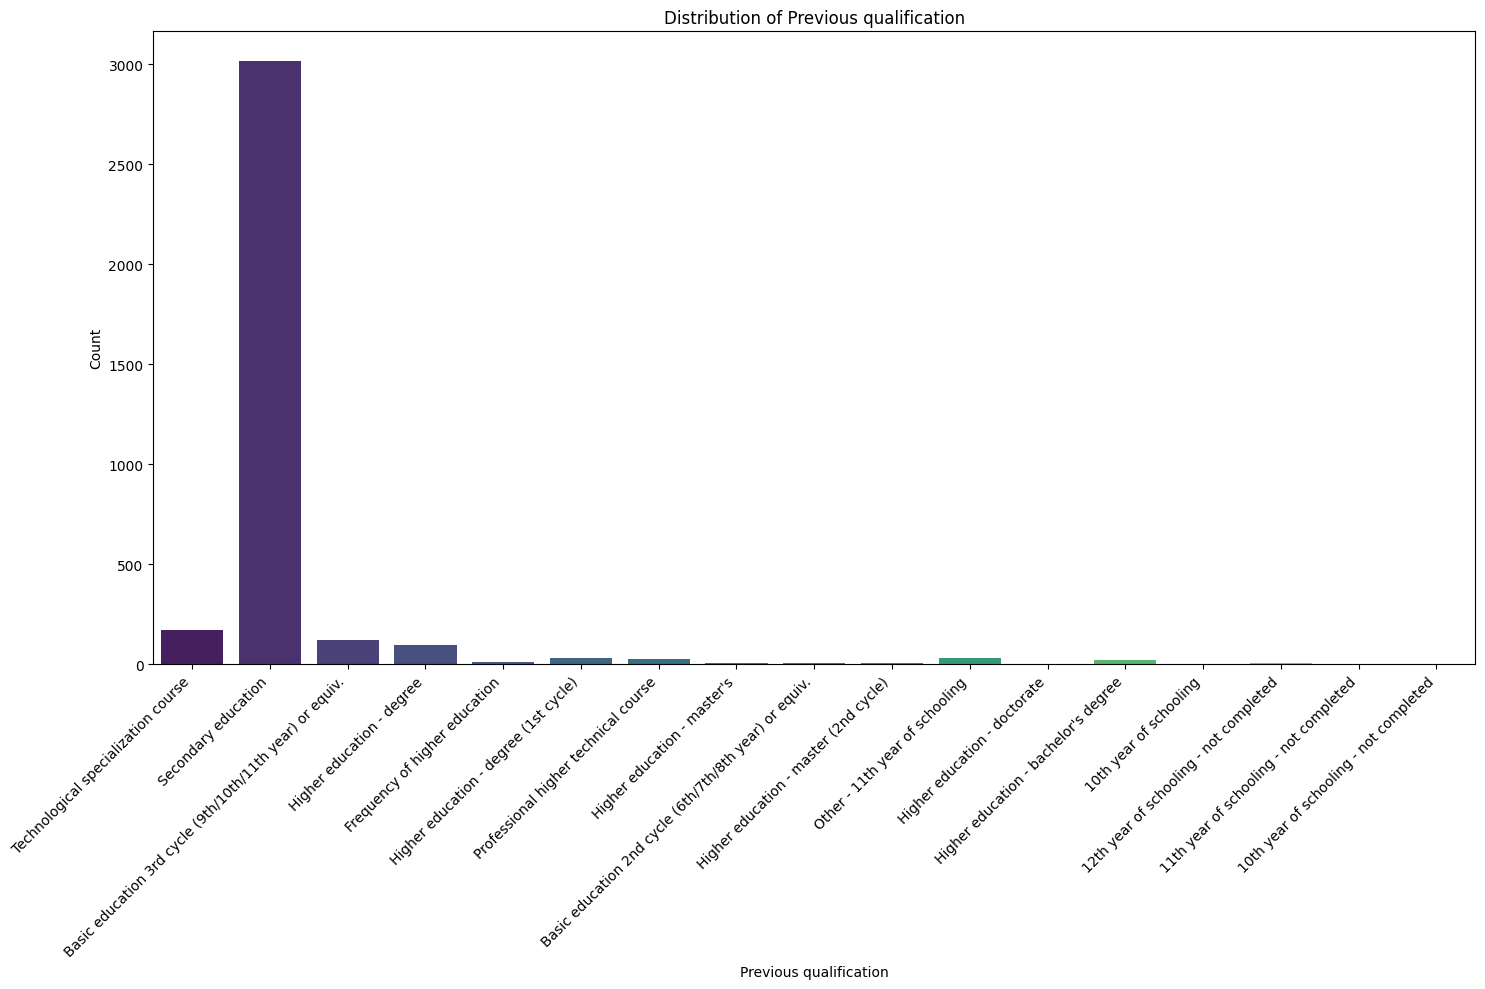

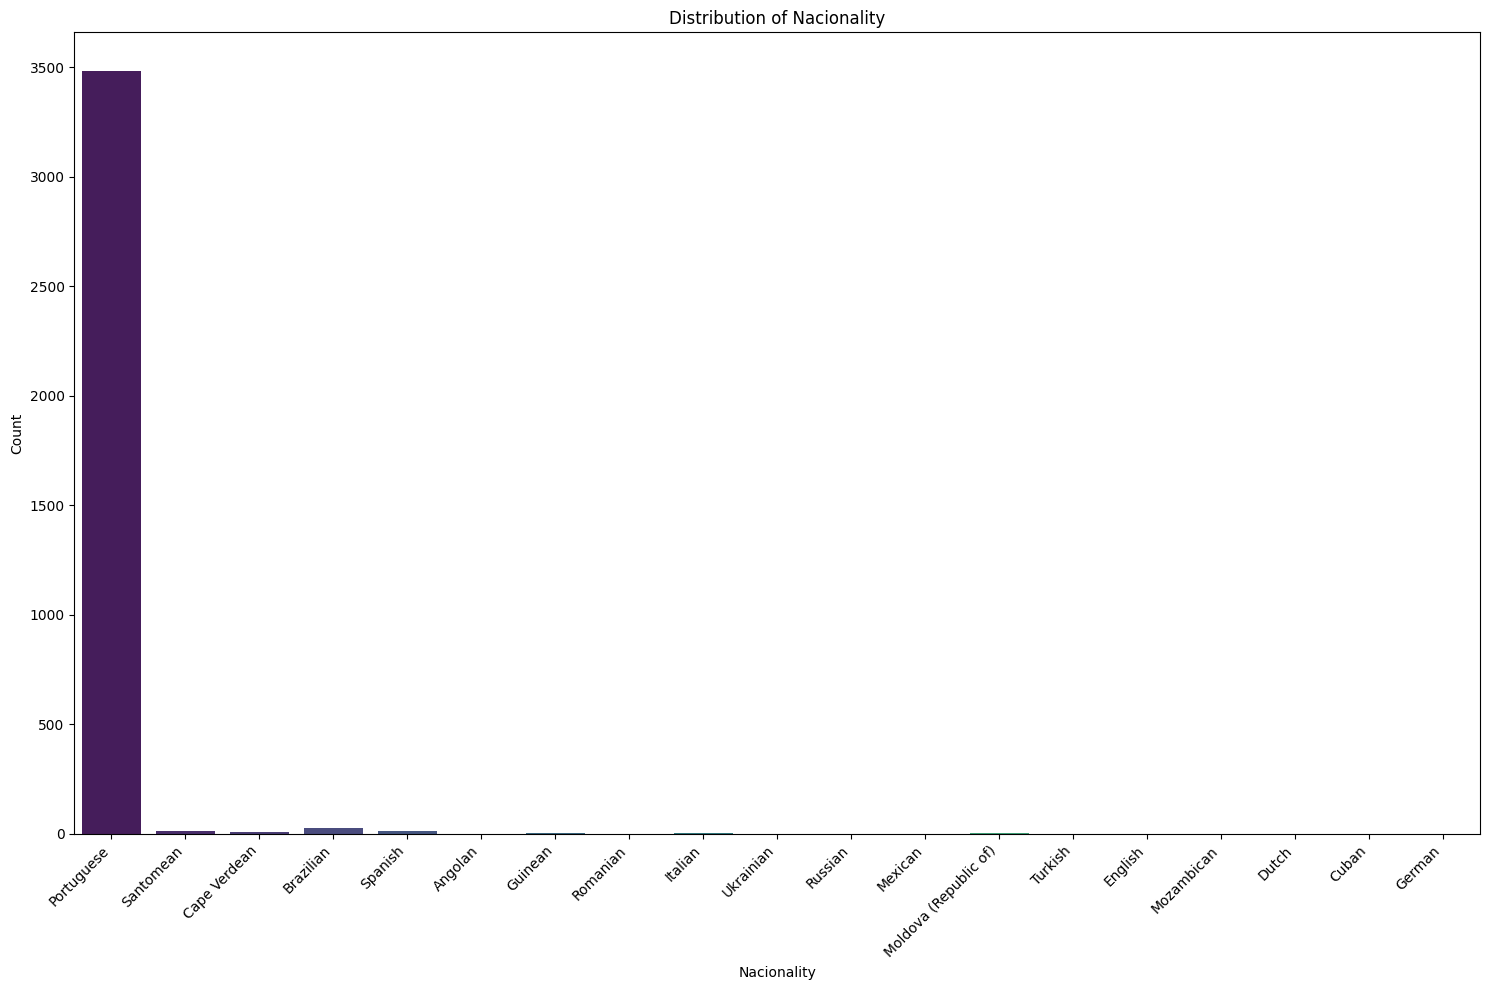

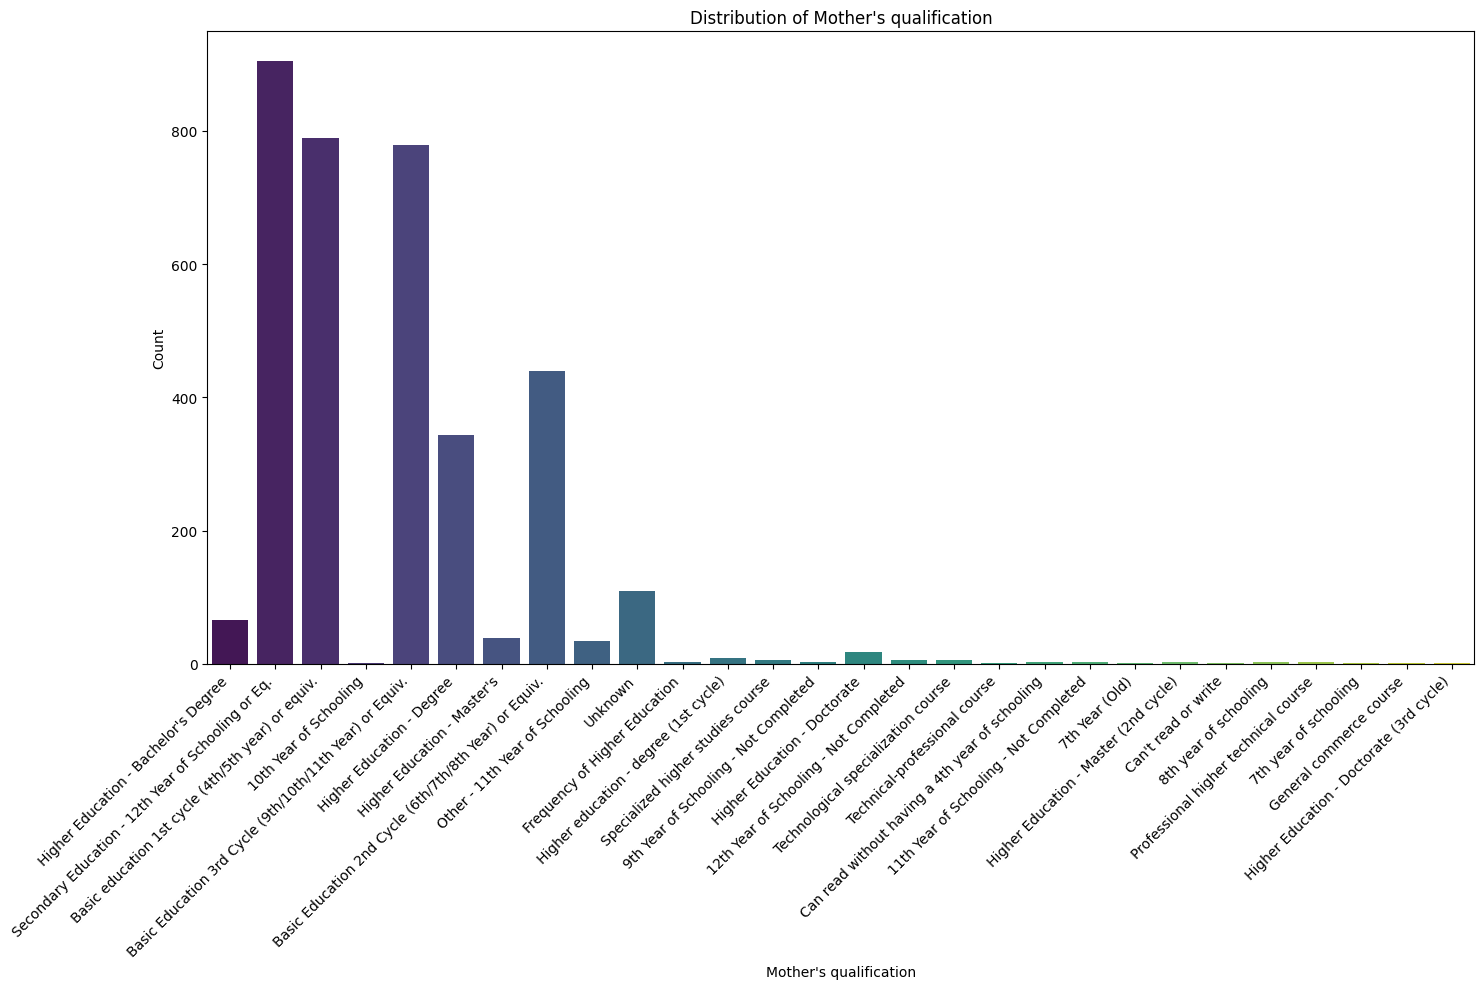

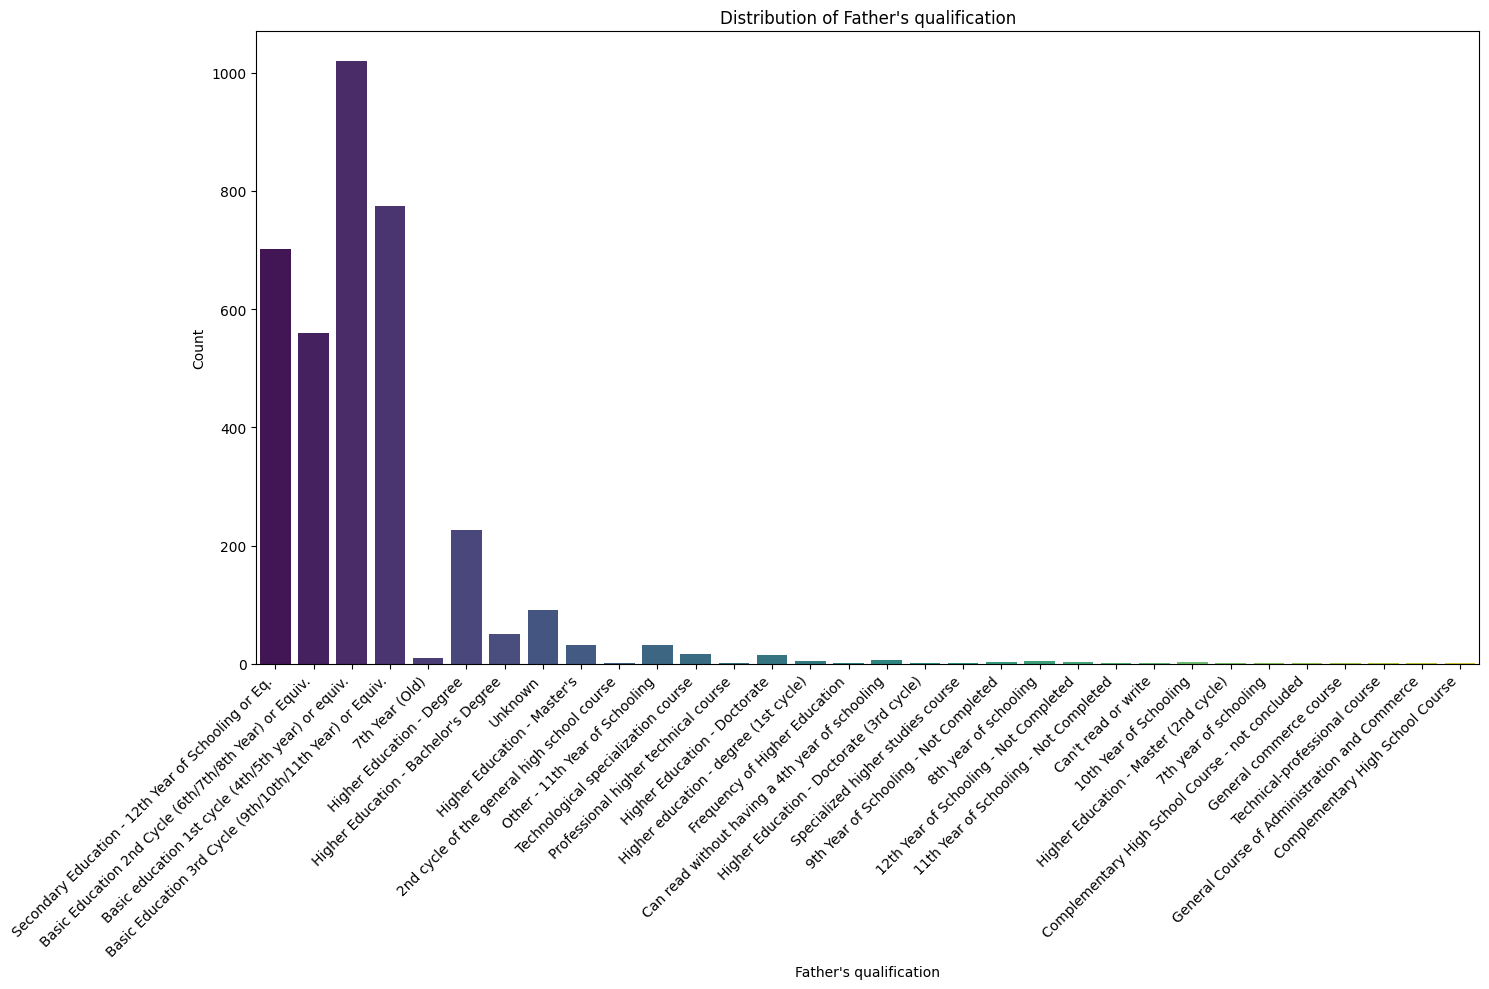

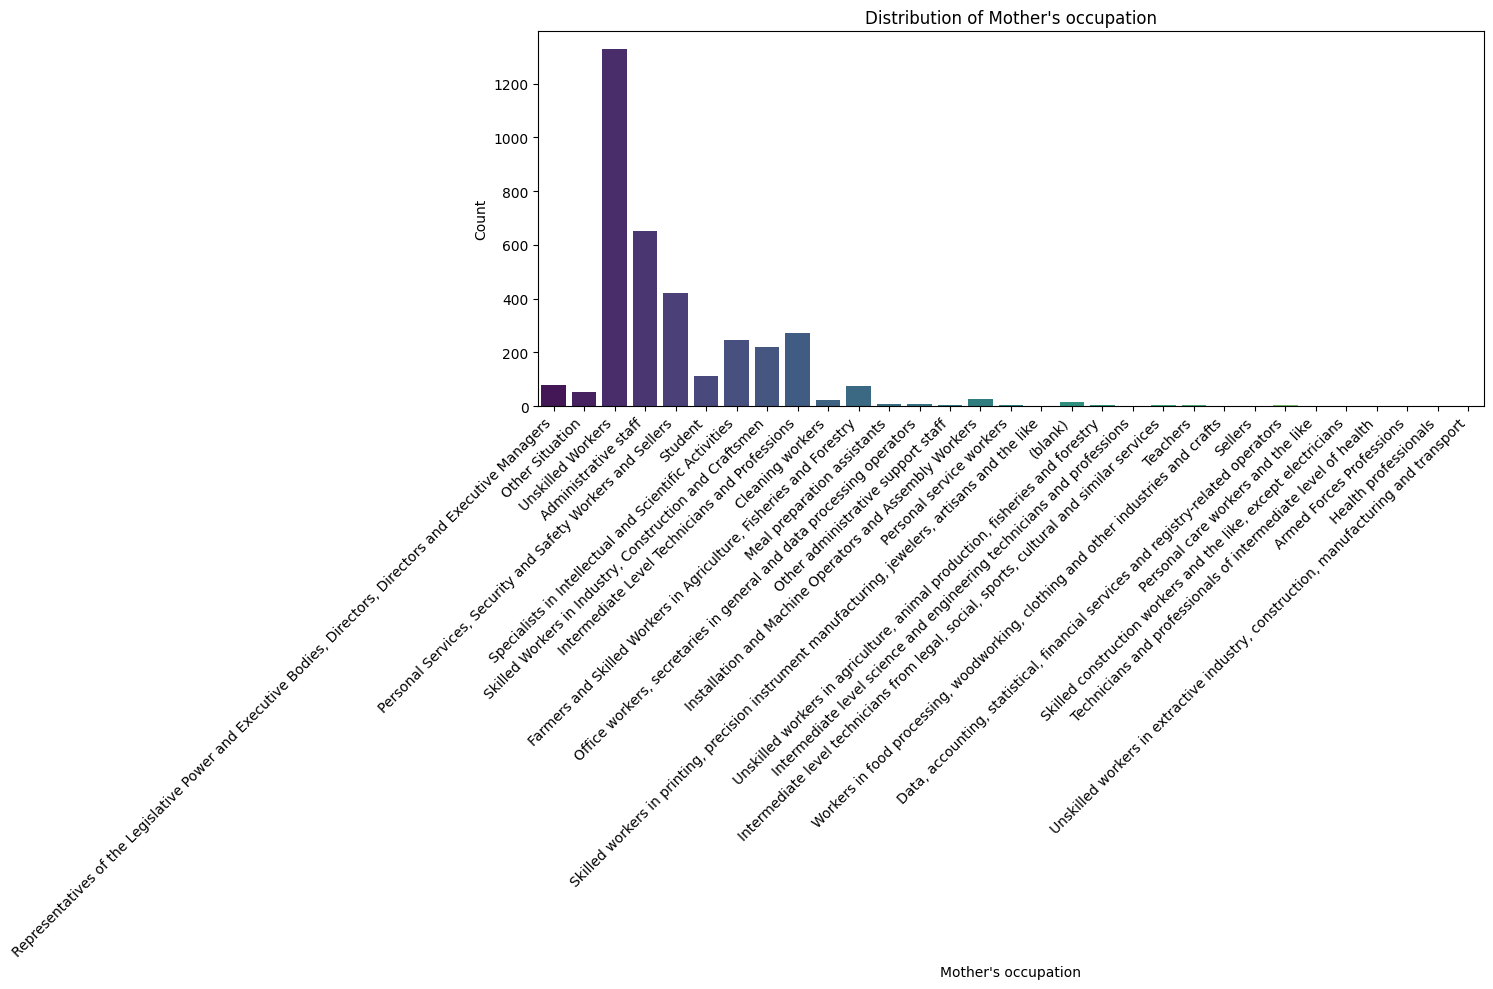

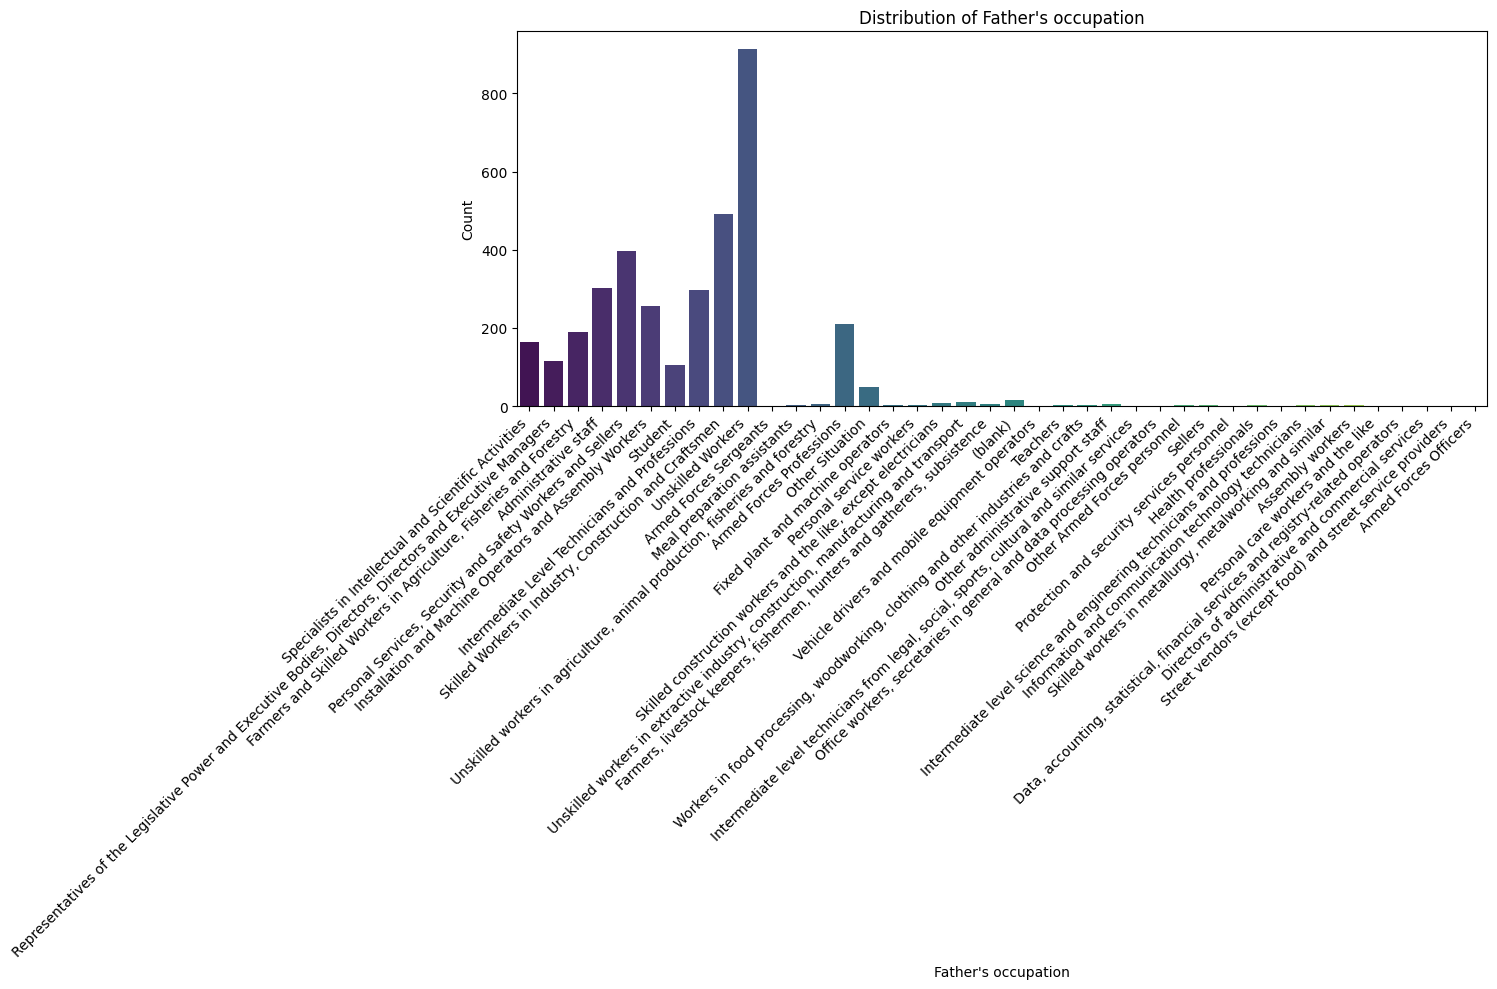

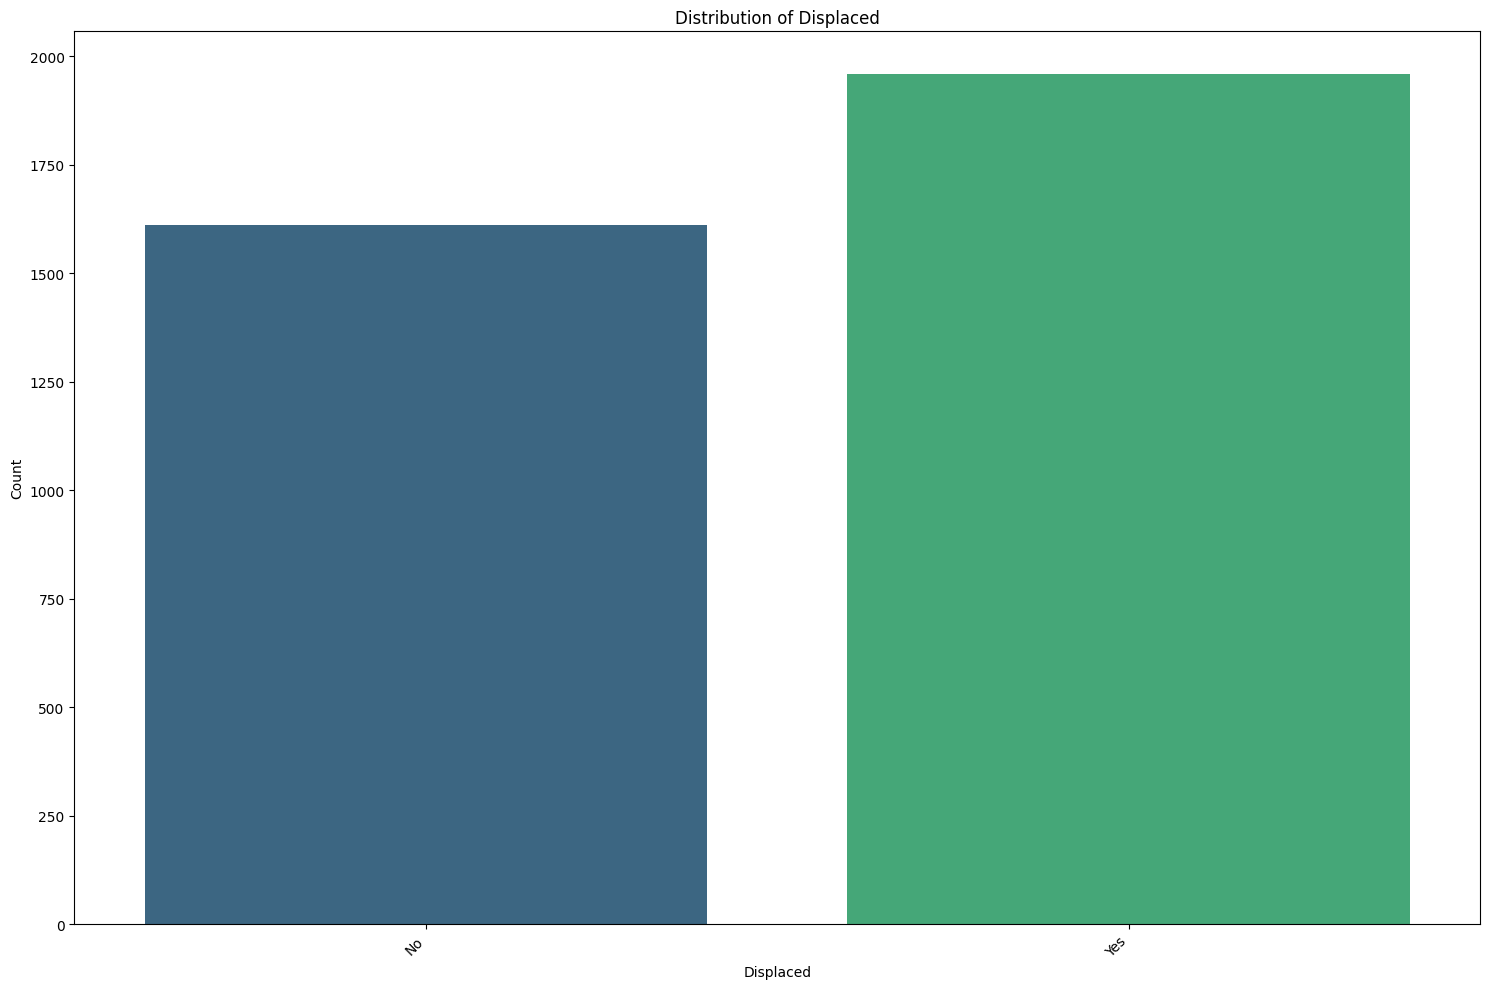

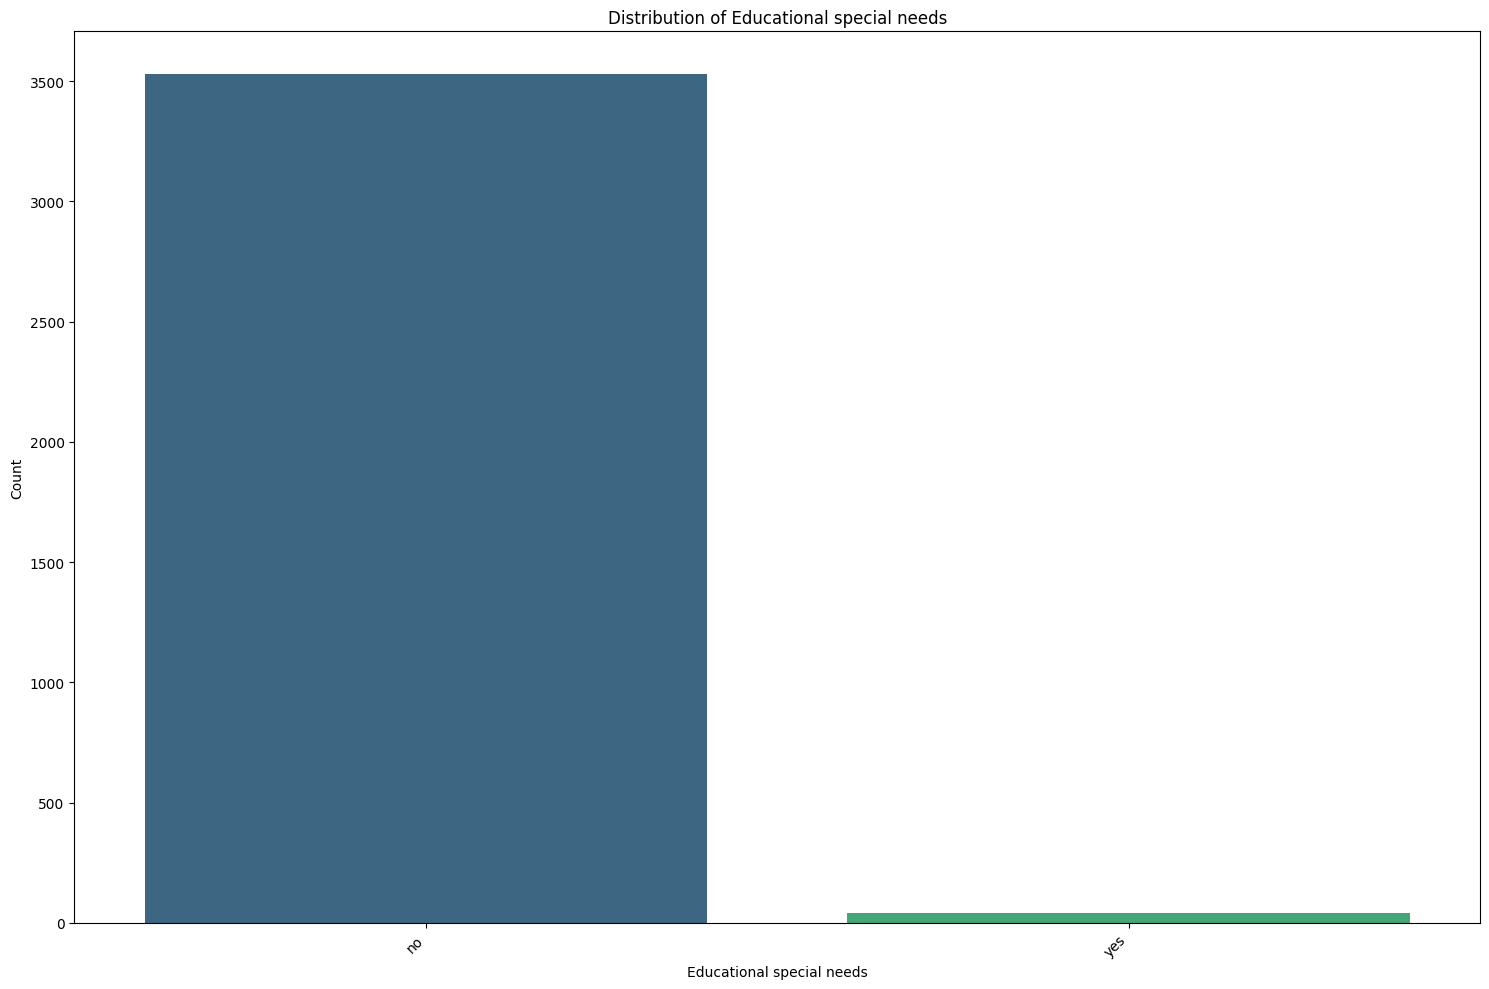

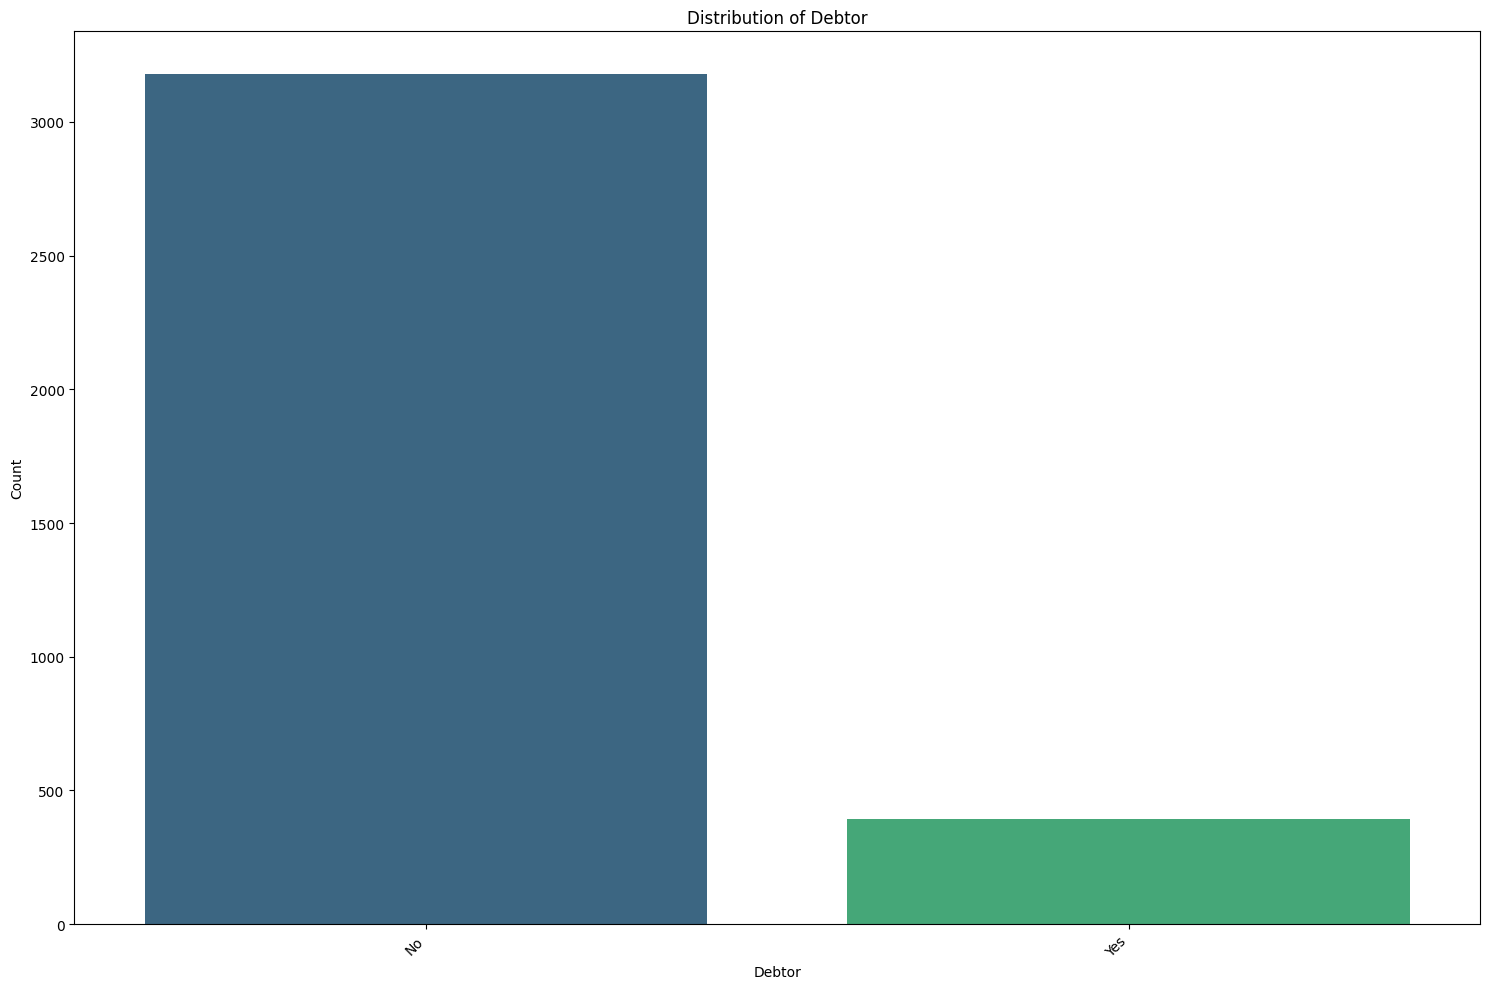

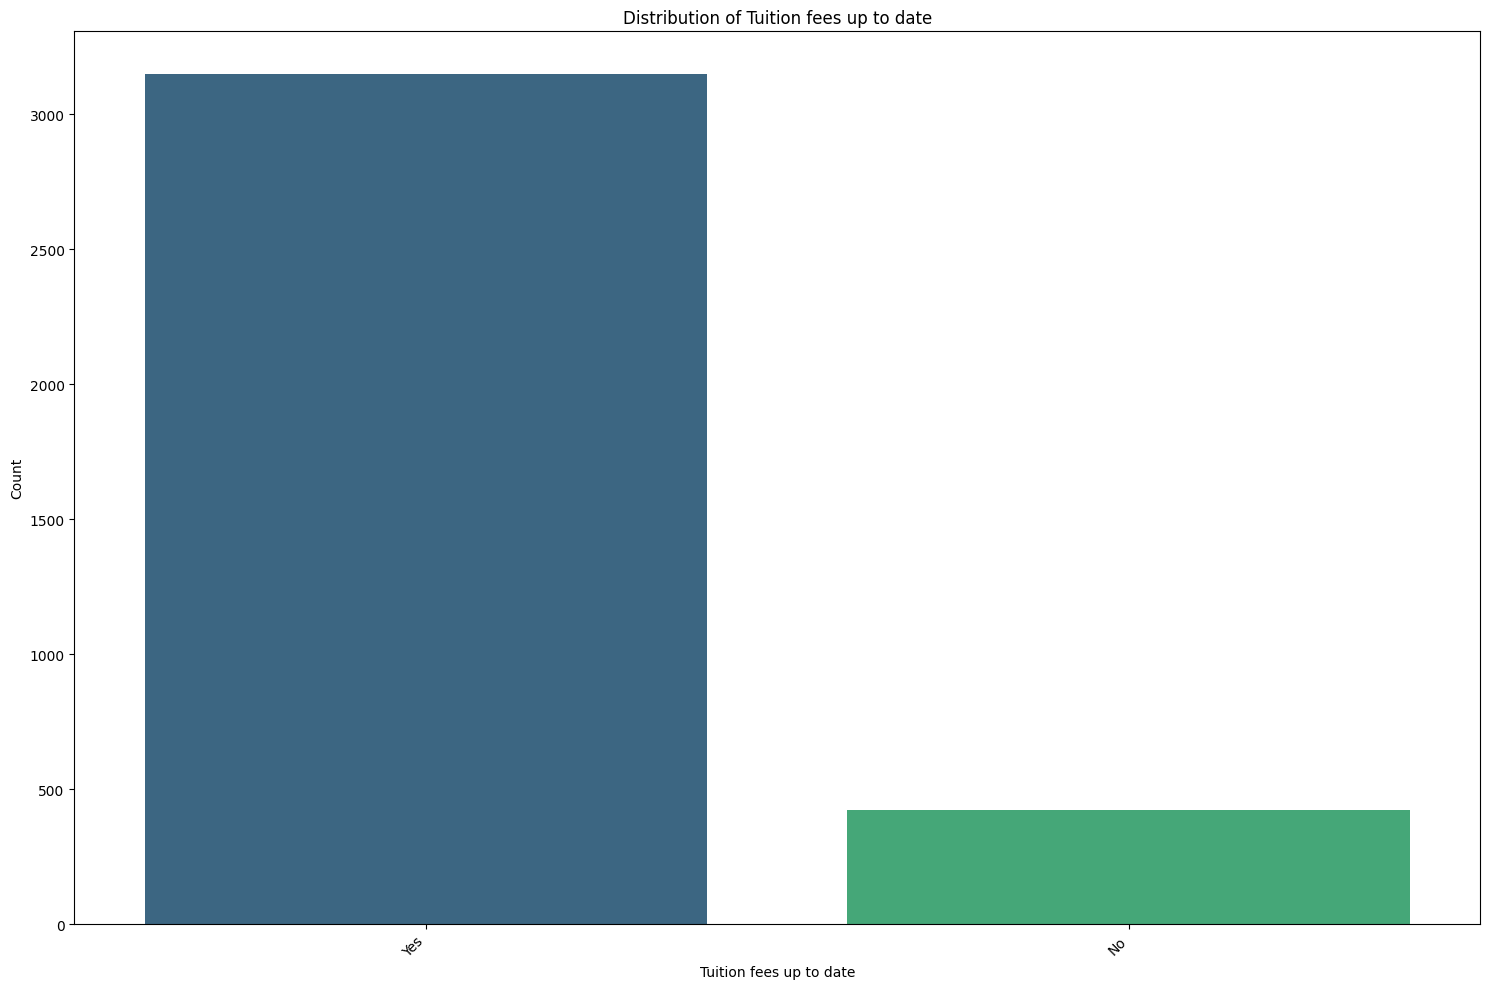

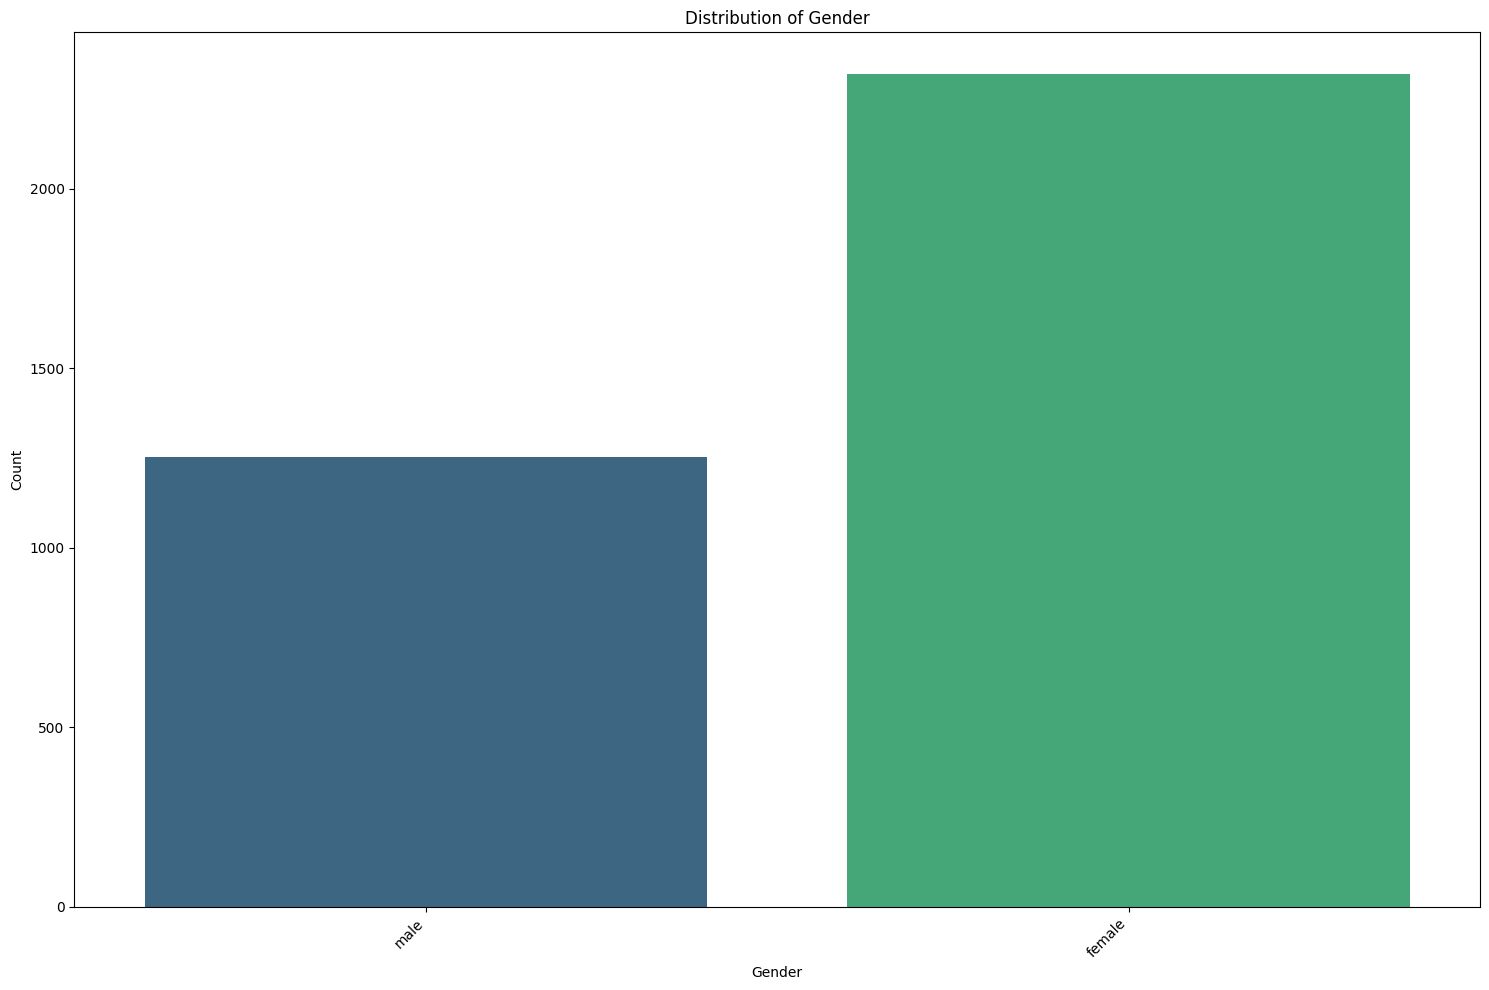

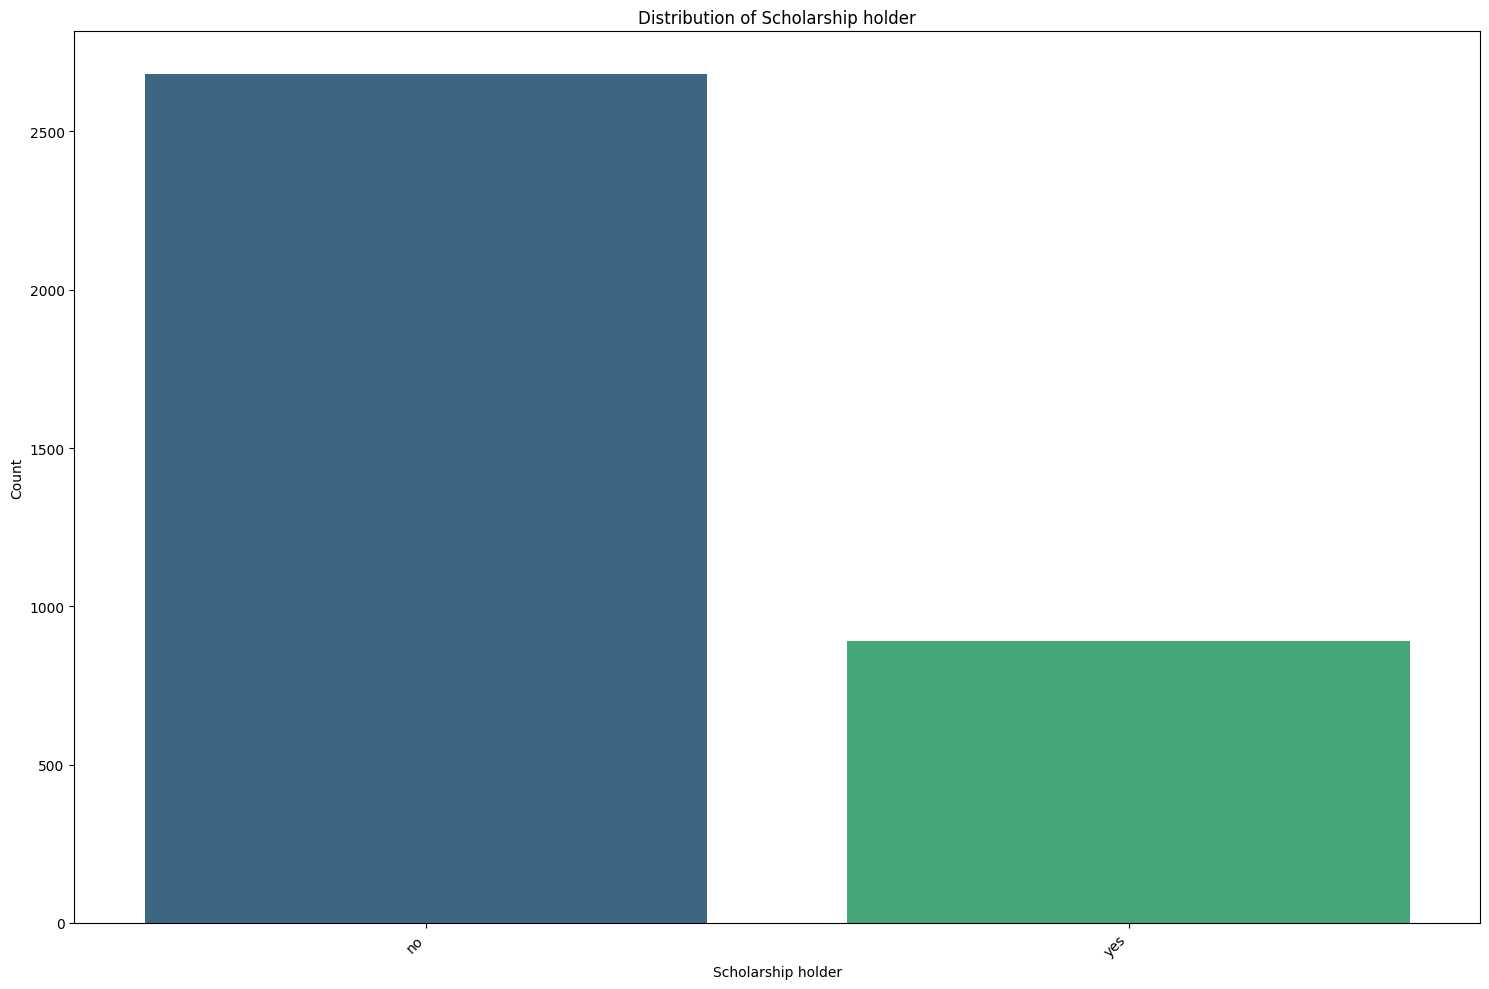

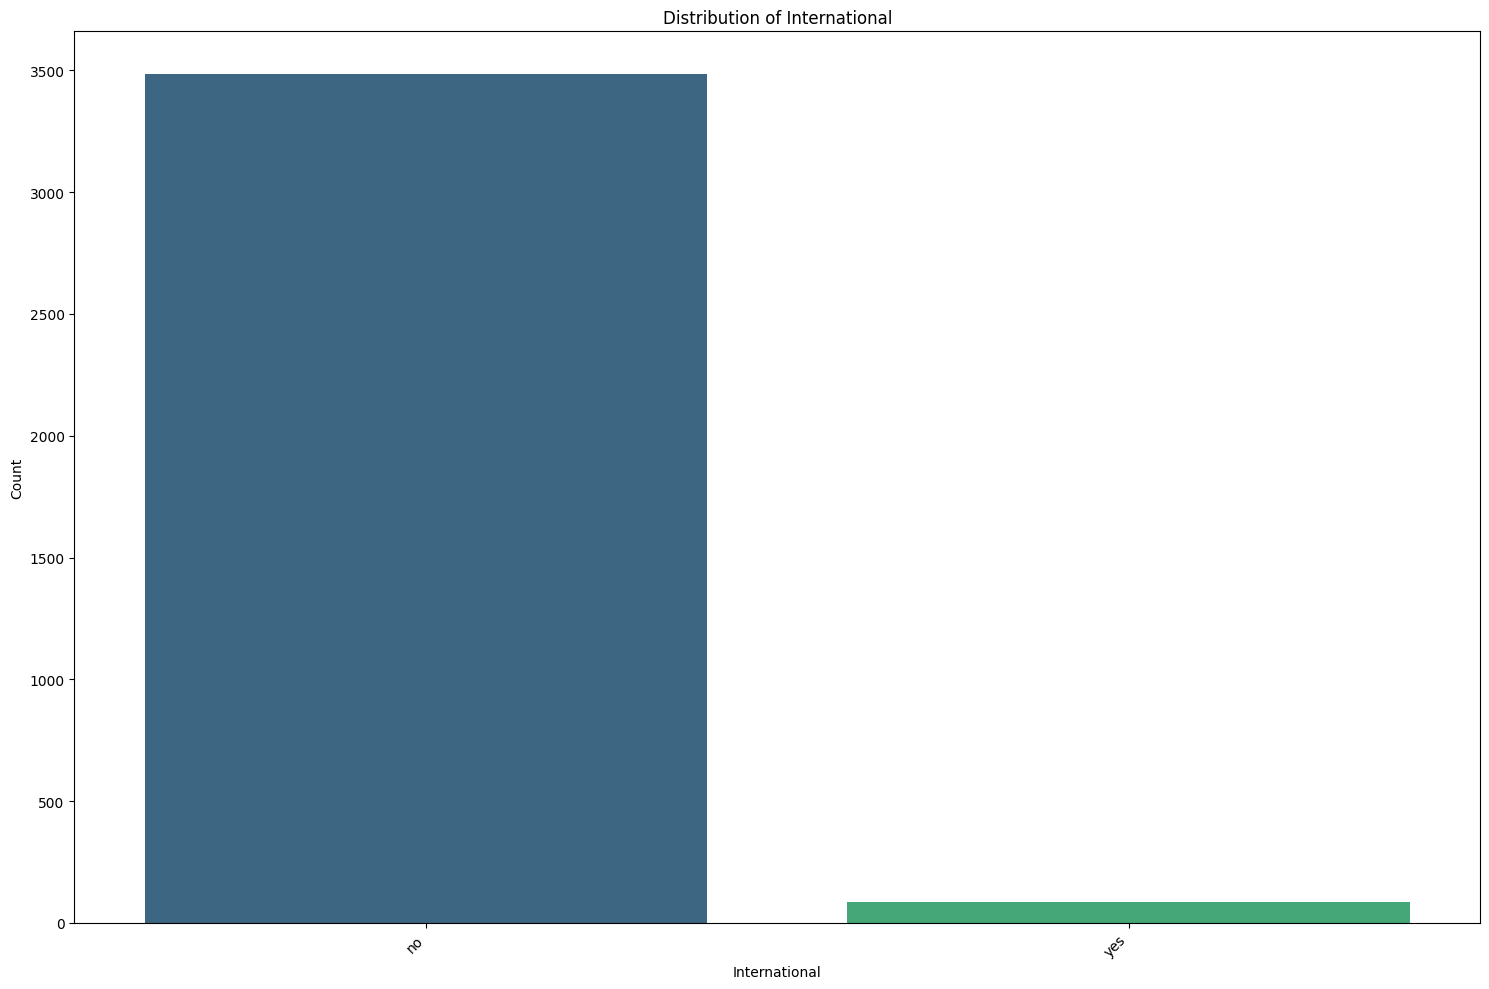

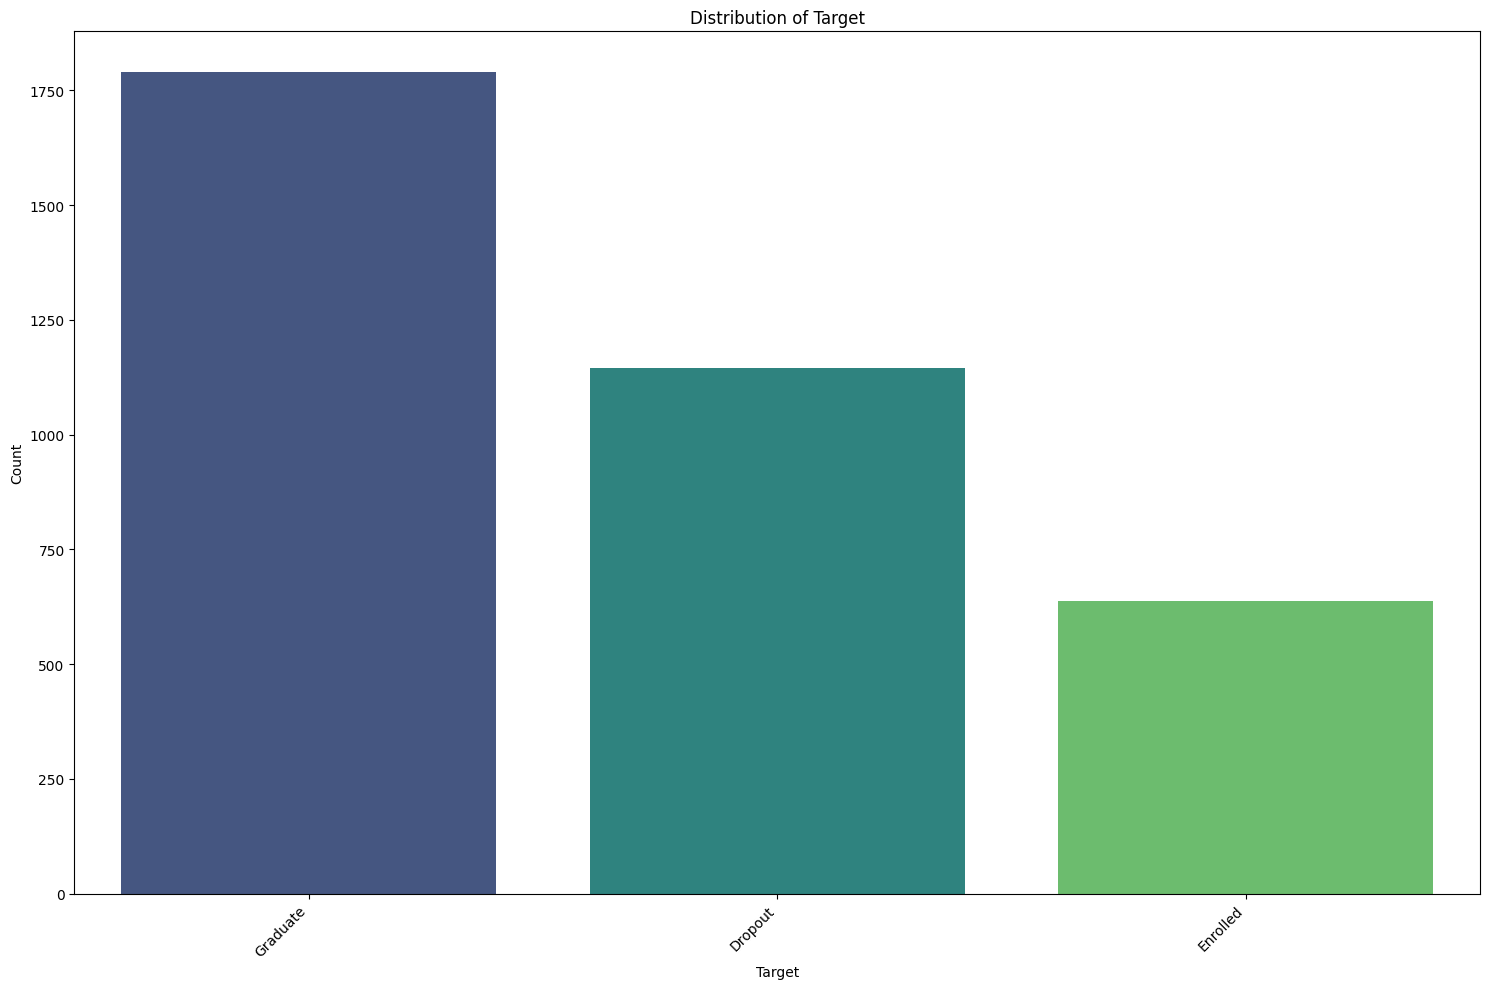

In [433]:
for col in cat_cols:
  if col == 'Student_ID' or col == 'Application_ID' or col == 'Registration_Code':
    continue
  plt.figure(figsize=(15, 10))
  sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

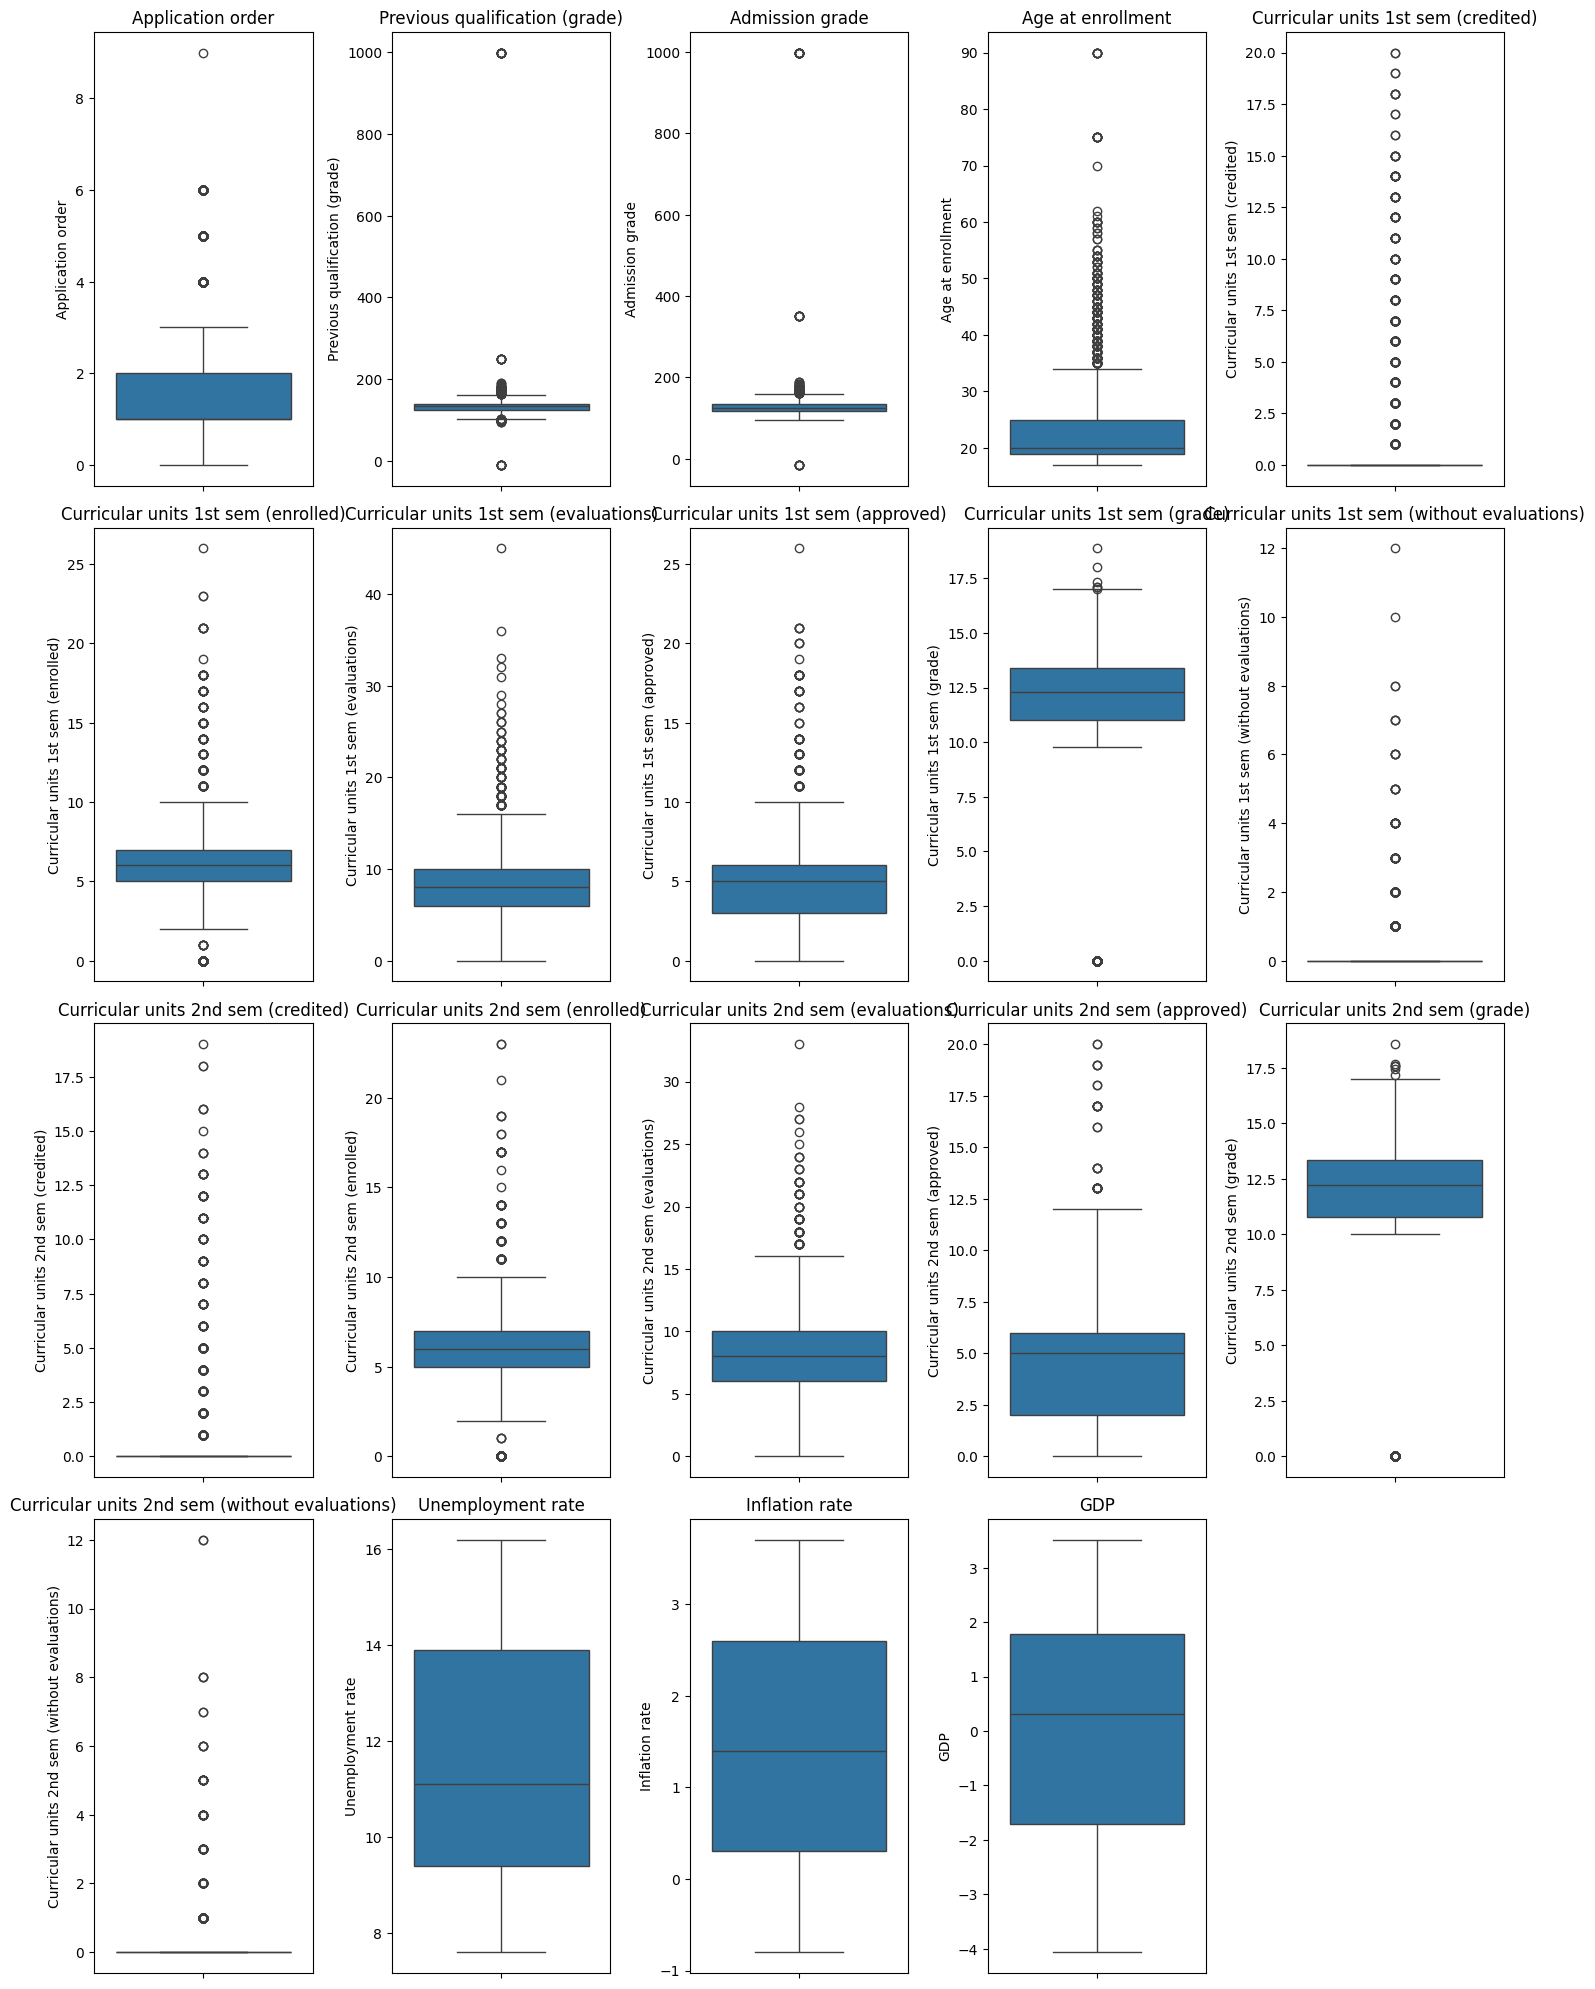

In [434]:
plt.figure(figsize=(15,20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,5,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

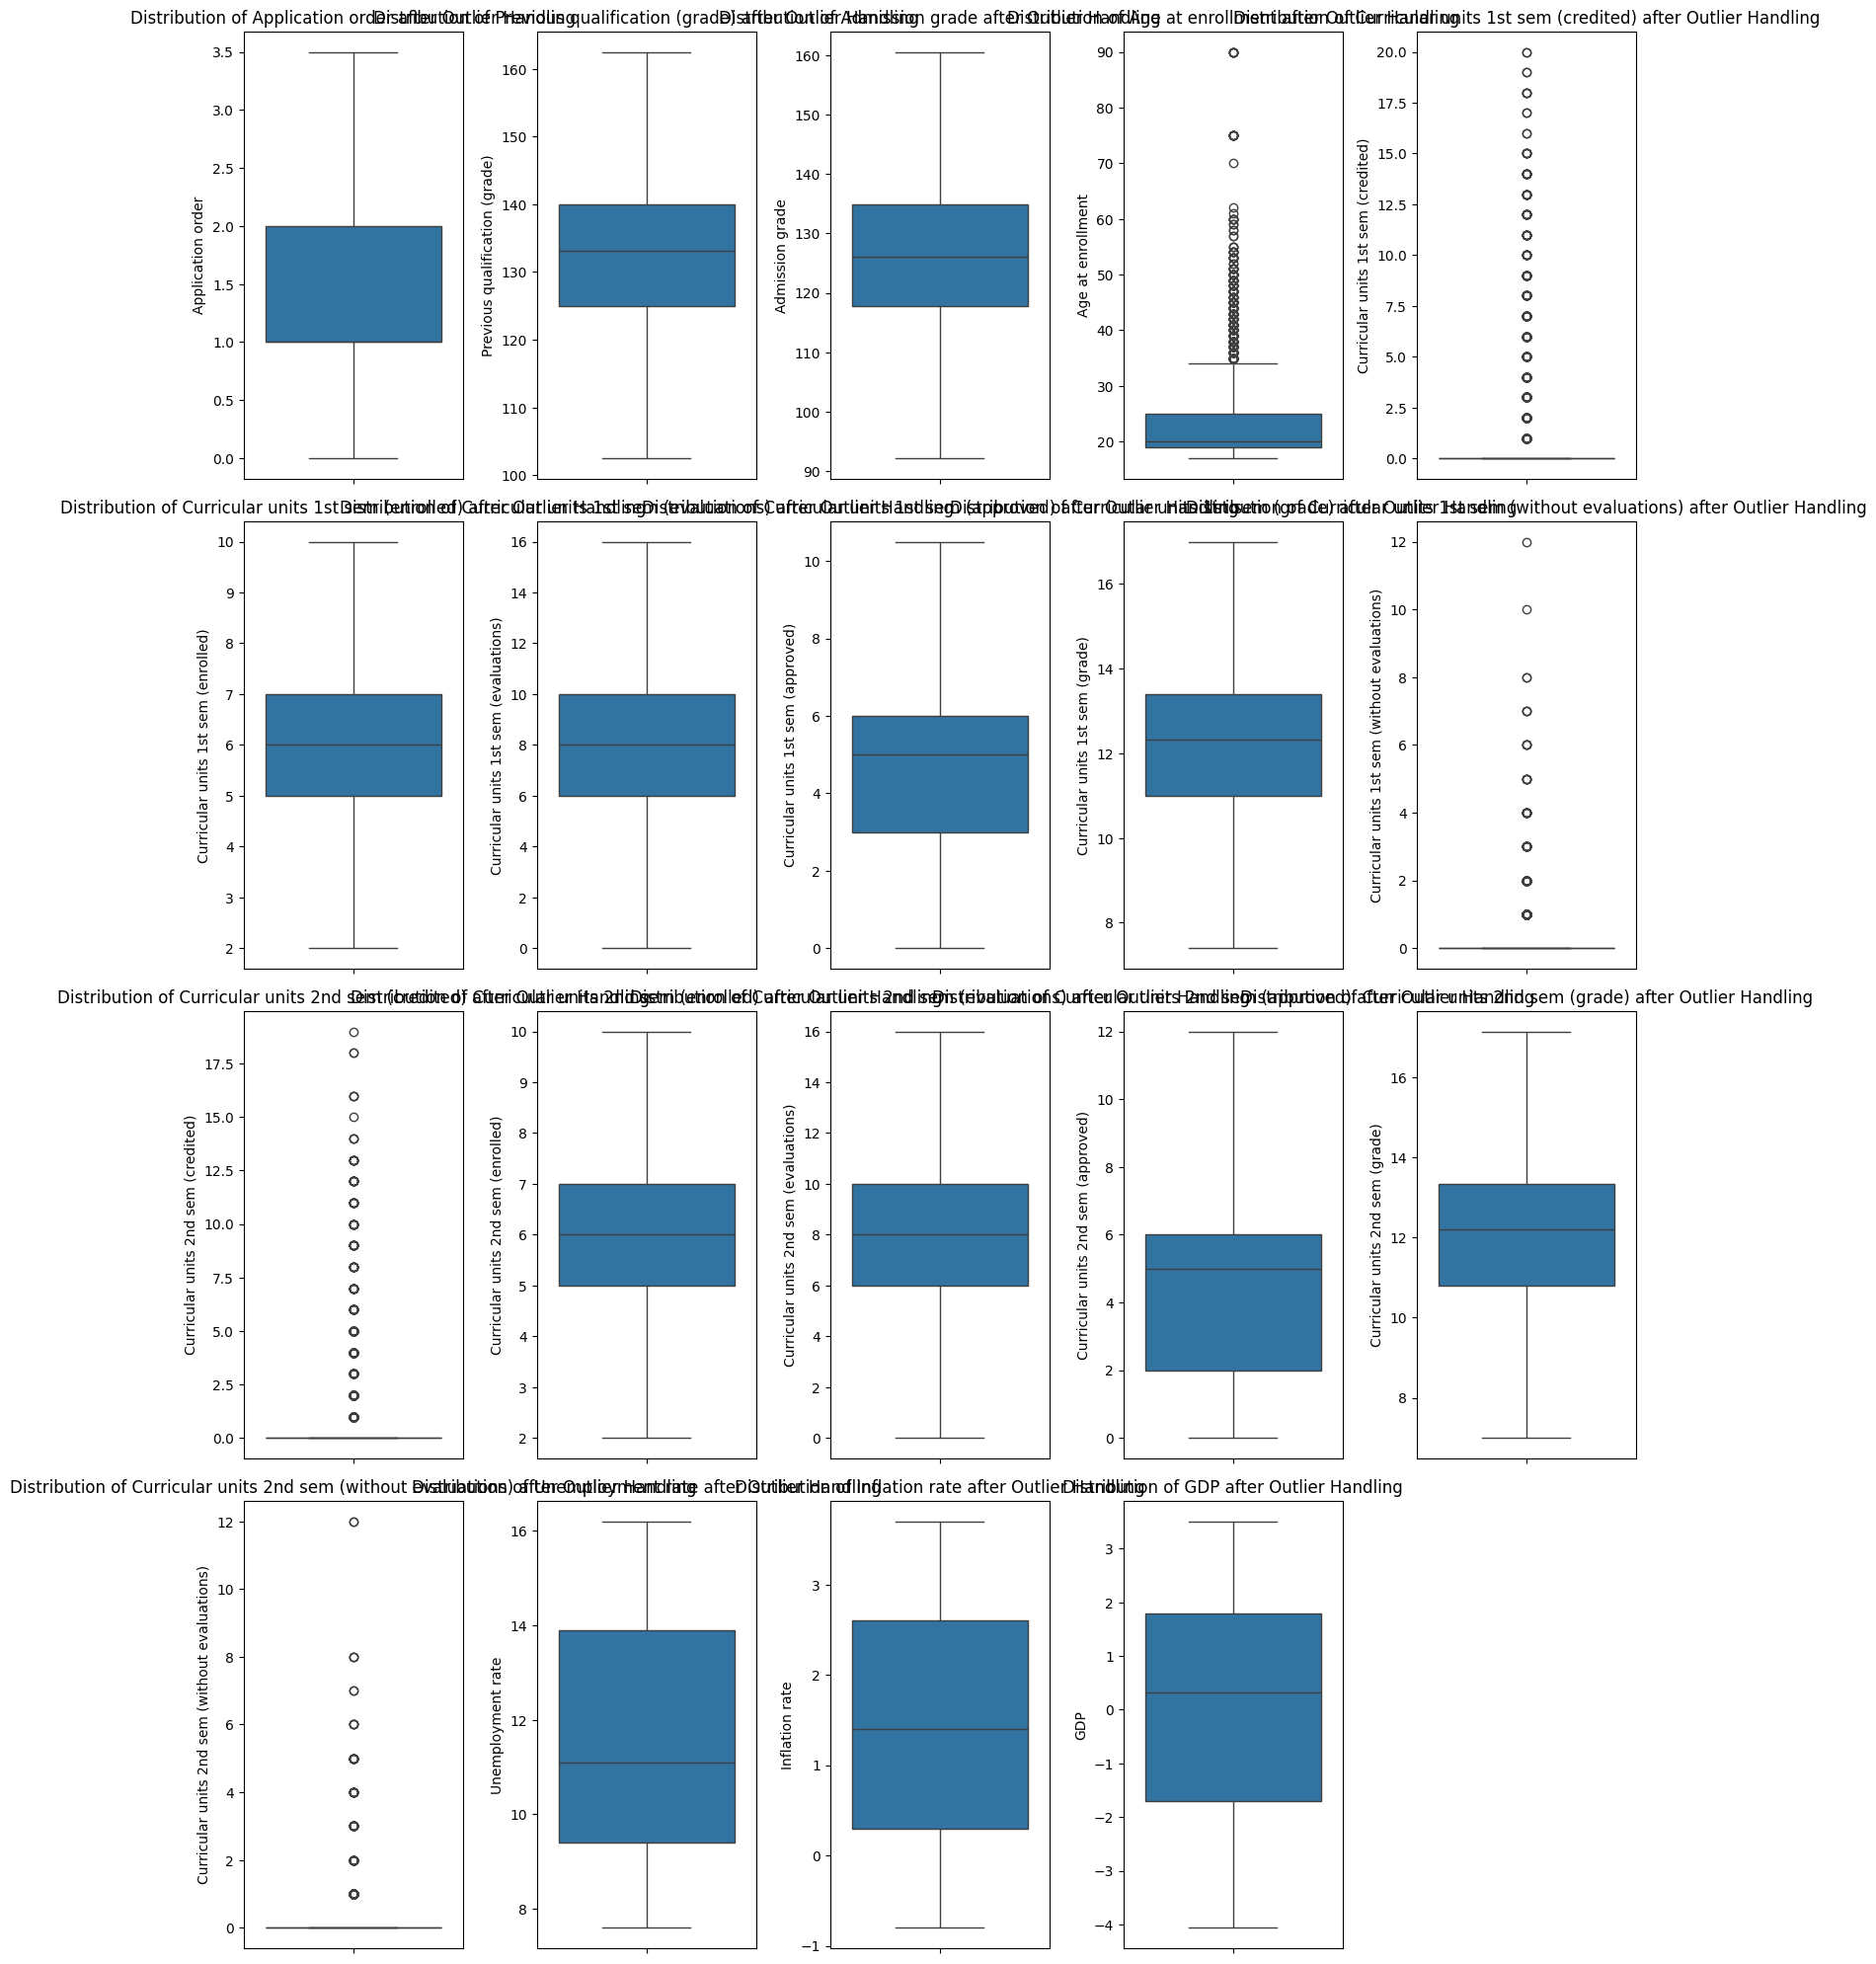

In [435]:
for col in num_cols:
  if col == 'Age at enrollment' or col == 'Curricular units 1st sem (credited)' or col == 'Curricular units 2nd sem (credited)' or col == 'Curricular units 1st sem (without evaluations)' or col == 'Curricular units 2nd sem (without evaluations)':
    continue

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
  df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

plt.figure(figsize=(15,20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4,5,i)
    sns.boxplot(y=df[col])
    plt.title(f'Distribution of {col} after Outlier Handling')
plt.tight_layout()
plt.show()

In [436]:
df['Curricular units 1st sem (credited)'].value_counts()

Curricular units 1st sem (credited)
0     3099
2       77
1       71
3       54
6       42
4       41
7       36
5       32
8       24
9       23
12      12
14      12
11      11
10      10
13      10
15       6
18       4
19       2
17       2
20       2
16       2
Name: count, dtype: int64

/tmp/ipykernel_58/3990568760.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age Group', palette='viridis')


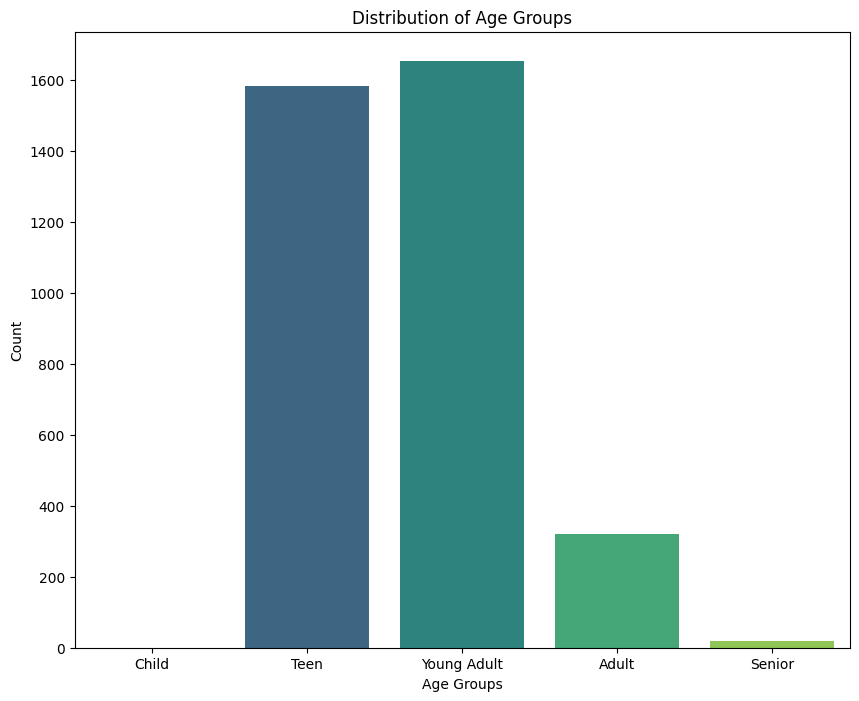

In [437]:
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['Age Group'] = pd.cut(df['Age at enrollment'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='Age Group', palette='viridis')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Groups')
plt.ylabel('Count')
plt.show()

df = df.drop('Age Group', axis=1)

/tmp/ipykernel_58/3250984409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, order=Target_Levels, ax=ax, palette='viridis')
/tmp/ipykernel_58/3250984409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, order=Target_Levels, ax=ax, palette='viridis')
/tmp/ipykernel_58/3250984409.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y=col, order=Target_Levels, ax=ax, palette='viridis')
/tmp/ipykernel_58/3250984409.py:5: FutureWarning: 

Passing `palette` without a

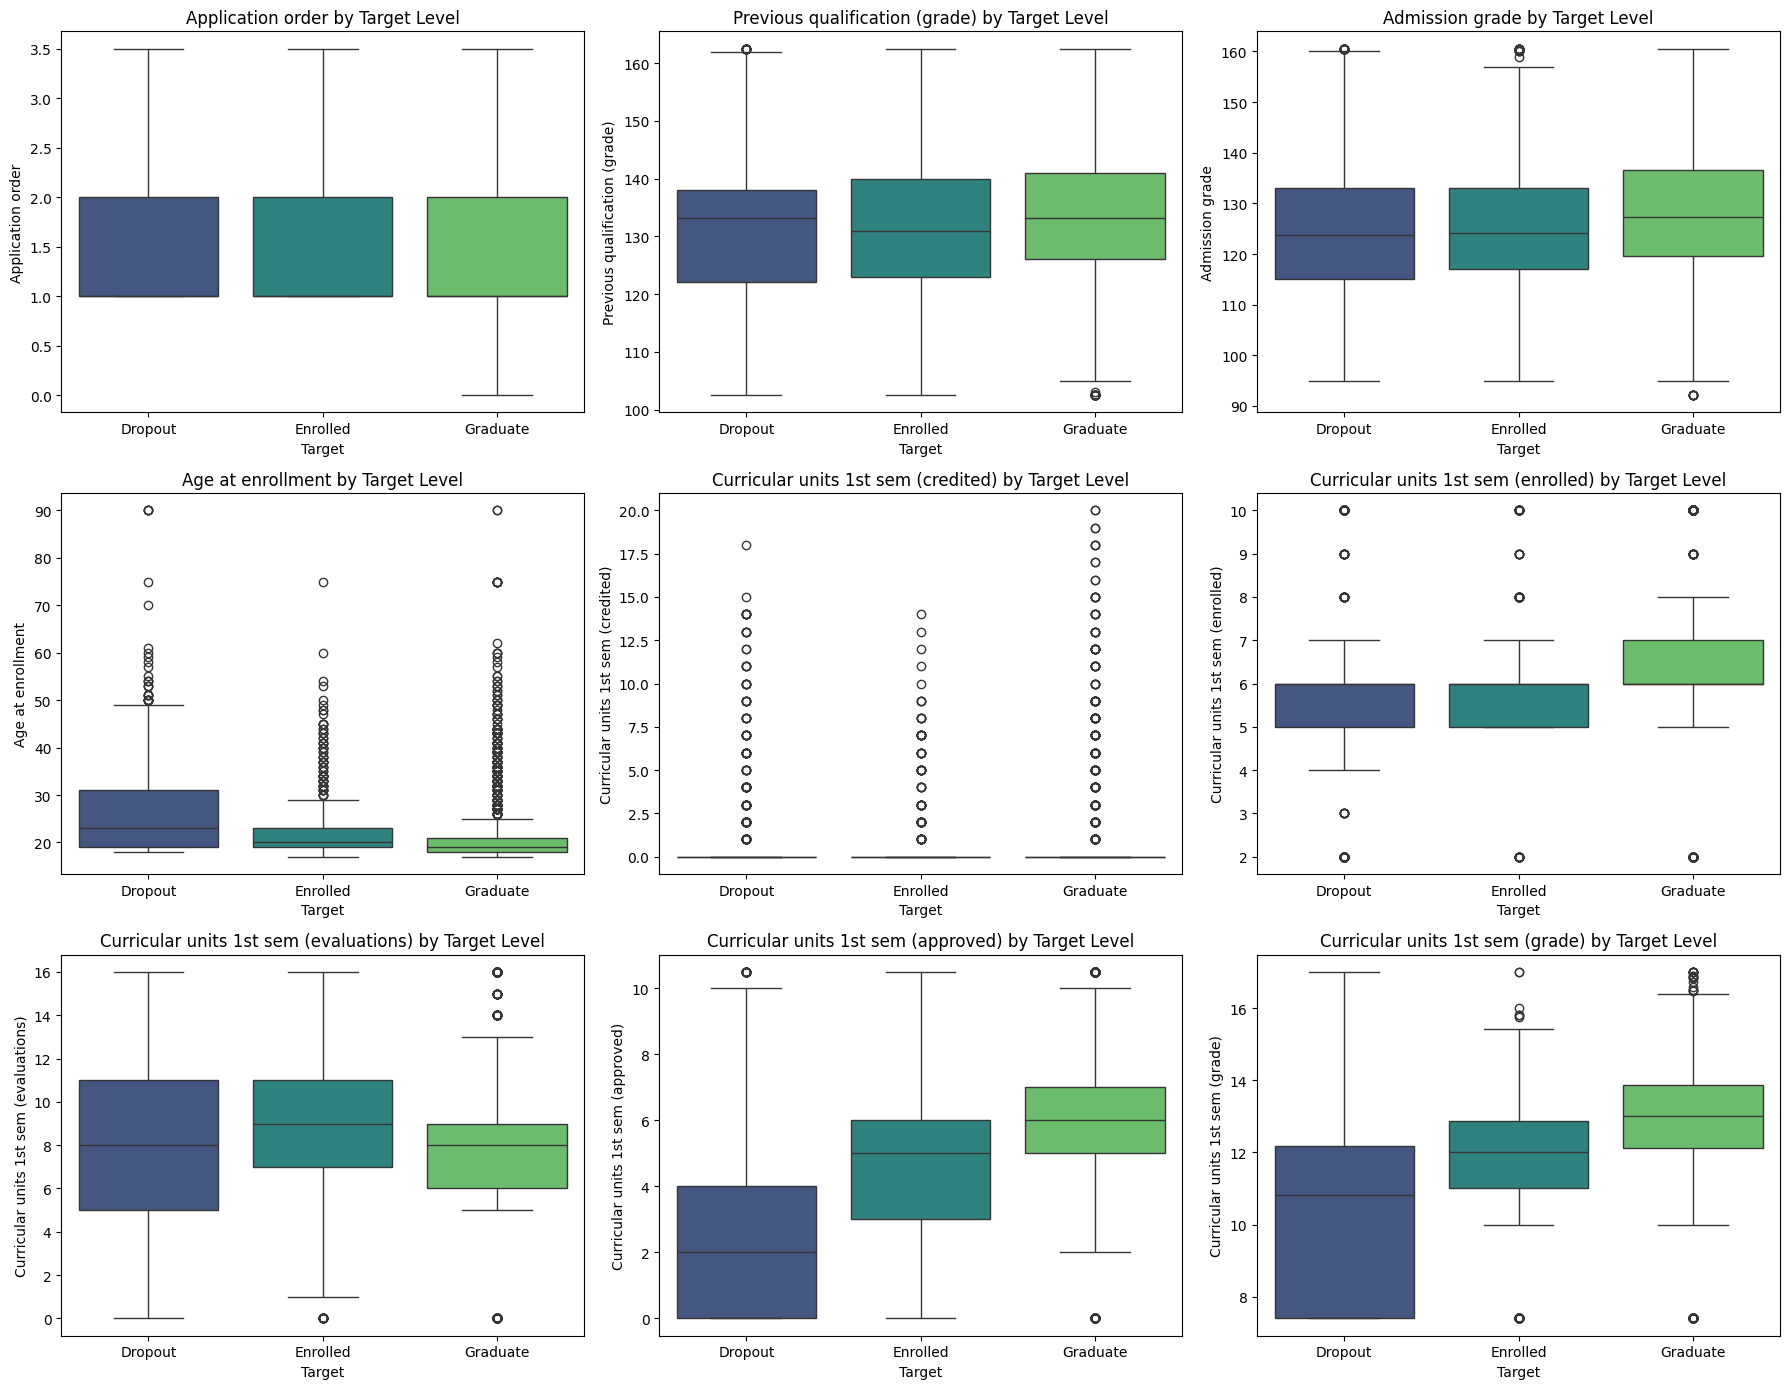

In [438]:
Target_Levels = ['Dropout', 'Enrolled', 'Graduate']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x='Target', y=col, order=Target_Levels, ax=ax, palette='viridis')
    ax.set_title(f'{col} by Target Level')
plt.tight_layout()
plt.show()

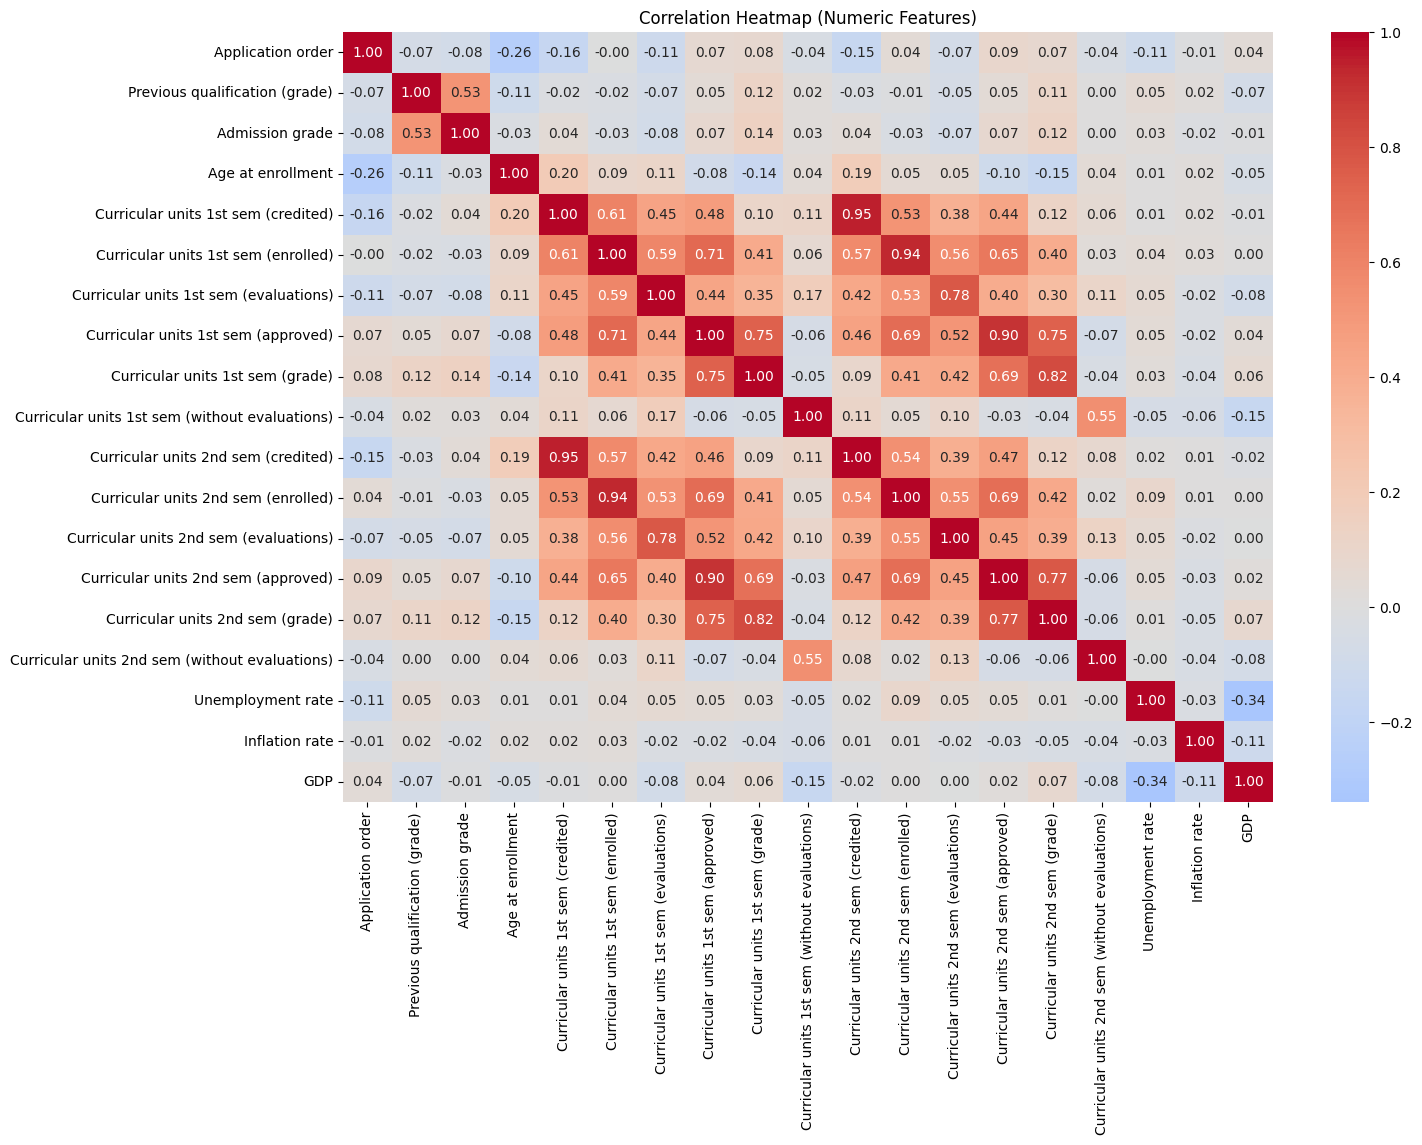

In [439]:
plt.figure(figsize=(15, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

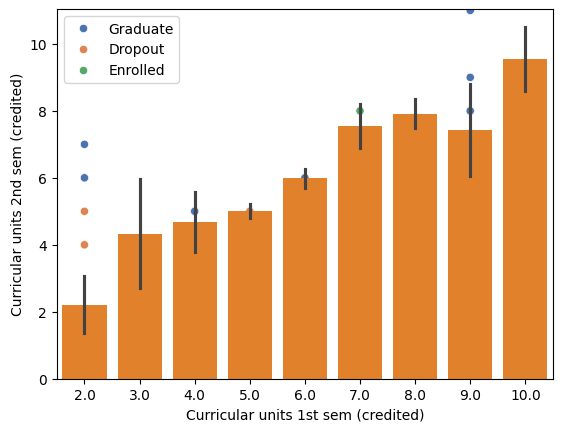

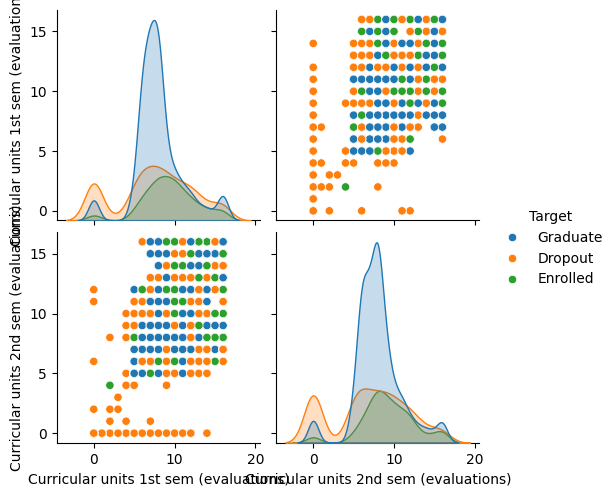

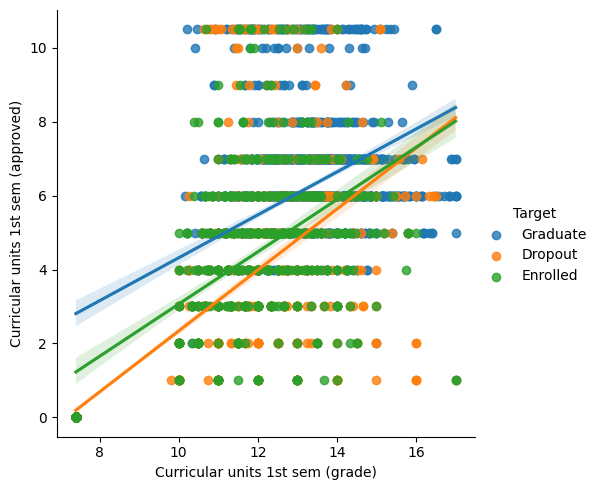

In [440]:
sns.scatterplot(x="Curricular units 1st sem (credited)", y="Curricular units 2nd sem (credited)", hue="Target", data=df, palette="deep") 
sns.barplot(x="Curricular units 1st sem (enrolled)", y="Curricular units 2nd sem (enrolled)", data=df, estimator="mean", errorbar="sd") 
sns.pairplot(df[["Curricular units 1st sem (evaluations)", "Curricular units 2nd sem (evaluations)", "Target"]], hue="Target") # matrix of pairwise plots 
sns.lmplot(x="Curricular units 1st sem (grade)", y="Curricular units 1st sem (approved)", data=df, hue="Target") # scatter + regression line

In [441]:
df.columns

Index(['Student_ID', 'Application_ID', 'Registration_Code', 'Marital status',
       'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricul

In [442]:
test_cat_cols = df2.select_dtypes(include=['object']).columns

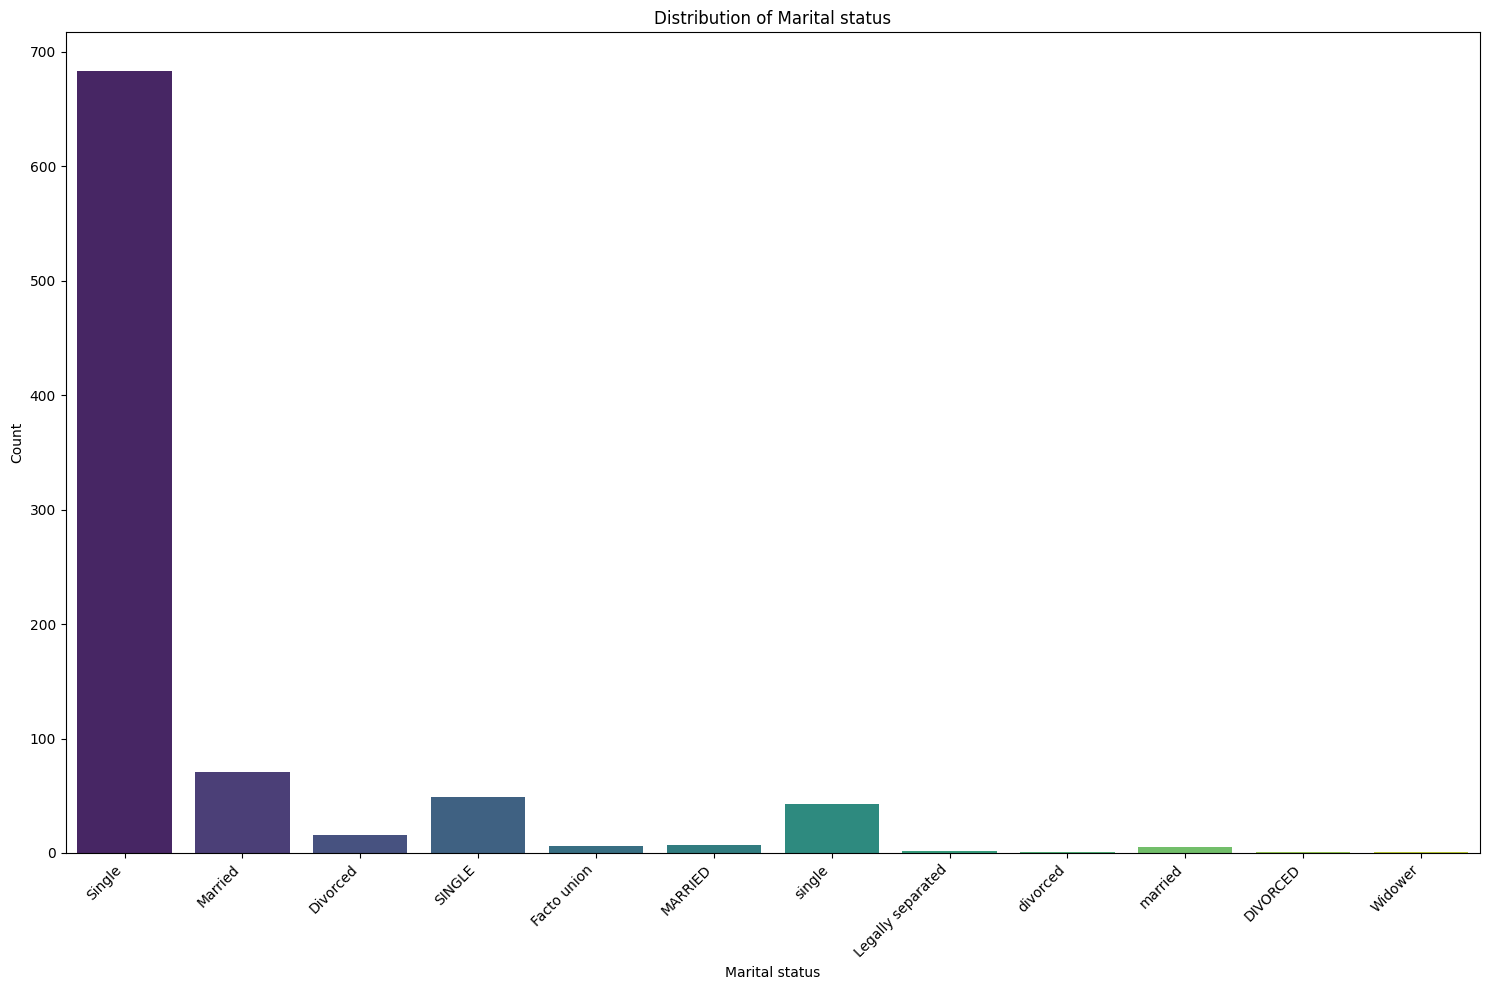

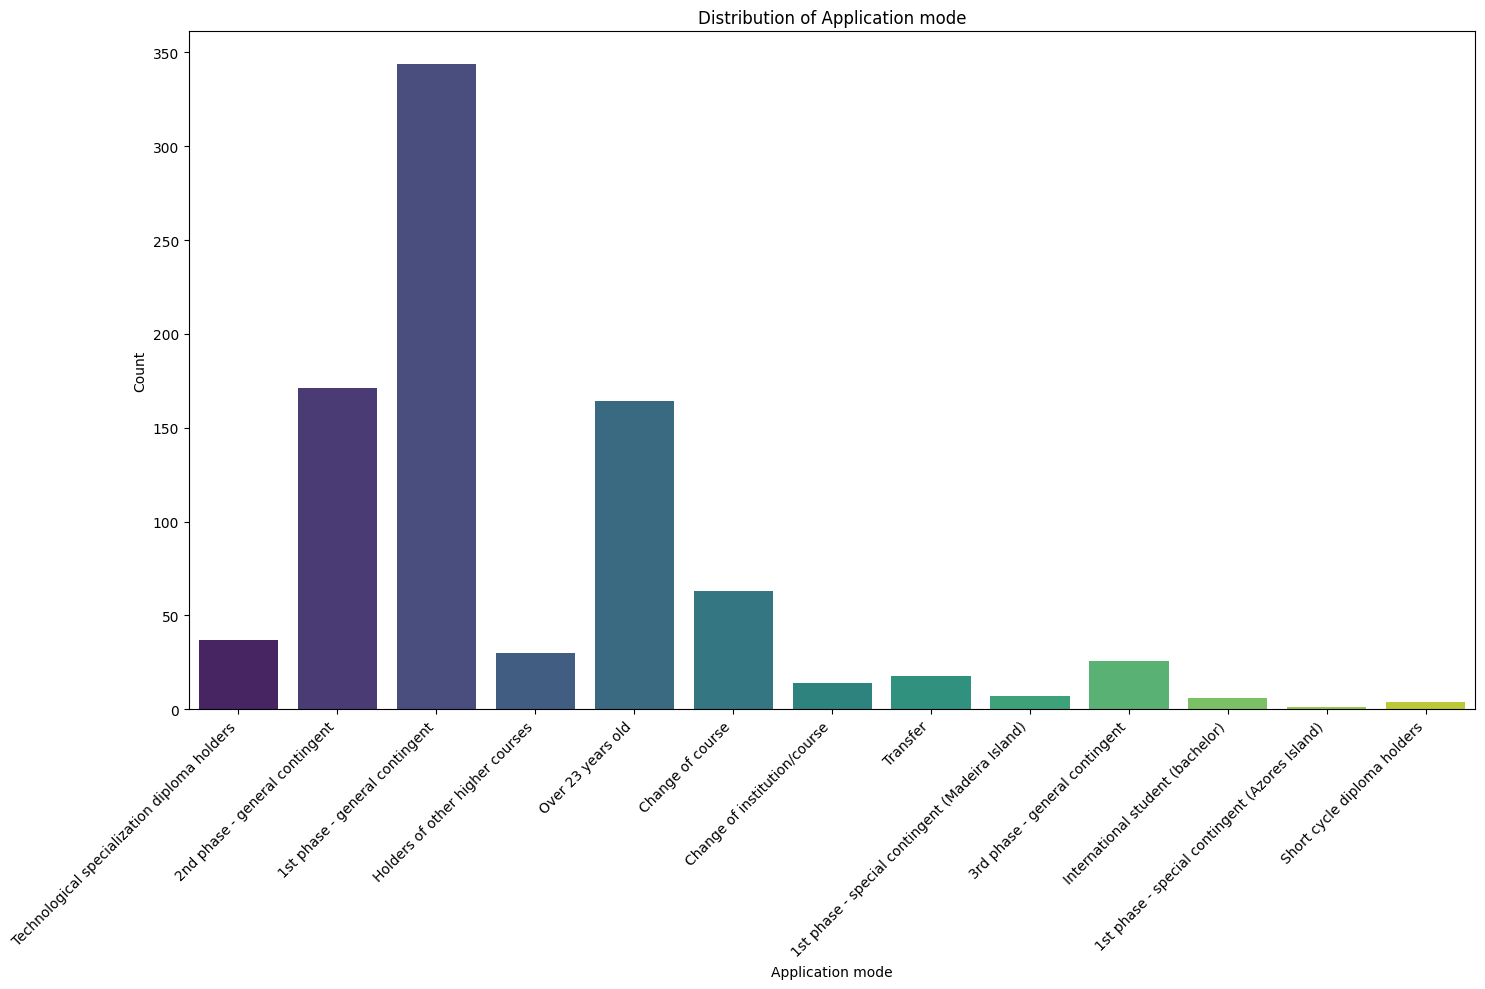

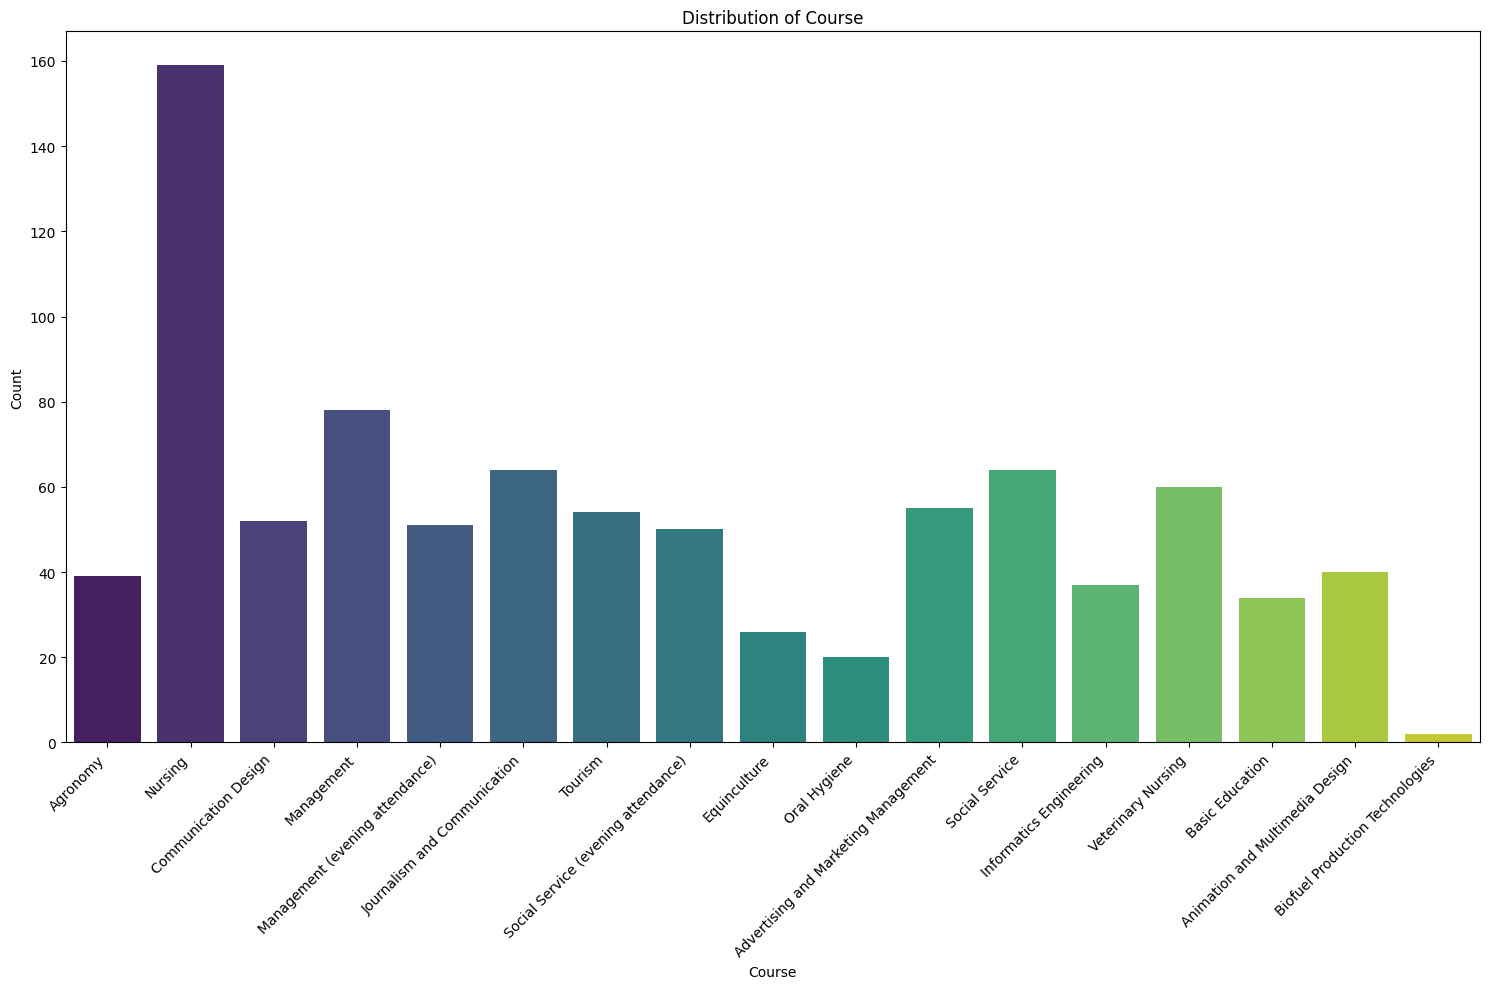

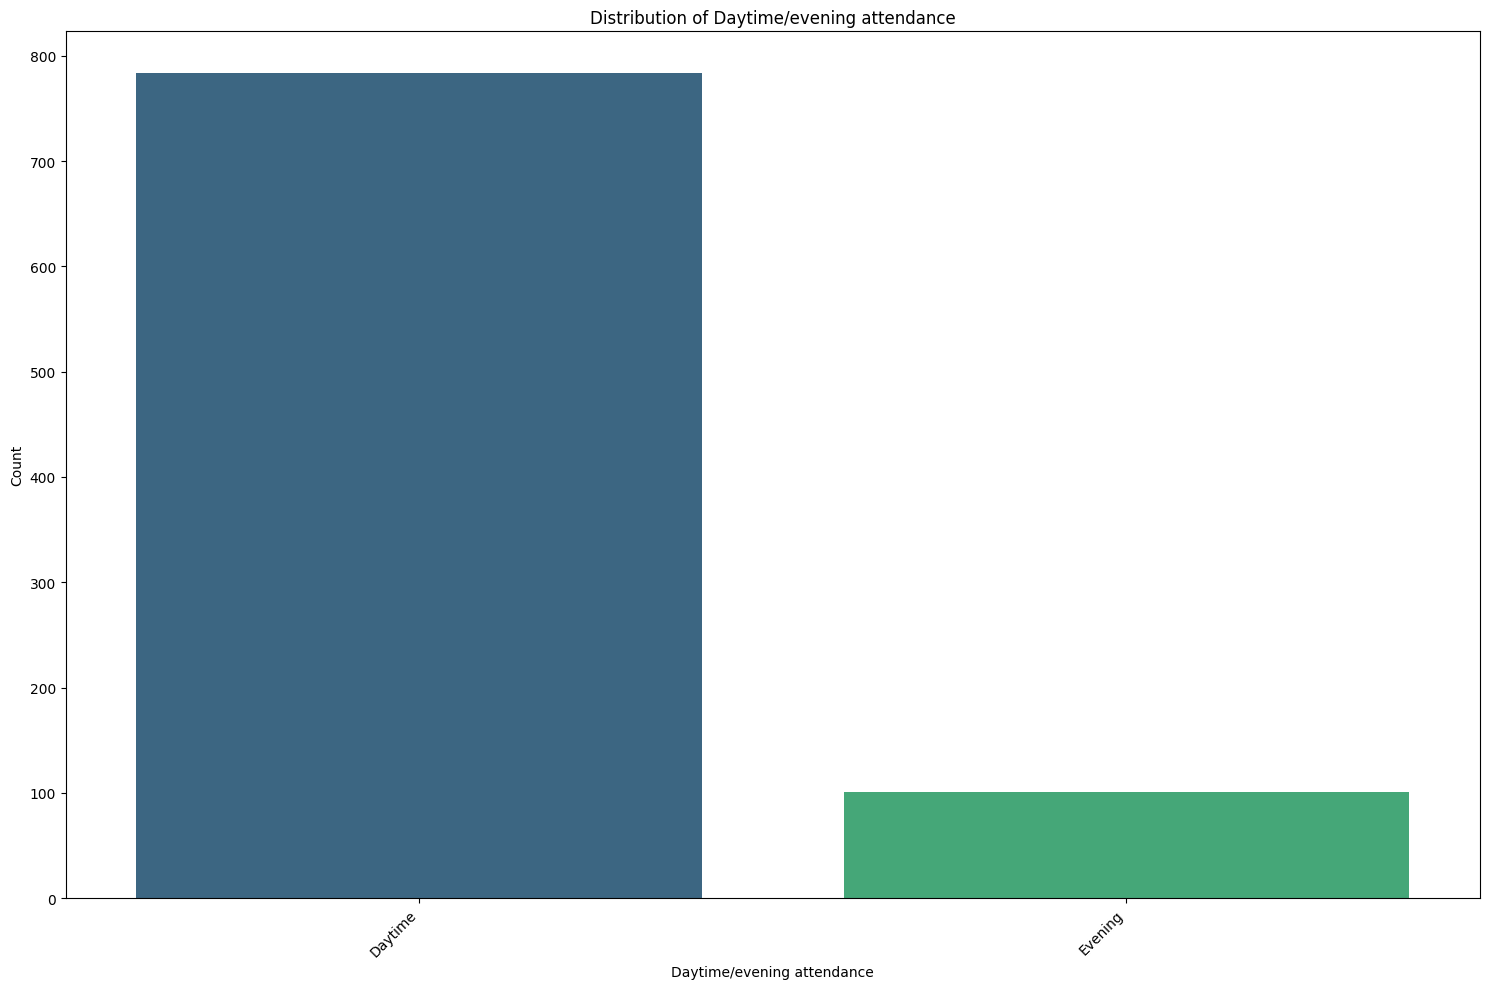

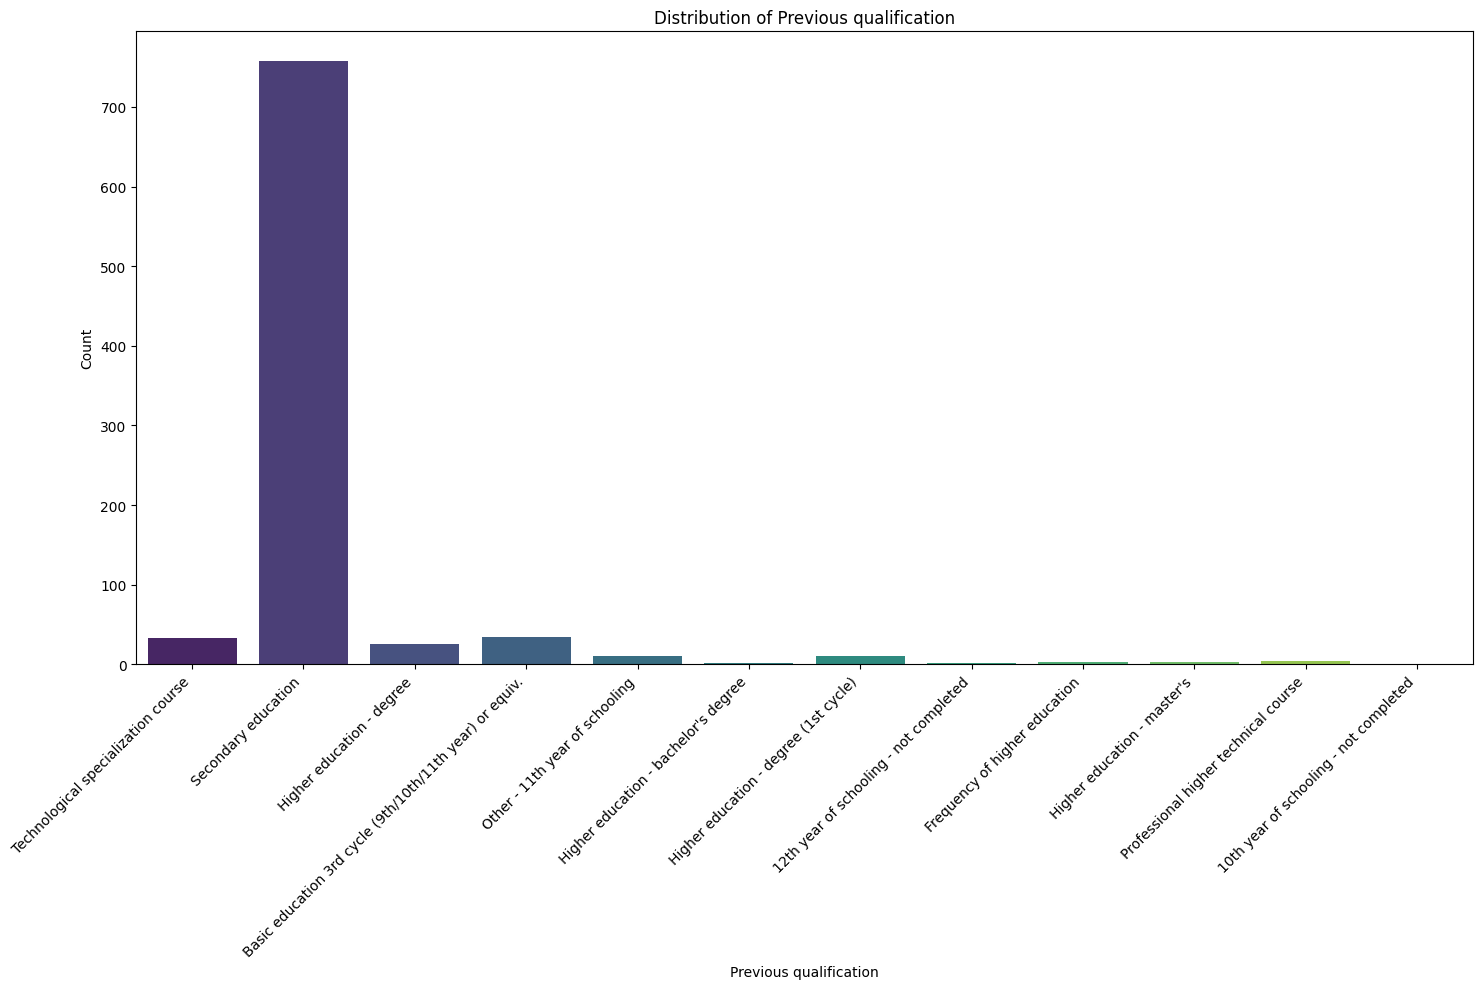

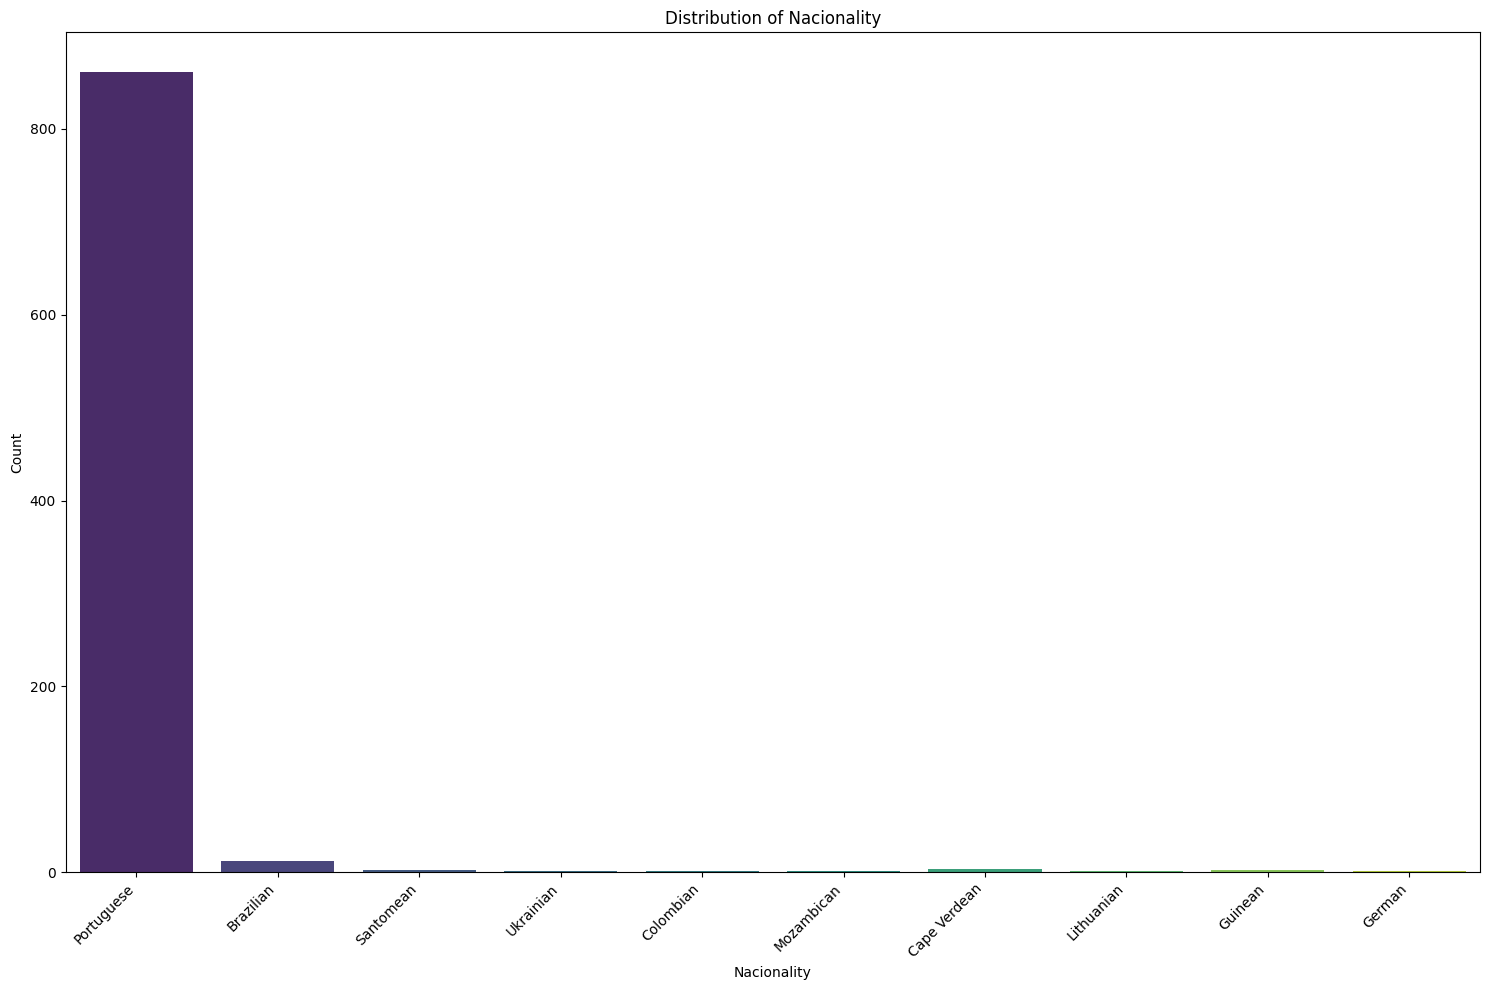

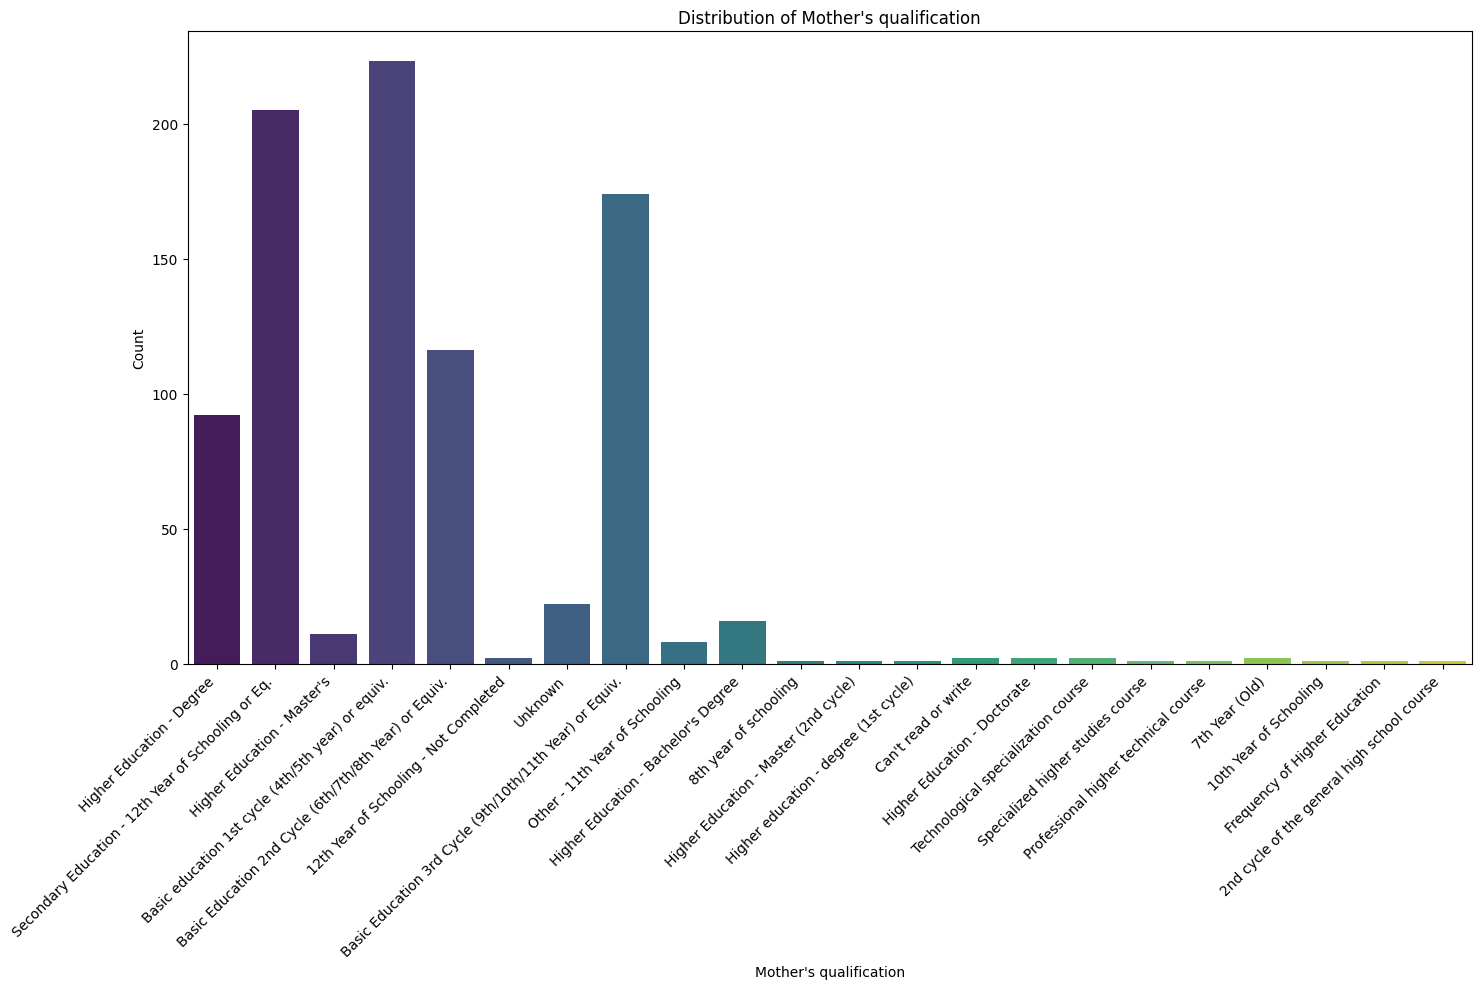

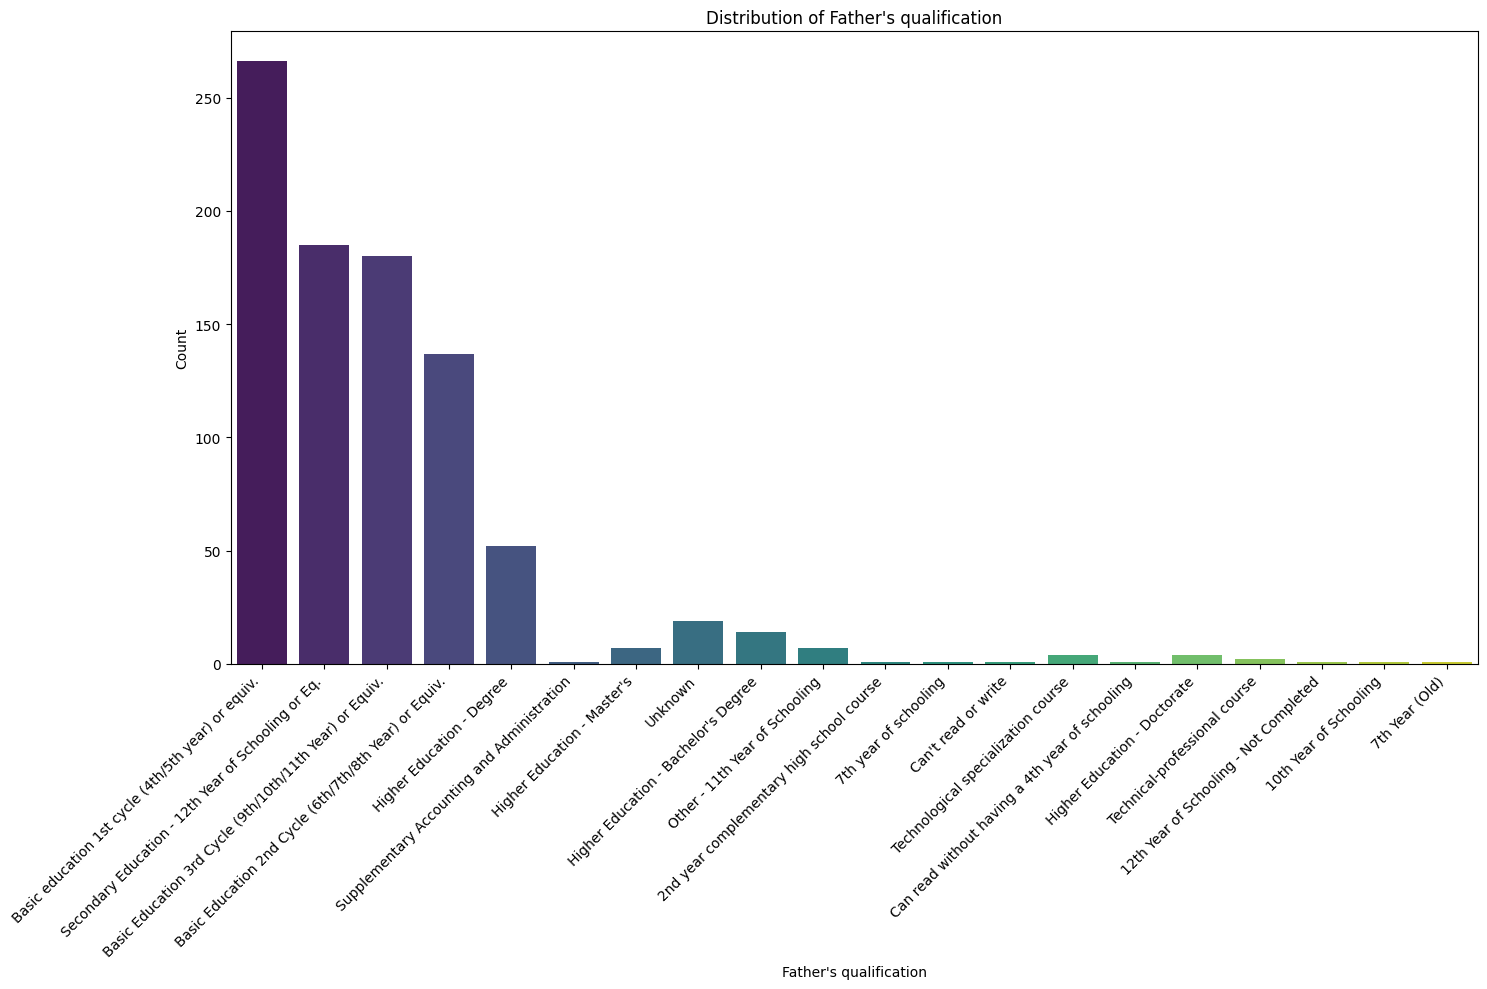

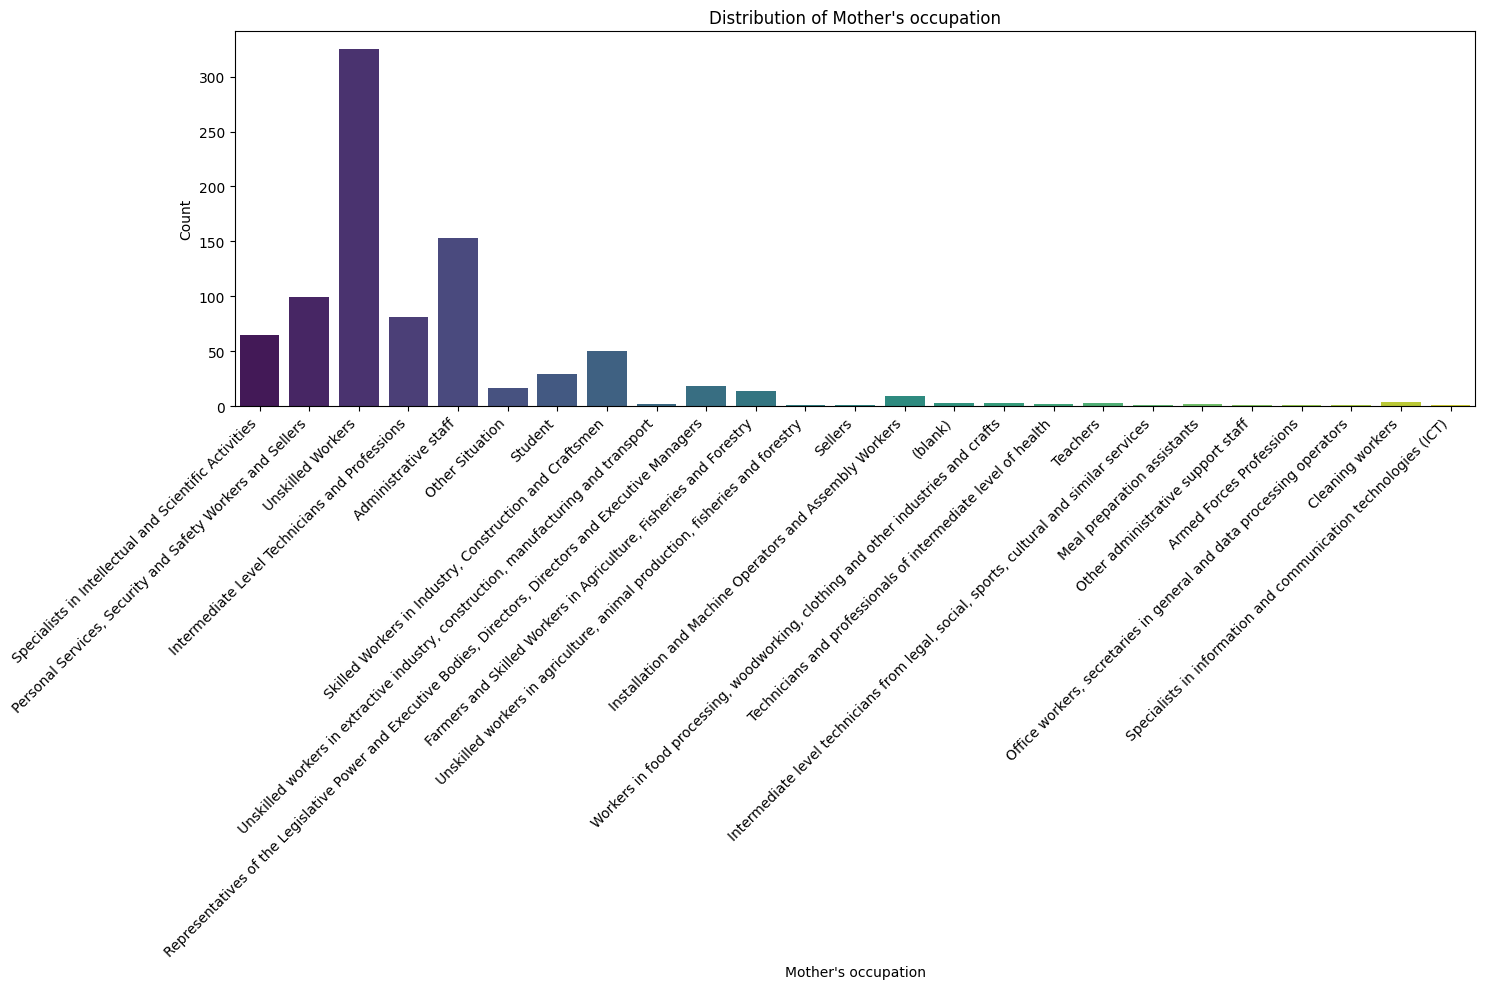

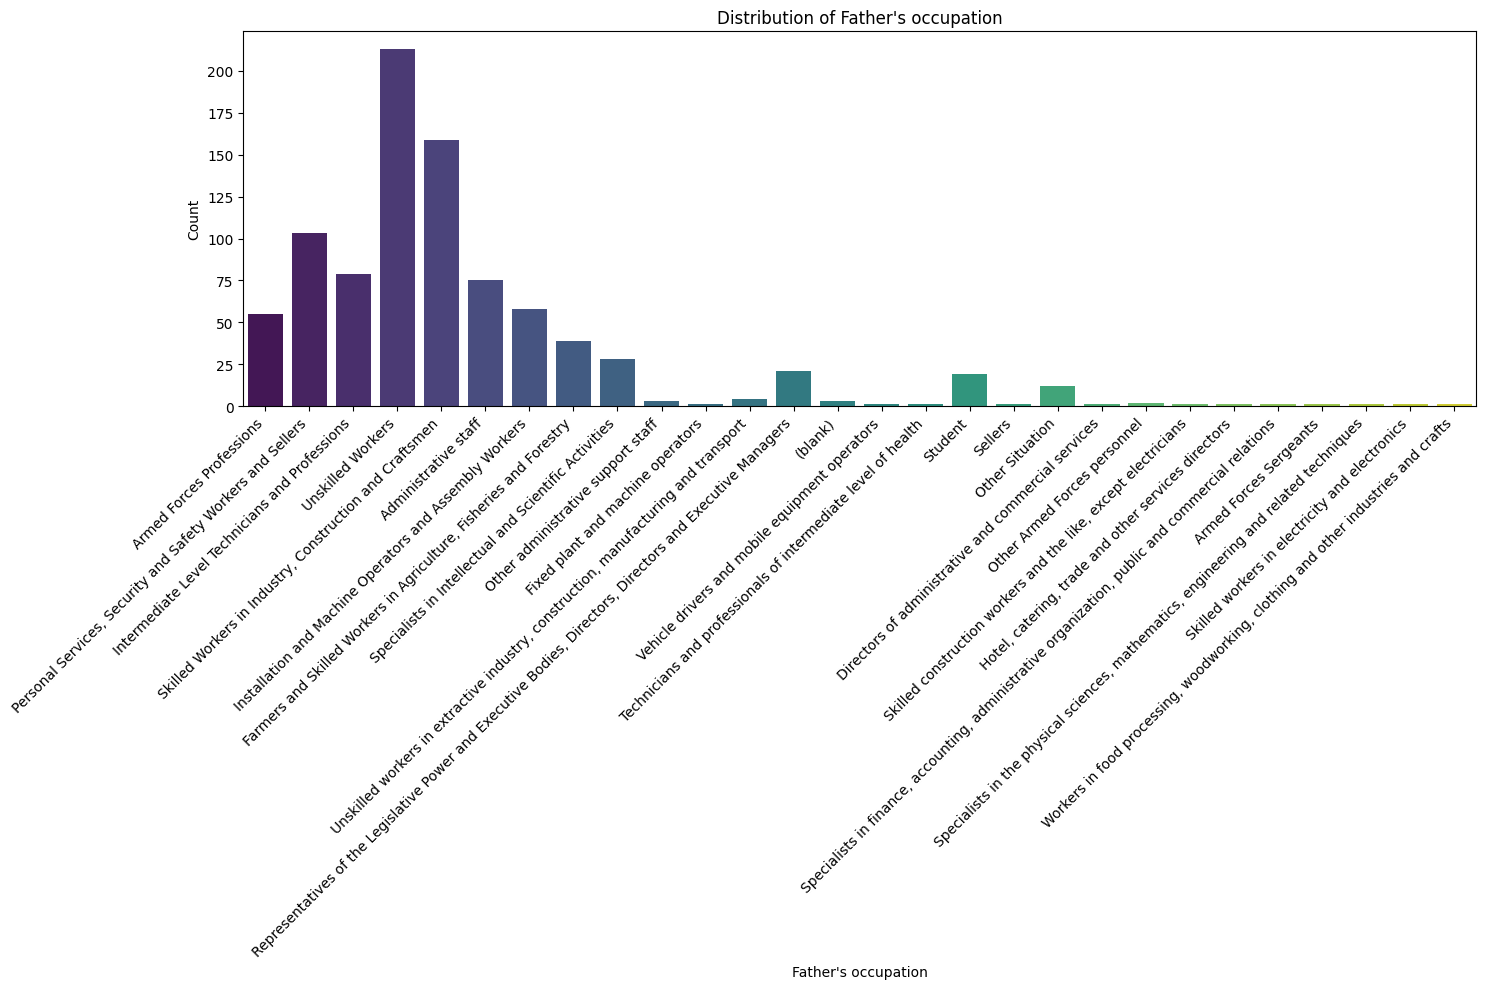

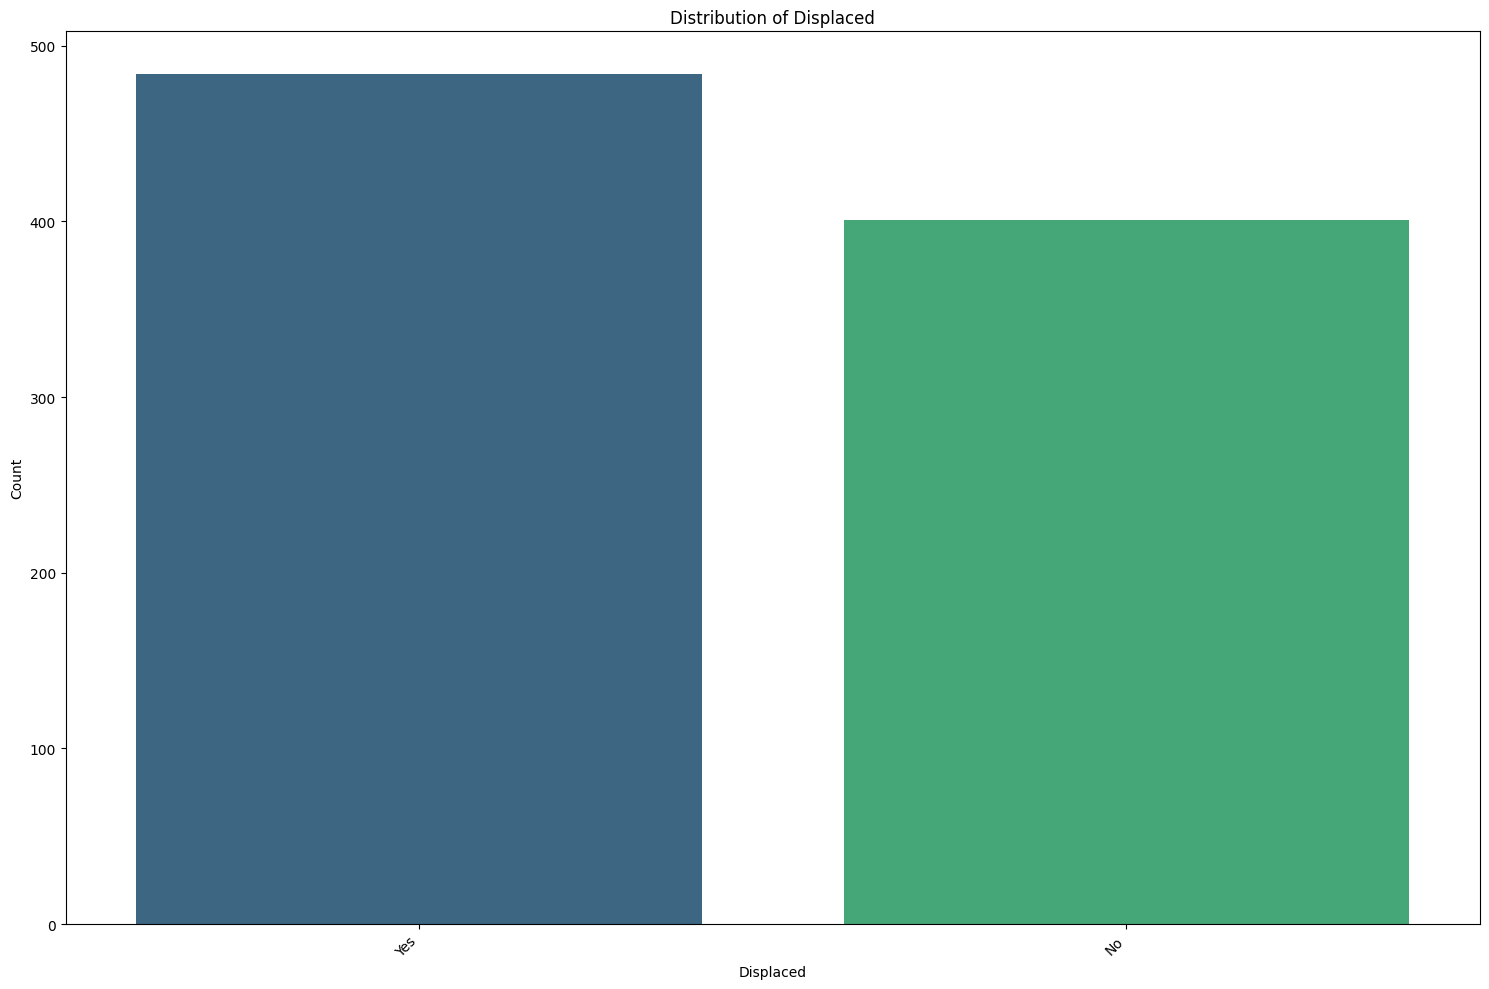

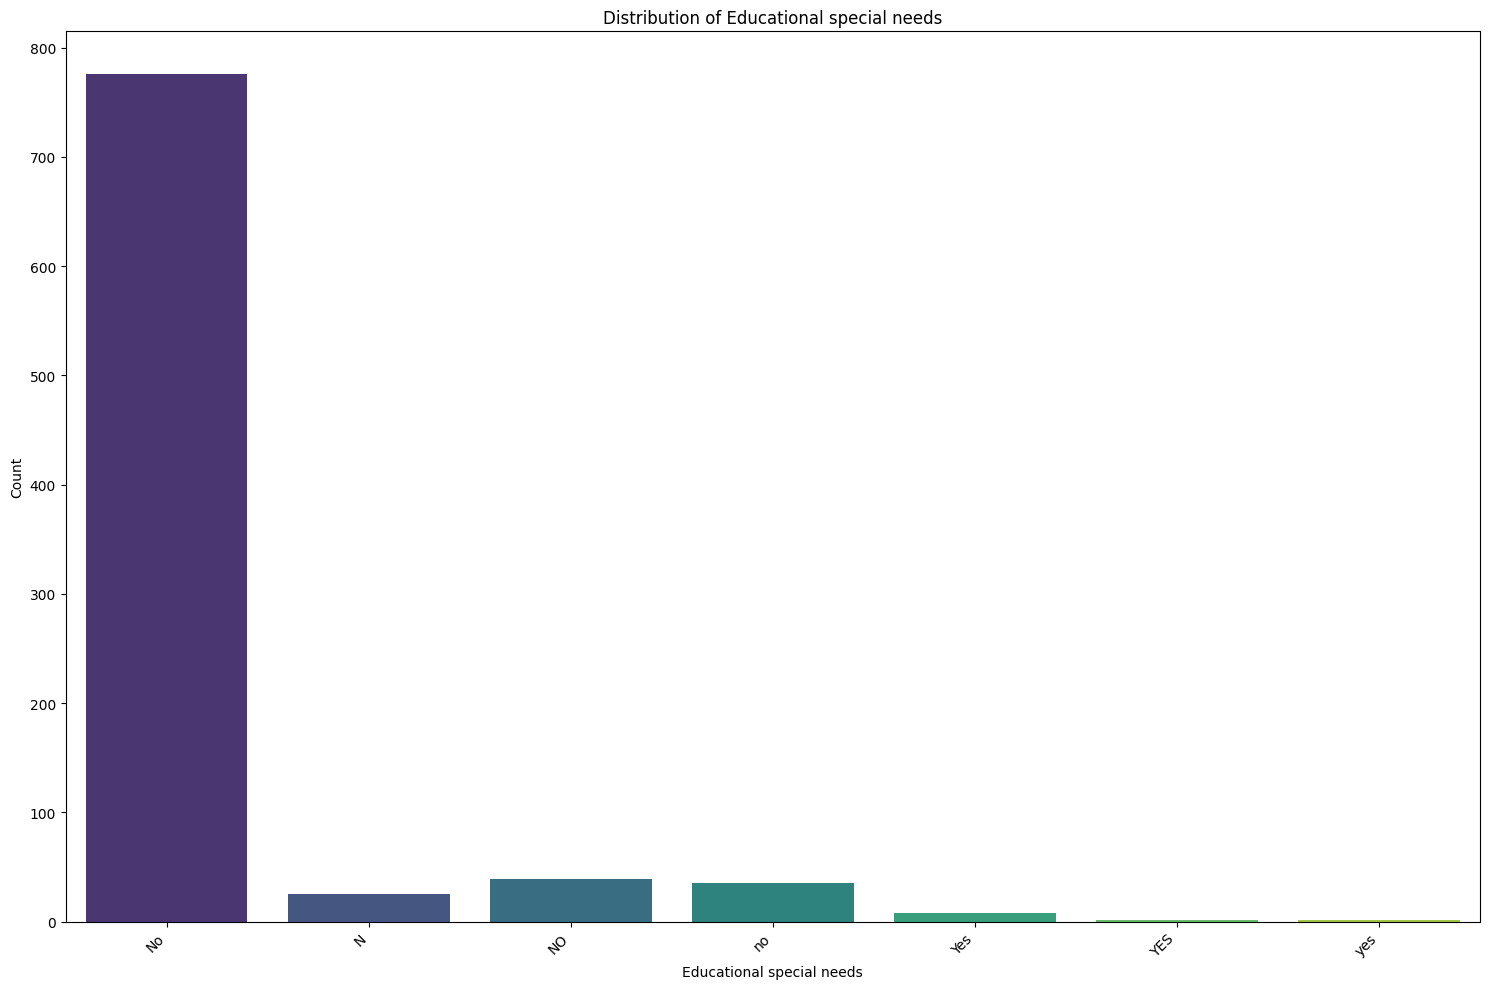

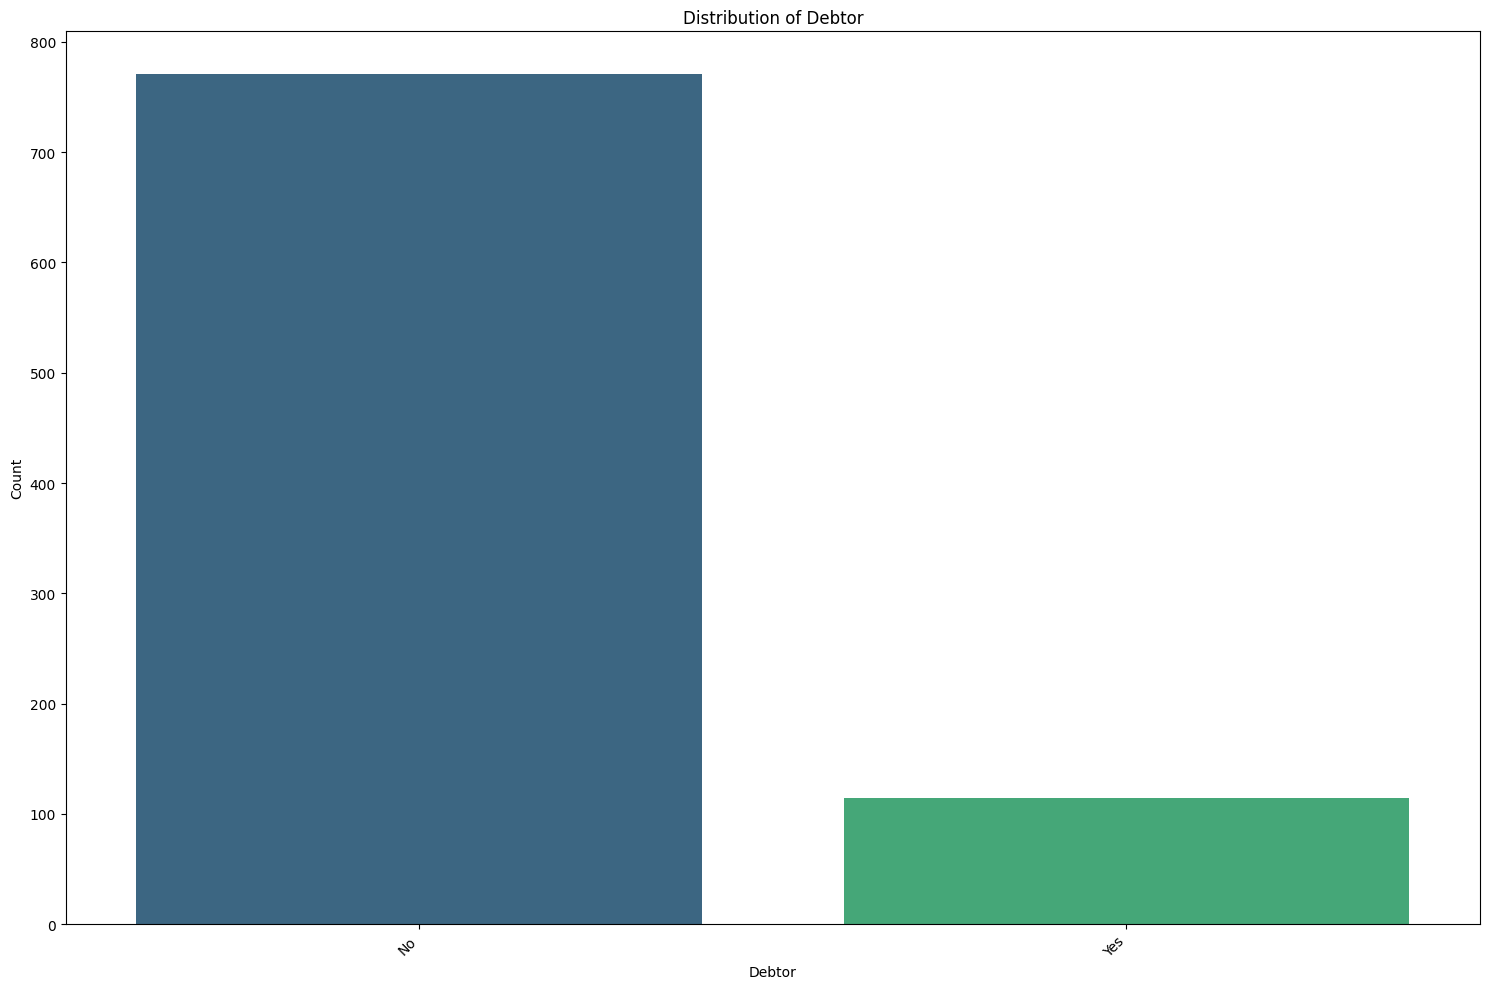

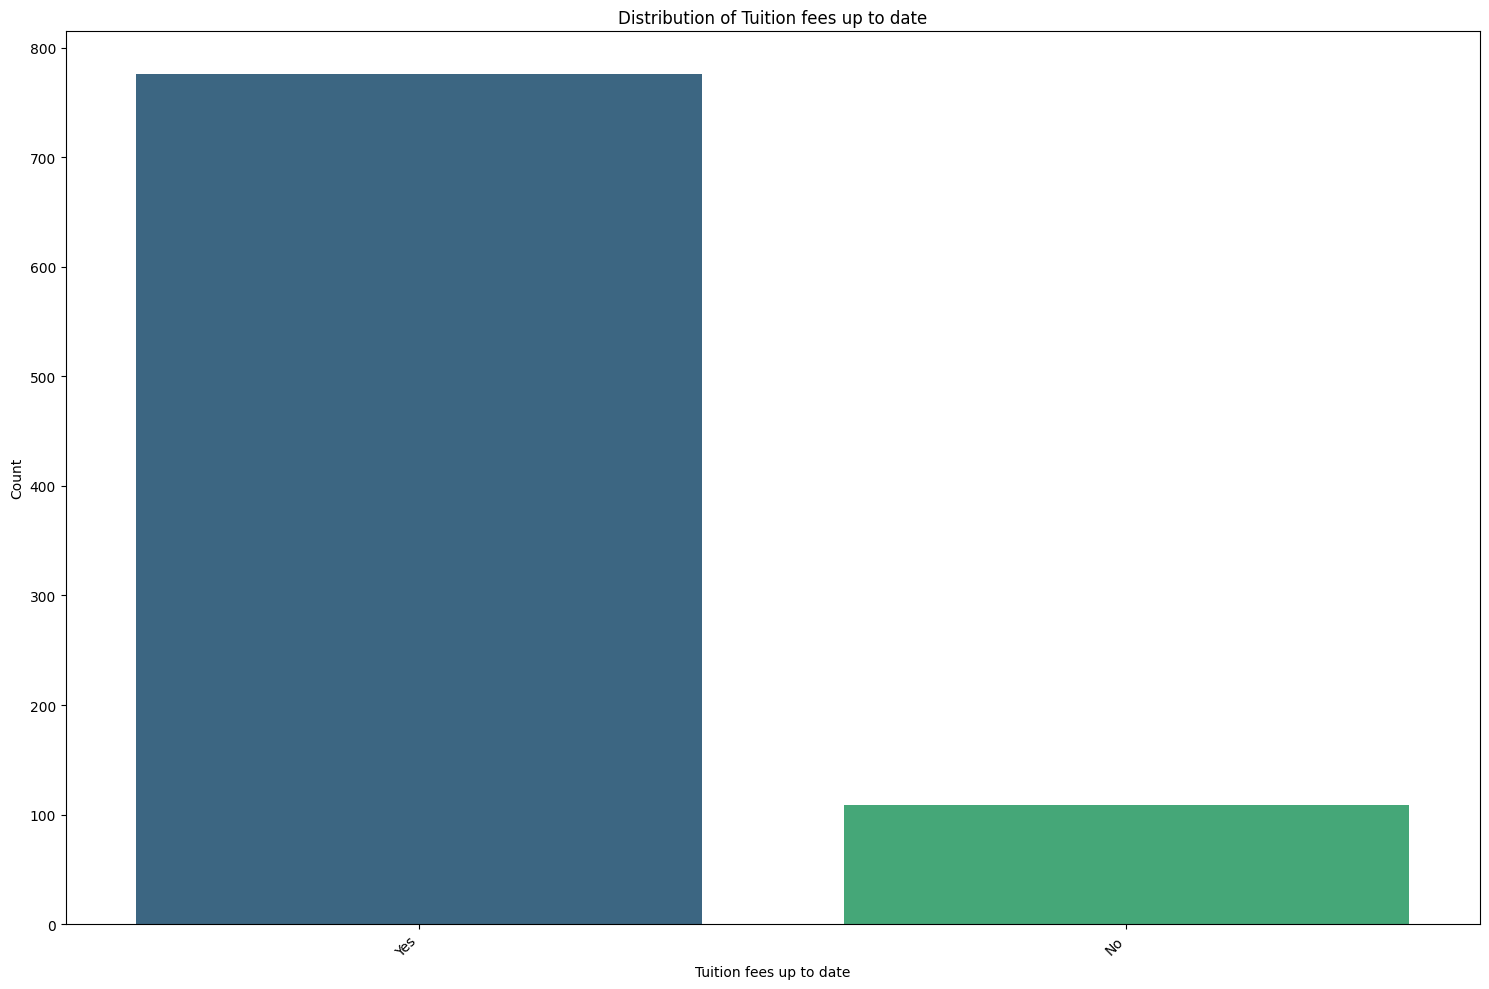

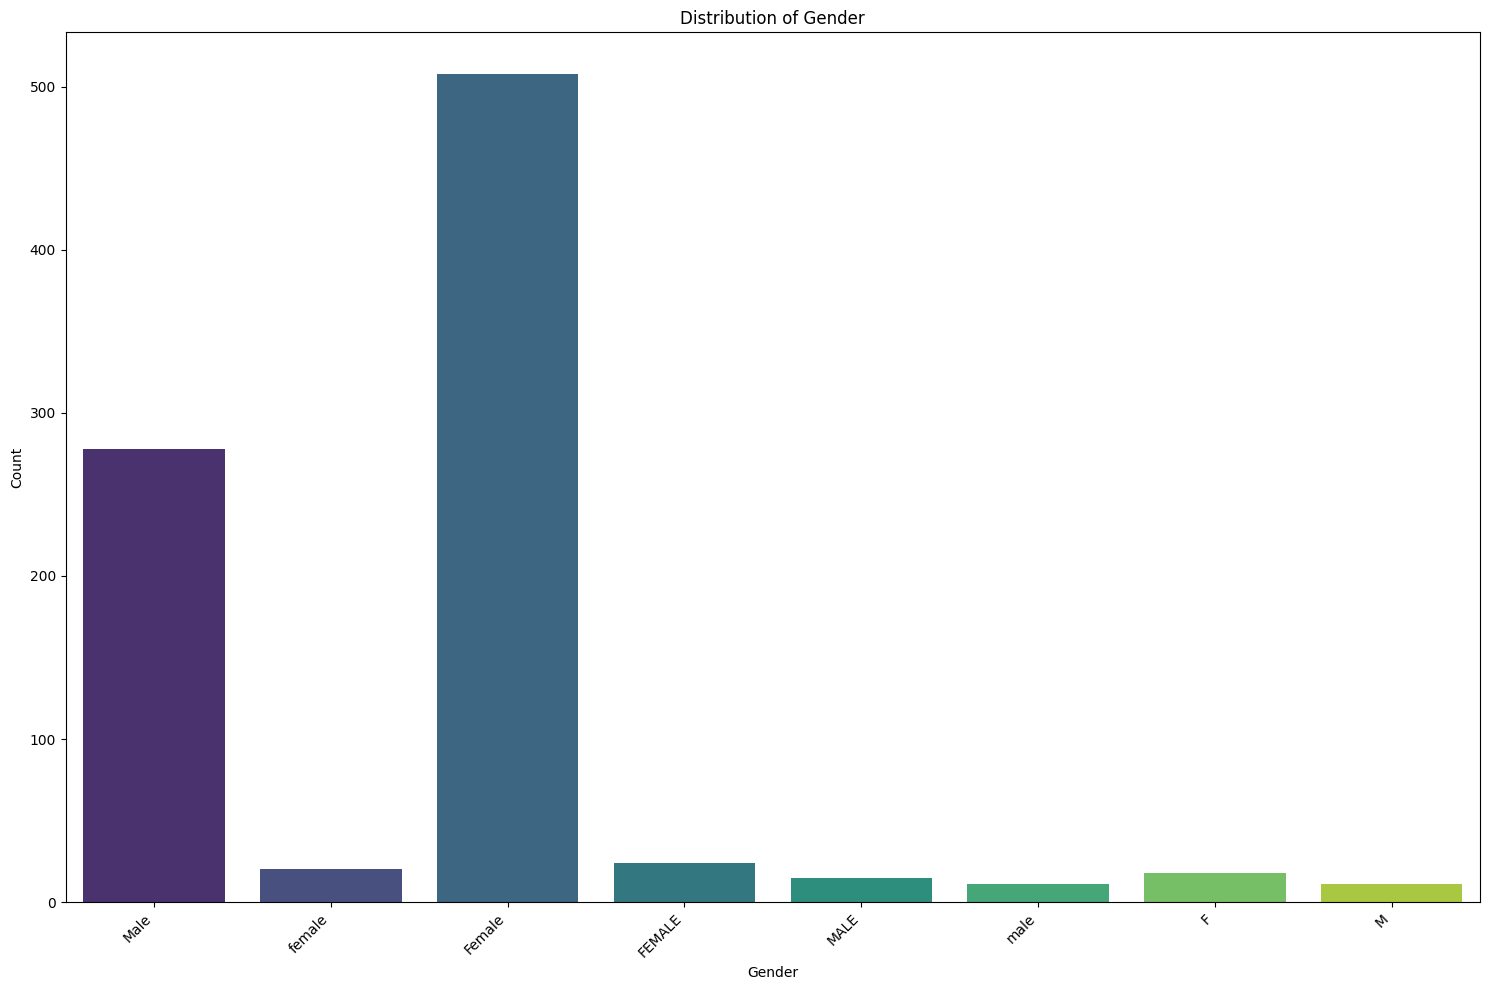

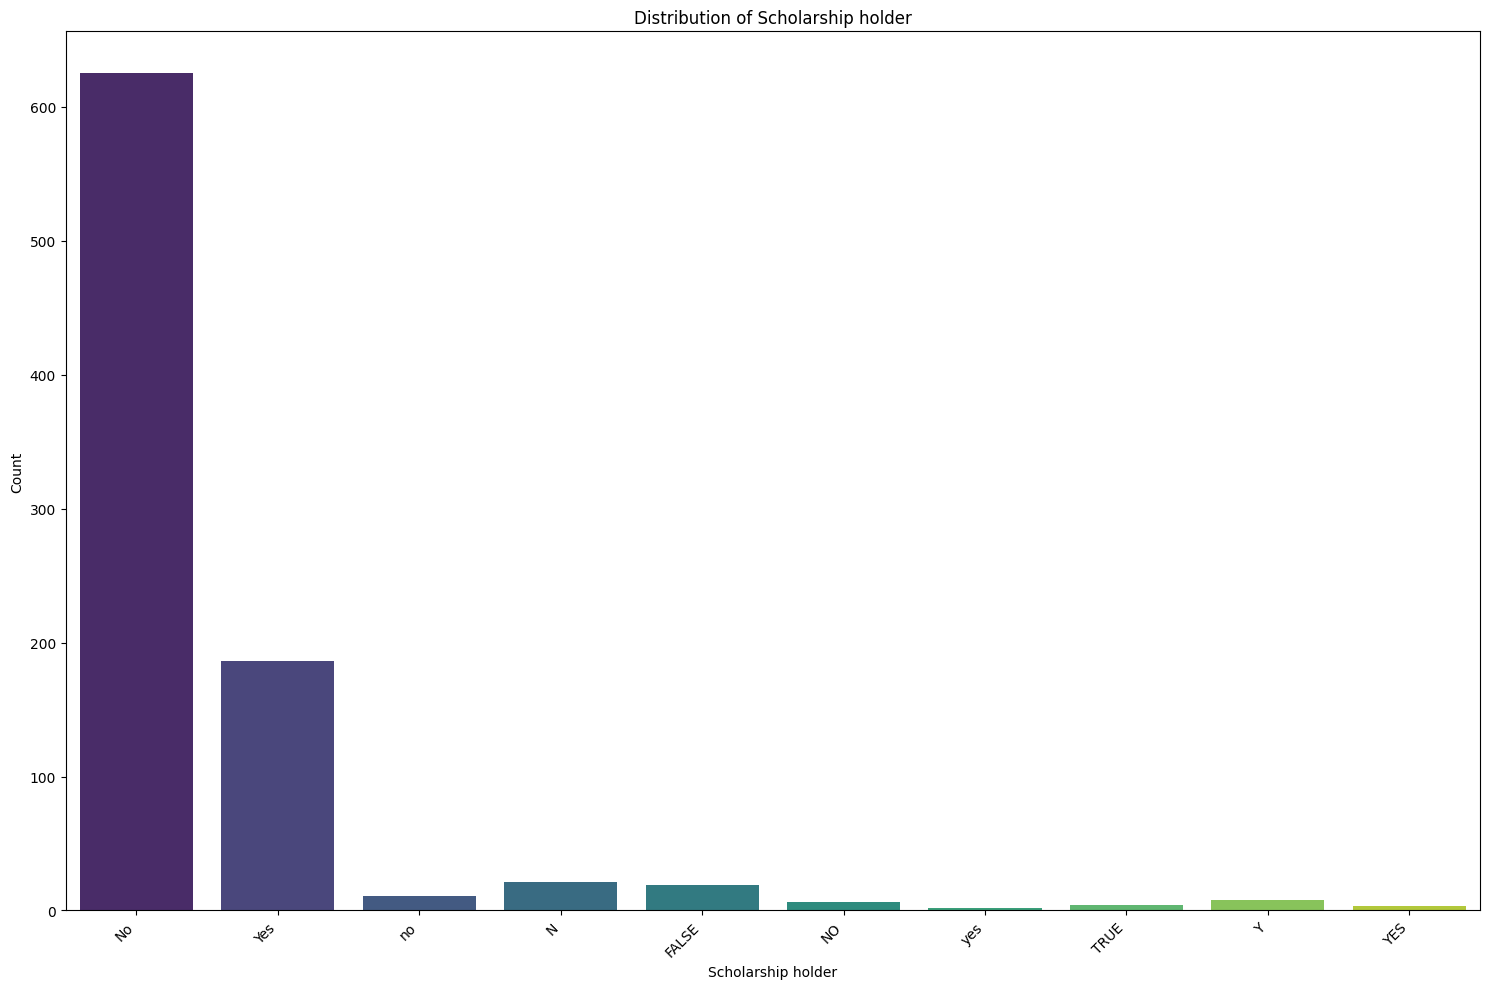

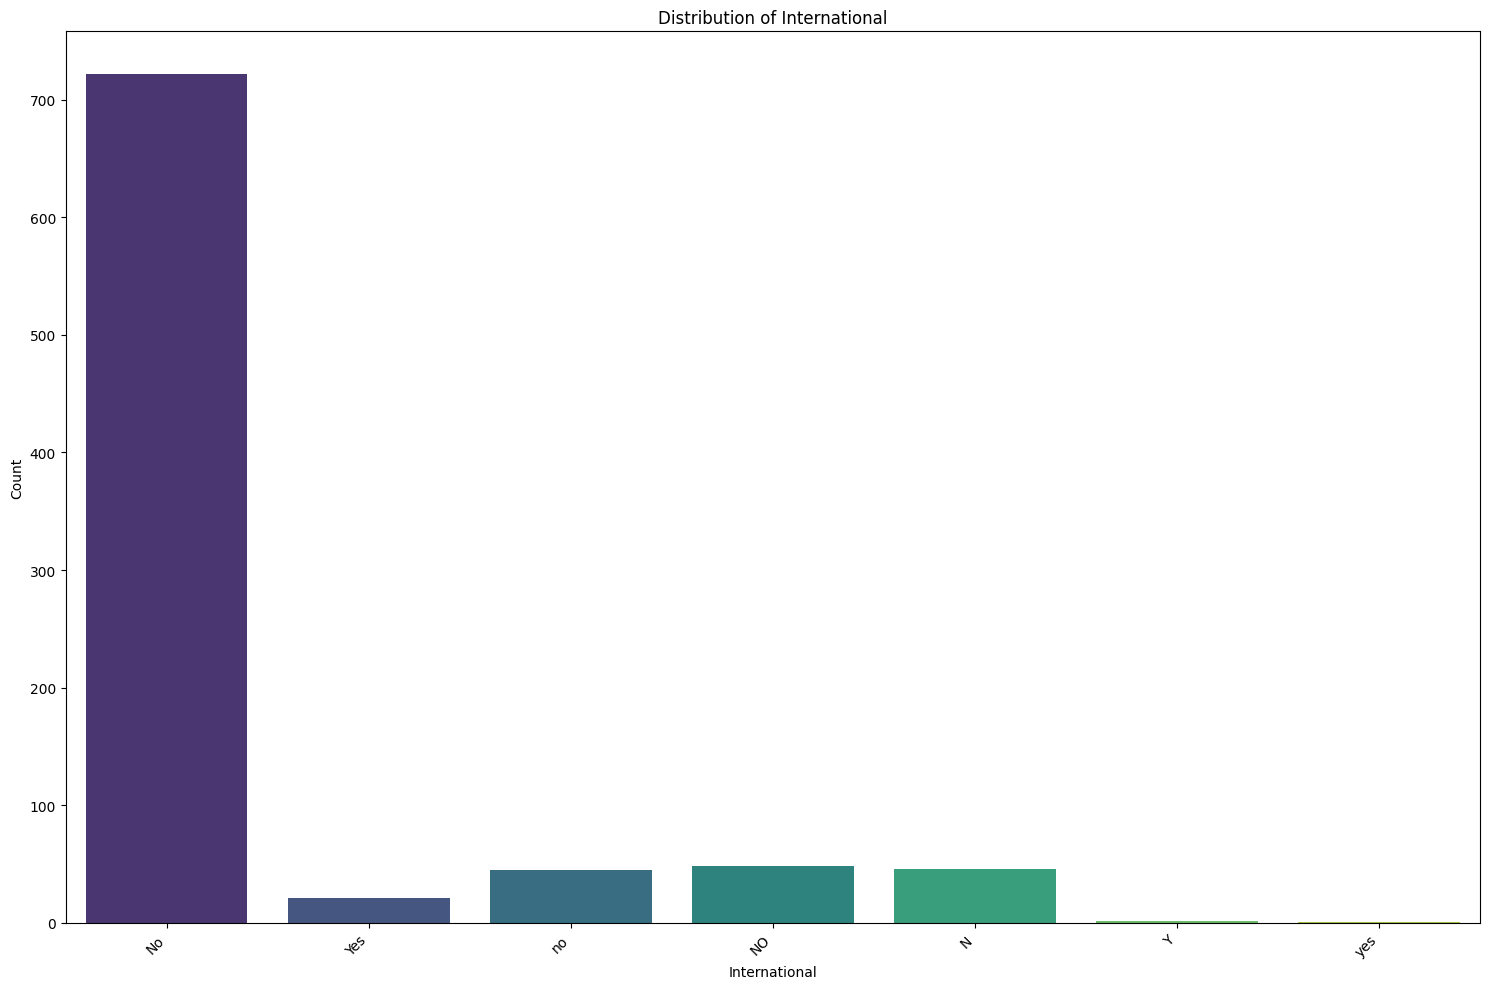

In [443]:
for col in test_cat_cols:
  if col == 'Student_ID' or col == 'Application_ID' or col == 'Registration_Code':
    continue
  plt.figure(figsize=(15, 10))
  sns.countplot(data=df2, x=col, hue=col, palette='viridis', legend=False)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

In [444]:
inc_cols=['Gender', 'International', 'Scholarship holder', 'Educational special needs']
for column in inc_cols:
    df2[column] = df2[column].str.strip() 
    df2[column] = df2[column].str.lower()
    print(df2[column].value_counts())
for column in inc_cols:
    df2[column] = df2[column].replace({"y": "yes"})
    df2[column] = df2[column].replace({"n": "no"})
    df2[column] = df2[column].replace({"true": "yes"})
    df2[column] = df2[column].replace({"false": "no"})
    df2[column] = df2[column].replace({"f": "female"})
    df2[column] = df2[column].replace({"m": "male"})
    print(df2[column].value_counts())

Gender
female    552
male      304
f          18
m          11
Name: count, dtype: int64
International
no     815
n       46
yes     22
y        2
Name: count, dtype: int64
Scholarship holder
no       642
yes      191
n         21
false     19
y          8
true       4
Name: count, dtype: int64
Educational special needs
no     850
n       25
yes     10
Name: count, dtype: int64
Gender
female    570
male      315
Name: count, dtype: int64
International
no     861
yes     24
Name: count, dtype: int64
Scholarship holder
no     682
yes    203
Name: count, dtype: int64
Educational special needs
no     875
yes     10
Name: count, dtype: int64


In [445]:
test_num_cols = df2.select_dtypes(include=['int64', 'float64']).columns
print("NUMERICAL COLUMNS:")
for col in test_num_cols:
    print(col)

NUMERICAL COLUMNS:
Application order
Previous qualification (grade)
Admission grade
Age at enrollment
Curricular units 1st sem (credited)
Curricular units 1st sem (enrolled)
Curricular units 1st sem (evaluations)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (credited)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (evaluations)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP


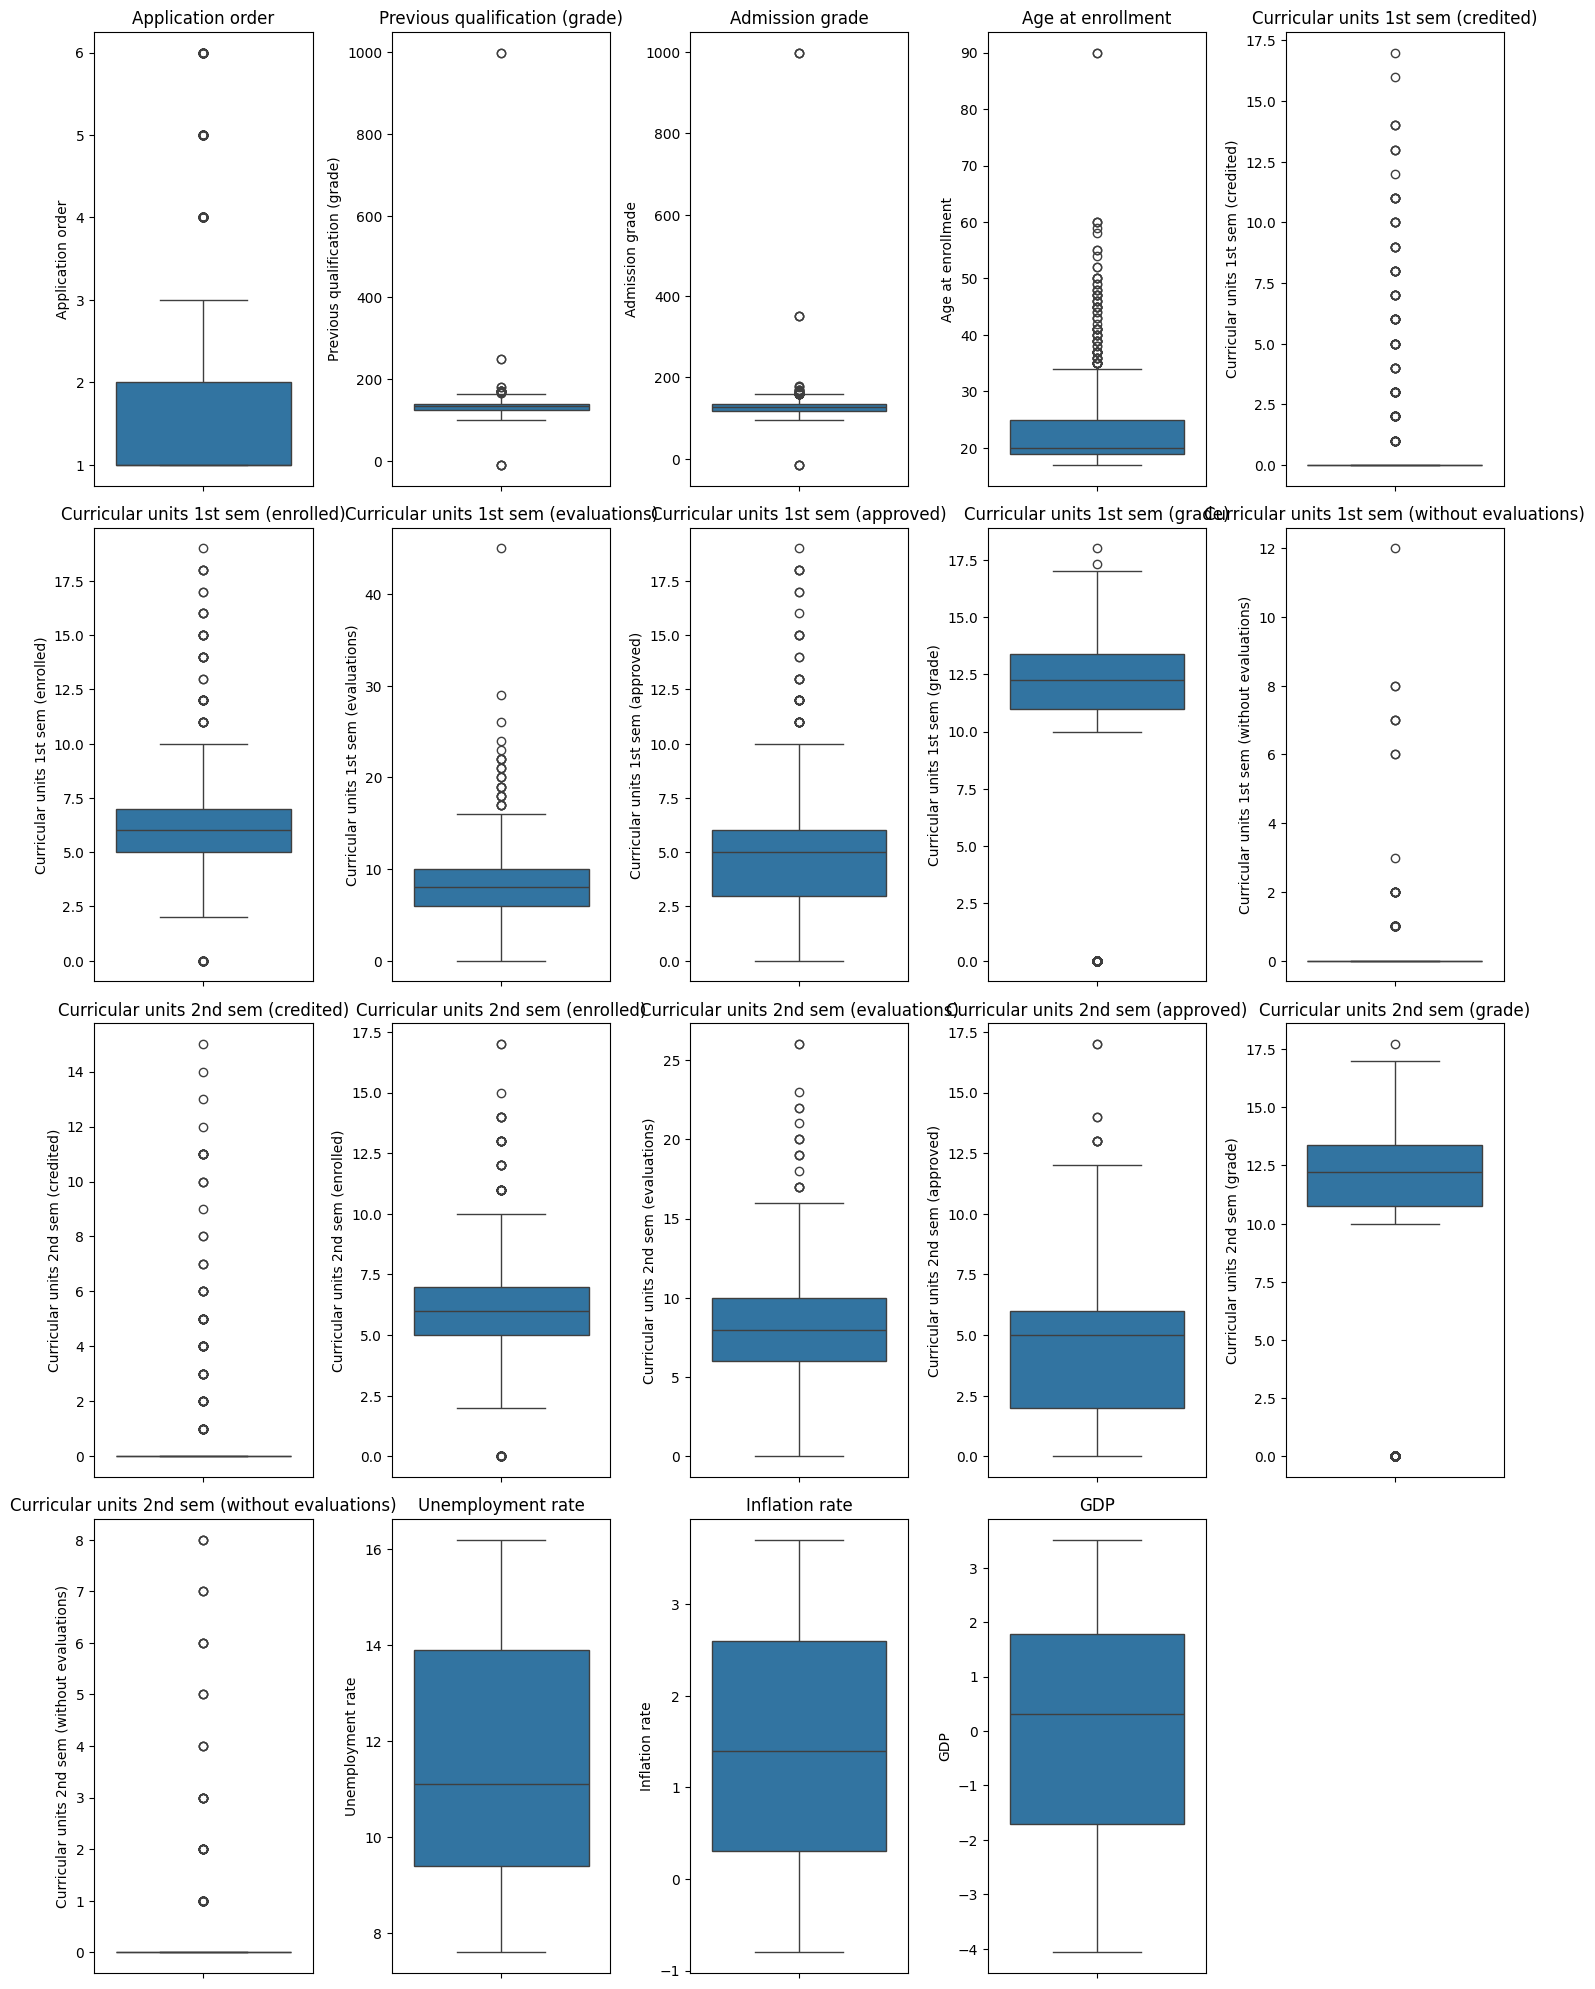

In [446]:
plt.figure(figsize=(15,20))
for i, col in enumerate(test_num_cols, 1):
    plt.subplot(4,5,i)
    sns.boxplot(y=df2[col])
    plt.title(col)
plt.tight_layout()
plt.show()

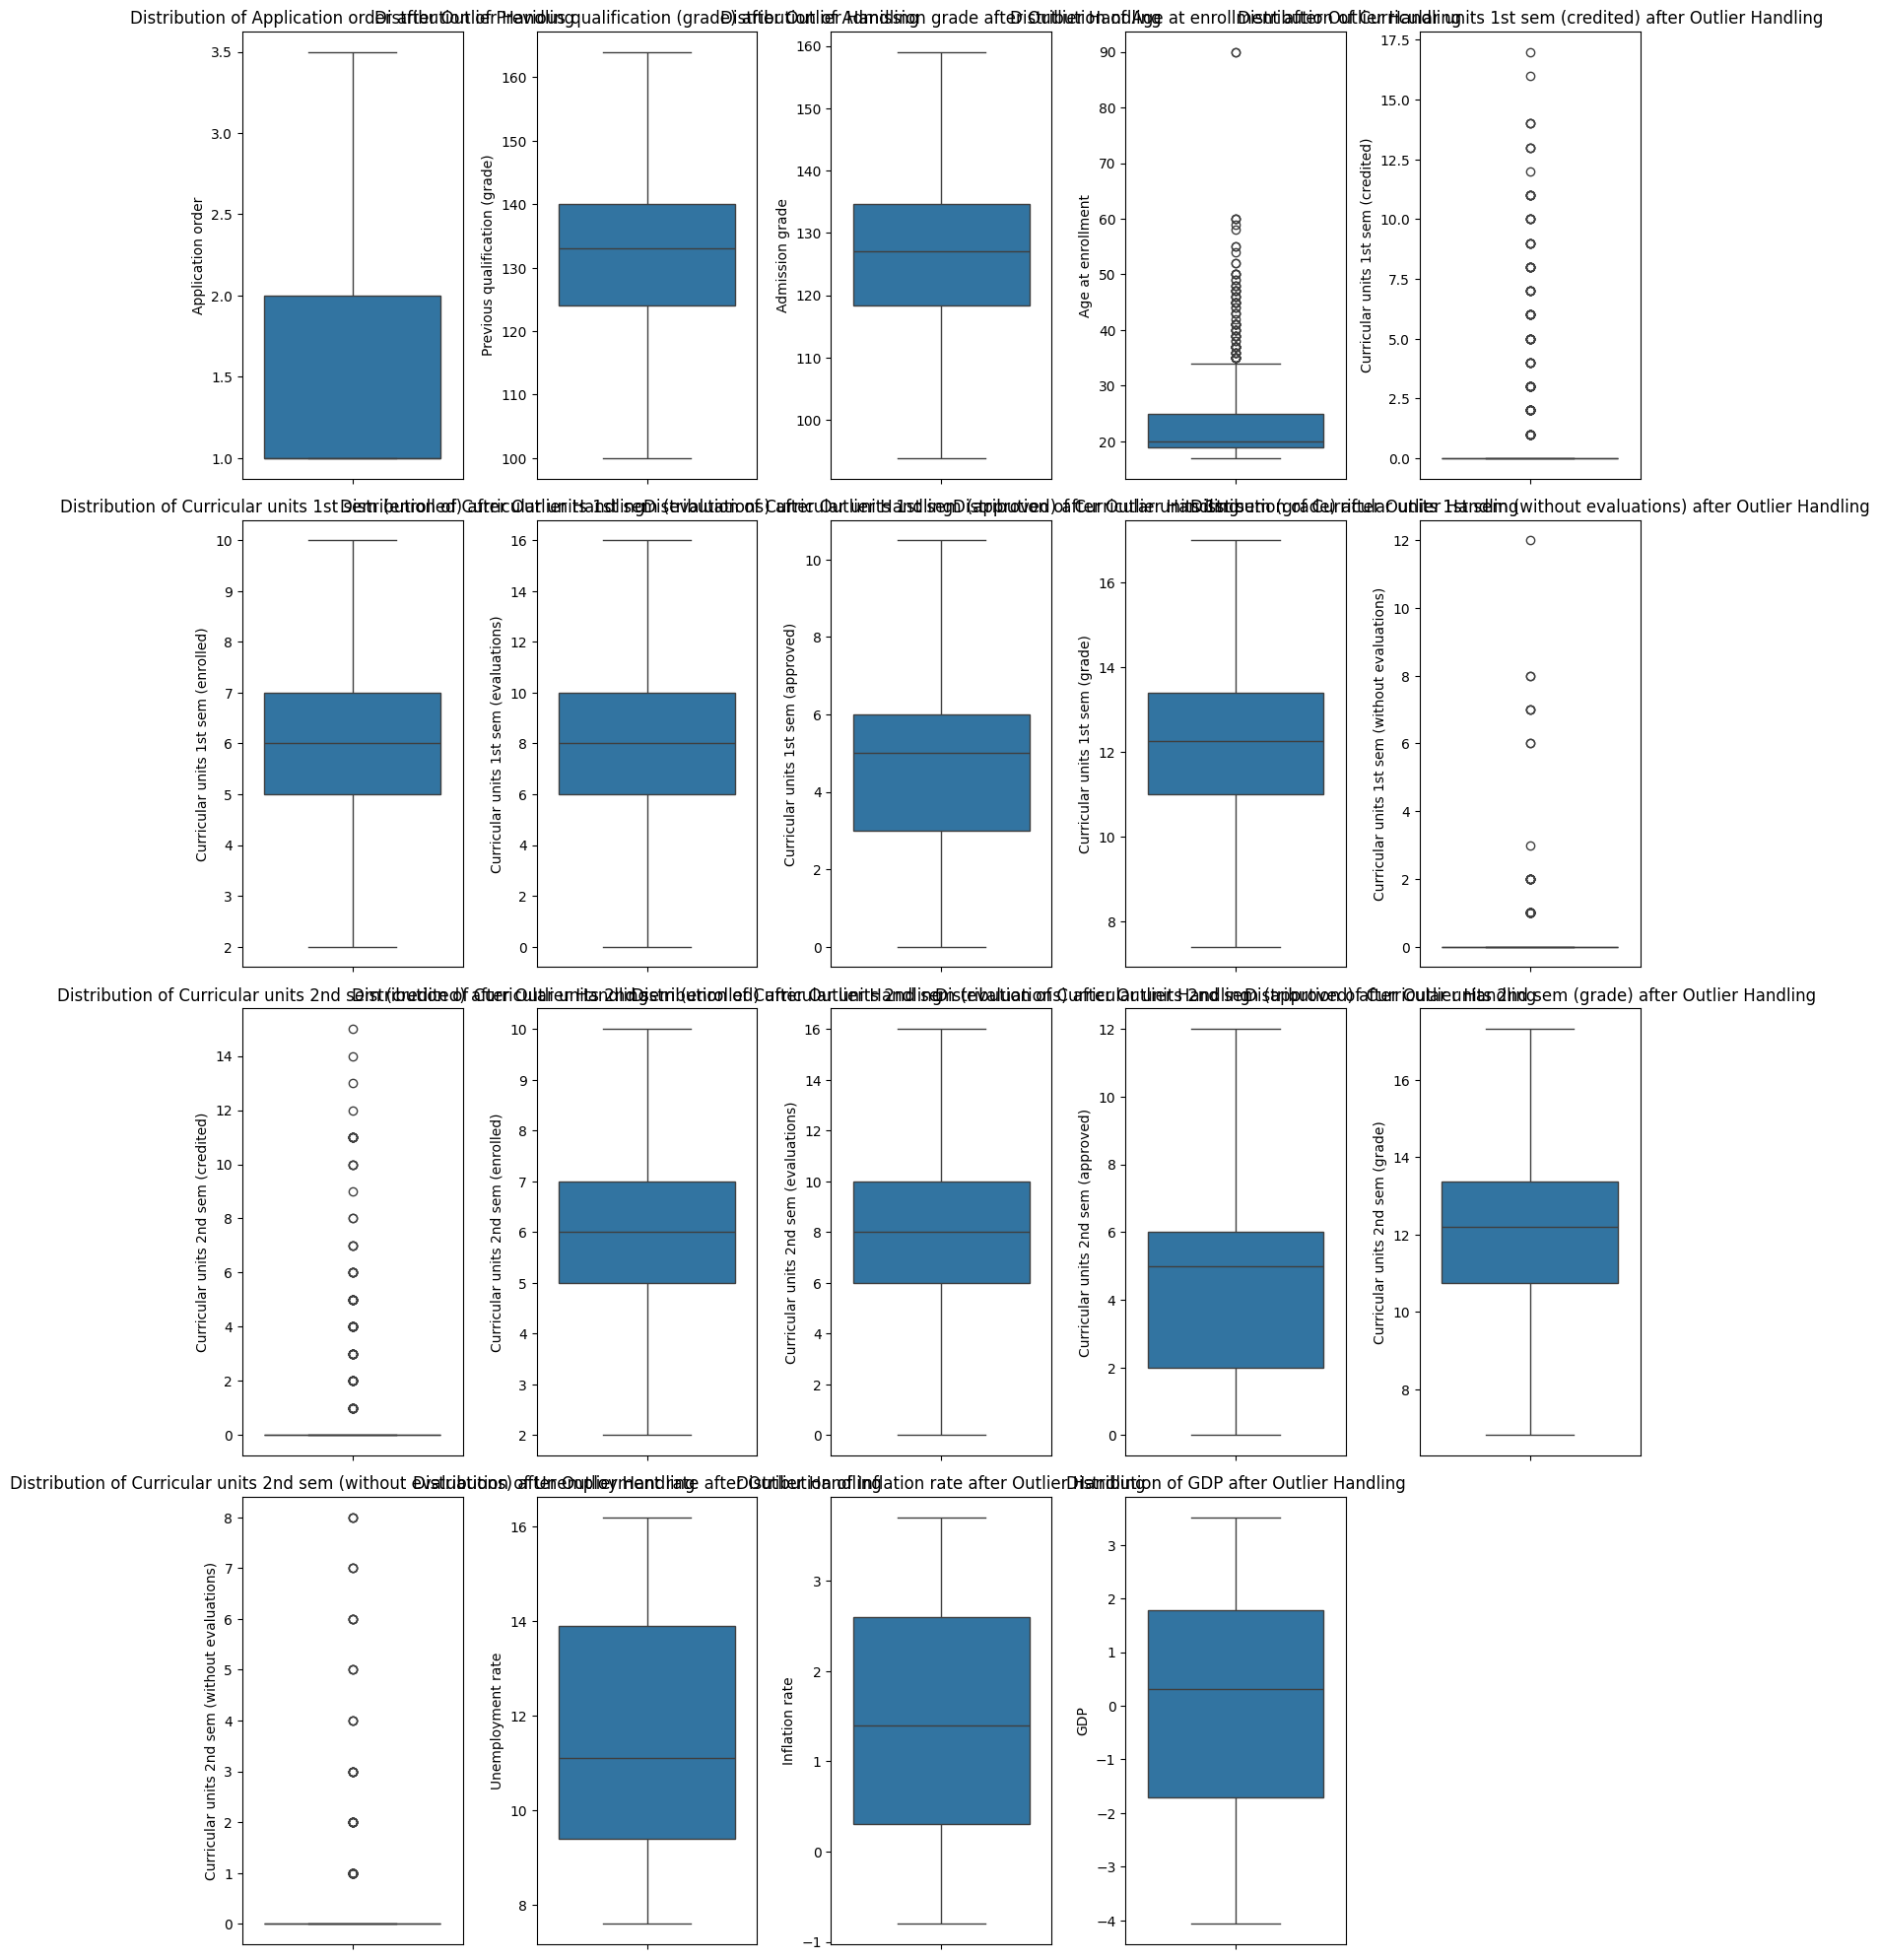

In [447]:
for col in test_num_cols:
  if col == 'Age at enrollment' or col == 'Curricular units 1st sem (credited)' or col == 'Curricular units 2nd sem (credited)' or col == 'Curricular units 1st sem (without evaluations)' or col == 'Curricular units 2nd sem (without evaluations)':
    continue

  Q1 = df2[col].quantile(0.25)
  Q3 = df2[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df2[col] = np.where(df2[col] < lower_bound, lower_bound, df2[col])
  df2[col] = np.where(df2[col] > upper_bound, upper_bound, df2[col])

plt.figure(figsize=(15,20))
for i, col in enumerate(test_num_cols, 1):
    plt.subplot(4,5,i)
    sns.boxplot(y=df2[col])
    plt.title(f'Distribution of {col} after Outlier Handling')
plt.tight_layout()
plt.show()

# Encoding / Scaling

In [448]:
Target_order = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target'] = df['Target'].map(Target_order)

strip_cols=['Scholarship holder', 'International', 'Tuition fees up to date', 'Debtor', 'Educational special needs', 'Displaced', 'Daytime/evening attendance', 'Gender']
for col in strip_cols: 
    df[col] = df[col].str.lower()

df['Gender'] = df['Gender'].map({'female': 1, 'male': 0})
df['Daytime/evening attendance'] = df['Daytime/evening attendance'].map({'daytime': 1, 'evening': 0})

df['Displaced'] = df['Displaced'].map({'yes': 1, 'no': 0})
df['Educational special needs'] = df['Educational special needs'].map({'yes': 1, 'no': 0})
df['Debtor'] = df['Debtor'].map({'yes': 1, 'no': 0})
df['Tuition fees up to date'] = df['Tuition fees up to date'].map({'yes': 1, 'no': 0})
df['International'] = df['International'].map({'yes': 1, 'no': 0})
df['Scholarship holder'] = df['Scholarship holder'].map({'yes': 1, 'no': 0})

for col in strip_cols:
    print(df[col].isnull().sum())

0
0
0
0
0
0
0
0


In [449]:
cat_cols2 = df.select_dtypes(include='object').columns
print(cat_cols2)
cat_cols2=cat_cols2.drop('Student_ID')
cat_cols2=cat_cols2.drop('Application_ID')
cat_cols2=cat_cols2.drop('Registration_Code')

df_encoded = pd.get_dummies(df, columns=cat_cols2, drop_first=True)
df_encoded.shape

Index(['Student_ID', 'Application_ID', 'Registration_Code', 'Marital status',
       'Application mode', 'Course', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation'],
      dtype='object')


(3572, 237)

In [450]:
df_encoded.info

<bound method DataFrame.info of        Student_ID Application_ID Registration_Code  Application order  \
0     ST202603036     APP1000803         REG-ABSM2                1.0   
1     ST202602902     APP1002222         REG-ZEDE1                1.0   
2     ST202602203     APP1000088         REG-GN22Y                1.0   
3     ST202604064     APP1001900         REG-R3Z1D                1.0   
4     ST202602100     APP1000866         REG-WEY9J                1.0   
...           ...            ...               ...                ...   
3685  ST202602238     APP1001130         REG-XPVS9                1.0   
3686  ST202604176     APP1000089         REG-DL624                2.0   
3687  ST202603340     APP1003206         REG-GD25O                1.0   
3688  ST202600254     APP1003868         REG-W935A                1.0   
3689  ST202601615     APP1003502         REG-W3J2D                1.0   

      Daytime/evening attendance  Previous qualification (grade)  \
0                      

In [451]:
test_strip_cols=['Scholarship holder', 'International', 'Tuition fees up to date', 'Debtor', 'Educational special needs', 'Displaced', 'Daytime/evening attendance', 'Gender']
for col in test_strip_cols: 
    df2[col] = df2[col].str.lower()

df2['Gender'] = df2['Gender'].map({'female': 1, 'male': 0})
df2['Daytime/evening attendance'] = df2['Daytime/evening attendance'].map({'daytime': 1, 'evening': 0})

df2['Displaced'] = df2['Displaced'].map({'yes': 1, 'no': 0})
df2['Educational special needs'] = df2['Educational special needs'].map({'yes': 1, 'no': 0})
df2['Debtor'] = df2['Debtor'].map({'yes': 1, 'no': 0})
df2['Tuition fees up to date'] = df2['Tuition fees up to date'].map({'yes': 1, 'no': 0})
df2['International'] = df2['International'].map({'yes': 1, 'no': 0})
df2['Scholarship holder'] = df2['Scholarship holder'].map({'yes': 1, 'no': 0})

for col in test_strip_cols:
    print(df2[col].isnull().sum())

0
0
0
0
0
0
0
0


In [452]:
test_cat_cols2 = df2.select_dtypes(include='object').columns
print(test_cat_cols2)
test_cat_cols2=test_cat_cols2.drop('Student_ID')
test_cat_cols2=test_cat_cols2.drop('Application_ID')
test_cat_cols2=test_cat_cols2.drop('Registration_Code')

df2_encoded = pd.get_dummies(df2, columns=test_cat_cols2, drop_first=True)
df2_encoded.shape

Index(['Student_ID', 'Application_ID', 'Registration_Code', 'Marital status',
       'Application mode', 'Course', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation'],
      dtype='object')


(885, 180)

In [453]:
train_cols = set(df_encoded.columns)
test_cols = set(df2_encoded.columns)

missing_in_test = train_cols - test_cols
print(missing_in_test)

missing_in_train = test_cols - train_cols
print(missing_in_train)

{'Nacionality_Italian', 'Application mode_Change of institution/course (International)', "Mother's qualification_11th Year of Schooling - Not Completed", "Father's qualification_Higher education - degree (1st cycle)", "Mother's occupation_Personal service workers", "Father's occupation_Skilled workers in metallurgy, metalworking and similar", "Father's qualification_Higher Education - Master (2nd cycle)", "Mother's qualification_Technical-professional course", "Father's qualification_General commerce course", "Father's occupation_Health professionals", "Mother's qualification_9th Year of Schooling - Not Completed", 'Nacionality_Russian', "Mother's qualification_Can read without having a 4th year of schooling", "Father's qualification_Complementary High School Course - not concluded", 'Nacionality_Mexican', "Father's qualification_2nd cycle of the general high school course", 'Application mode_Ordinance No. 854-B/99', "Mother's occupation_Skilled workers in printing, precision instrumen

In [454]:
if missing_in_test:
    print(f"Test data is missing: {missing_in_test}")
    for col in missing_in_test:
        df2_encoded[col] = 0



if missing_in_train:
    print(f"Train data is missing: {missing_in_train}")
    for col in missing_in_train:
        df_encoded[col] = 0


Test data is missing: {'Nacionality_Italian', 'Application mode_Change of institution/course (International)', "Mother's qualification_11th Year of Schooling - Not Completed", "Father's qualification_Higher education - degree (1st cycle)", "Mother's occupation_Personal service workers", "Father's occupation_Skilled workers in metallurgy, metalworking and similar", "Father's qualification_Higher Education - Master (2nd cycle)", "Mother's qualification_Technical-professional course", "Father's qualification_General commerce course", "Father's occupation_Health professionals", "Mother's qualification_9th Year of Schooling - Not Completed", 'Nacionality_Russian', "Mother's qualification_Can read without having a 4th year of schooling", "Father's qualification_Complementary High School Course - not concluded", 'Nacionality_Mexican', "Father's qualification_2nd cycle of the general high school course", 'Application mode_Ordinance No. 854-B/99', "Mother's occupation_Skilled workers in printin

In [455]:
df2_encoded = df2_encoded[df_encoded.columns]

assert list(df_encoded.columns) == list(df2_encoded.columns), "Columns don't match"

In [456]:
print(df_encoded.shape)
print(df2_encoded.shape)

(3572, 248)
(885, 248)


In [457]:
X_train = df_encoded.drop(columns=['Registration_Code', 'Application_ID', 'Student_ID', 'Target'])
y_train = df_encoded['Target']

In [458]:
X_test=df2_encoded.drop(columns=['Registration_Code', 'Application_ID', 'Student_ID','Target'])

In [459]:
print('x_Train shape:', X_train.shape)
print('y_Train shape:', y_train.shape)
print('x_Test shape:', X_test.shape)


x_Train shape: (3572, 244)
y_Train shape: (3572,)
x_Test shape: (885, 244)


In [460]:
print('X_Test columns:')
print(X_test.columns)
print('X_Train columns:')
print(X_train.columns)


X_Test columns:
Index(['Application order', 'Daytime/evening attendance',
       'Previous qualification (grade)', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder',
       ...
       'Father's occupation_Hotel, catering, trade and other services directors',
       'Father's occupation_Skilled workers in electricity and electronics',
       'Mother's qualification_2nd cycle of the general high school course',
       'Father's occupation_Specialists in finance, accounting, administrative organization, public and commercial relations',
       'Father's occupation_Specialists in the physical sciences, mathematics, engineering and related techniques',
       'Nacionality_Lithuanian', 'Nacionality_Colombian',
       'Father's qualification_2nd year complementary high school course',
       'Father's occupation_Technicians and professionals of intermediate level of health',
       'Mother's occupatio

In [461]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [462]:
from imblearn.over_sampling import RandomOverSampler, SMOTE 
from imblearn.under_sampling import RandomUnderSampler 

ros = RandomOverSampler(random_state=42) 
X_resampled, y_resampled = ros.fit_resample(X_train_scaled, y_train) 
smote = SMOTE(random_state=42) 
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

In [463]:
from sklearn.decomposition import PCA 
pca = PCA(n_components=2) 
X_train_pca = pca.fit_transform(X_train_scaled) 
X_test_pca = pca.transform(X_test_scaled) 
pca.explained_variance_ratio_

array([0.02759129, 0.02312896])

In [464]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                              recall_score, f1_score, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.ensemble import AdaBoostClassifier

In [465]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
dtree = DecisionTreeClassifier(max_depth=6, random_state=42)
random_forest = RandomForestClassifier(n_estimators=200, random_state=42)
adaboost = AdaBoostClassifier(n_estimators=200, random_state=42)

In [466]:
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

dtree.fit(X_train_scaled, y_train)
y_pred_dt = dtree.predict(X_test_scaled)

random_forest.fit(X_train_scaled, y_train)
y_pred_rf = random_forest.predict(X_test_scaled)

adaboost.fit(X_train_scaled, y_train)
y_pred_ada = adaboost.predict(X_test_scaled)

In [467]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [468]:
!pip install keras-tuner -q
import keras_tuner as kt

def build_model_for_tuning(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units_1', min_value=64, max_value=256, step=32),
                    activation='relu',
                    input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(units=hp.Int('units_2', min_value=32, max_value=128, step=32),
                    activation='relu'))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [469]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


tuner_gs = kt.GridSearch(
    build_model_for_tuning,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='spaceship_titanic_dnn_grid_search',
    overwrite=True
)

print("Starting Grid Search...")
tuner_gs.search(X_train_scaled, y_train,
                epochs=50,
                validation_split=0.2,
                callbacks=[early_stopping])

best_hps_gs = tuner_gs.get_best_hyperparameters(num_trials=1)[0]

print(f"\nBest hyperparameters found during Grid Search:")
print(f"  Units in first layer: {best_hps_gs.get('units_1')}")
print(f"  Dropout rate for first layer: {best_hps_gs.get('dropout_1')}")
print(f"  Units in second layer: {best_hps_gs.get('units_2')}")
print(f"  Dropout rate for second layer: {best_hps_gs.get('dropout_2')}")
print(f"  Learning rate: {best_hps_gs.get('learning_rate')}")

Trial 10 Complete [00h 00m 17s]
val_accuracy: 0.3104895055294037

Best val_accuracy So Far: 0.32587411999702454
Total elapsed time: 00h 03m 00s

Best hyperparameters found during Grid Search:
  Units in first layer: 64
  Dropout rate for first layer: 0.2
  Units in second layer: 32
  Dropout rate for second layer: 0.2
  Learning rate: 0.001


In [470]:
best_model_gs = tuner_gs.get_best_models(num_models=1)[0]
print(f"Evaluating DNN Model 1 (Tuned - Grid Search)")
y_pred_tuned_gs_proba = best_model_gs.predict(X_test_scaled)
y_pred_tuned_gs = (y_pred_tuned_gs_proba > 0.5).astype(int)

Evaluating DNN Model 1 (Tuned - Grid Search)
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [471]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model1 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer=Adam(learning_rate=0.001),
               loss='binary_crossentropy',
               metrics=['accuracy'])

history1 = model1.fit(X_train_scaled, y_train,
                      epochs=100,
                      batch_size=32,
                      validation_split=0.2,
                      callbacks=[early_stopping],
                      verbose=1)

y_pred_dnn1_proba = model1.predict(X_test_scaled)
y_pred_dnn1 = (y_pred_dnn1_proba > 0.5).astype(int)


Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1953 - loss: -2.9504 - val_accuracy: 0.1580 - val_loss: -22.0348
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2639 - loss: -345.3342 - val_accuracy: 0.2811 - val_loss: -1440.8400
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3252 - loss: -5304.9785 - val_accuracy: 0.3105 - val_loss: -13493.1396
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3378 - loss: -28318.6230 - val_accuracy: 0.3147 - val_loss: -58014.1602
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3325 - loss: -95595.9844 - val_accuracy: 0.2965 - val_loss: -166488.4688
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3318 - loss: -238482.7969 - val_accuracy: 0.2951 - val_loss: -382940.0938
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3360 - loss: -501260.9062 - val_accuracy: 0.2937 - val_loss: -766300.1250
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

In [476]:
submission1 = pd.DataFrame({ "Student_ID": df2["Student_ID"],"Target": y_pred_lr }) 
submission1.to_csv("submission_lr.csv", index=False)

submission2 = pd.DataFrame({ "Student_ID": df2["Student_ID"],"Target": y_pred_knn }) 
submission2.to_csv("submission_knn.csv", index=False)

submission3 = pd.DataFrame({ "Student_ID": df2["Student_ID"],"Target": y_pred_dt }) 
submission3.to_csv("submission_dt.csv", index=False)

submission4 = pd.DataFrame({ "Student_ID": df2["Student_ID"],"Target": y_pred_rf }) 
submission4.to_csv("submission_rf.csv", index=False)

submission5 = pd.DataFrame({ "Student_ID": df2["Student_ID"],"Target": y_pred_ada }) 
submission5.to_csv("submission_ada.csv", index=False)


In [478]:
submission6 = pd.DataFrame({ "Student_ID": df2["Student_ID"],"Target": y_pred_dnn1 }) 
submission6.to_csv("submission_dnn1.csv", index=False)

ValueError: Per-column arrays must each be 1-dimensional